<hr style="height: 1px;">
<i>This notebook was authored by the 8.S50x Course Team, Copyright 2022 MIT All Rights Reserved.</i>
<hr style="height: 1px;">
<br>

<h1>Lesson 20: Monte Carlo II</h1>

<a name='section_20_0'></a>
<hr style="height: 1px;">


## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.0 Overview</h2>


<h3>Navigation</h3>

<table style="width:100%">
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_1">L20.1 Variational Autoencoders for Monte Carlo based Event Generation</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_1">L20.1 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_2">L20.2 Generating Bragg Scattering with Variational Autoencoders</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_2">L20.2 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_3">L20.3 Generating Full Bragg Scattering Details</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_3">L20.3 Exercises</a></td0
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_4">L20.4 Conditional VAEs Allowing for Energy Based Generation</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_4">L20.4 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_5">L20.5 Bootstrapping</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_5">L20.5 Exercises</a></td>
    </tr>
     <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_6">L20.6 Bootstrapping For Neural Networks</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_6">L20.6 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_20_7">L20.7 Conditional Diffusion Models for Physics Event Generation</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_20_7">L20.7 Exercises</a></td>
    </tr>
</table>

<h3>Learning Objectives</h3>

We continue our exploration of Machine Learning Monte Carlo strategies, and show how some of the biggest advances in Artificial Intelligence are changing the way we simulation scientific data.

<h3>Installing Tools</h3>

Before we do anything, let's make sure we install the tools we need.

<h3>Importing Libraries</h3>

Before beginning, run the cell below to import the relevant libraries for this notebook.

In [1]:
!pip install torchvision

In [2]:
!pip install git+https://github.com/SengerM/landaupy

  Cloning https://github.com/SengerM/landaupy to /private/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/pip-req-build-r9icjk_9
  Running command git clone --filter=blob:none --quiet https://github.com/SengerM/landaupy /private/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/pip-req-build-r9icjk_9
  Resolved https://github.com/SengerM/landaupy to commit fad88ce49fee62fa45f1adb34f130b3069df8210
  Preparing metadata (setup.py) ... done


In [3]:
!pip install pylandau

In [1]:
import imageio
from PIL import Image

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import csv
import math
from scipy import optimize as opt

import pandas as pd
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
import torch.nn.functional as F
import torch.optim as optim


<h3>Setting Default Figure Parameters</h3>

The following code cell sets default values for figure parameters.


In [2]:
#>>>RUN: L10.0-runcell02

#set plot resolution
%config InlineBackend.figure_format = 'retina'

#set default figure parameters
plt.rcParams['figure.figsize'] = (9,6)

medium_size = 12
large_size = 15

plt.rc('font', size=medium_size)          # default text sizes
plt.rc('xtick', labelsize=medium_size)    # xtick labels
plt.rc('ytick', labelsize=medium_size)    # ytick labels
plt.rc('legend', fontsize=medium_size)    # legend
plt.rc('axes', titlesize=large_size)      # axes title
plt.rc('axes', labelsize=large_size)      # x and y labels
plt.rc('figure', titlesize=large_size)    # figure title

<a name='section_21_4'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L17.4 Modelling Physics Observables: Bragg Scattering for Proton Therapy</h2>  

| [Top](#section_21_0) | [Previous Section](#section_21_3) | [Exercises](#exercises_21_4) | [Next Section](#section_21_5) |

There are a broad range of physics processes that we can use Monte Carlo to simulate. They typically involve scenarios where we don't have a good understanding of the analytic form of the whole system, but we understand how it works.

We can embed all of our knowledge into understanding how the system works into a simulation. A simulation that relies on sampling of events, and modelling the effects in an event by event way is deemed a Monte-Carlo simulation, there are a huge number of Monte Carlo simulations.

Lets start by simulating a particle passing through matter. This is one of the most common simulations, because we understand all the different sub processes well, but when we put them all together they are rather complicated.

We will do this in the context of proton therapy data. Proton therapy is a way to treat cancerous cells through a non invasive approach whereby we fire energetic proton beams to various body parts. These beams are precisely controled to deliver a dose of radiation at just the right spot. Let's go ahead and do a simple simulation.

What we are going to do first, is model the energy loss in matter, given by

$$
-\frac{dE}{dx} = \frac{4\pi \rho N_{A} z^2}{ M_{u} m_{e}c^{2}\beta^{2}}\frac{Z}{A}\left(\frac{e^{2}}{4\pi\epsilon_{0}}\right)^{2}\left(\log\left(\frac{2\gamma^{2}m_{e}c^{2}\beta^{2}T_{\rm max}}{I(1-\beta)^{2}}\right)-\beta^{2}-\frac{\delta(\beta\gamma)}{2}\right)
$$

Now to get this to work completely we need to compute the Ionization energy. The ionization energy is stored in a bunch of places. In particular, you can find it in [figure 34.5](https://pdg.lbl.gov/2022/reviews/rpp2022-rev-passage-particles-matter.pdf), this depends on the nuclear stucture, but is roughly flat as a function of the nuclear charge as you get to higher elements. For our purposes, we will will just parameterize this as as table.

In addition, we also need the atomic masses $A$ of all the objects, we can again take this from an online source. For people familiar, we are taking this from the particle simulation code Geant in Fortran. Let's plot them below.

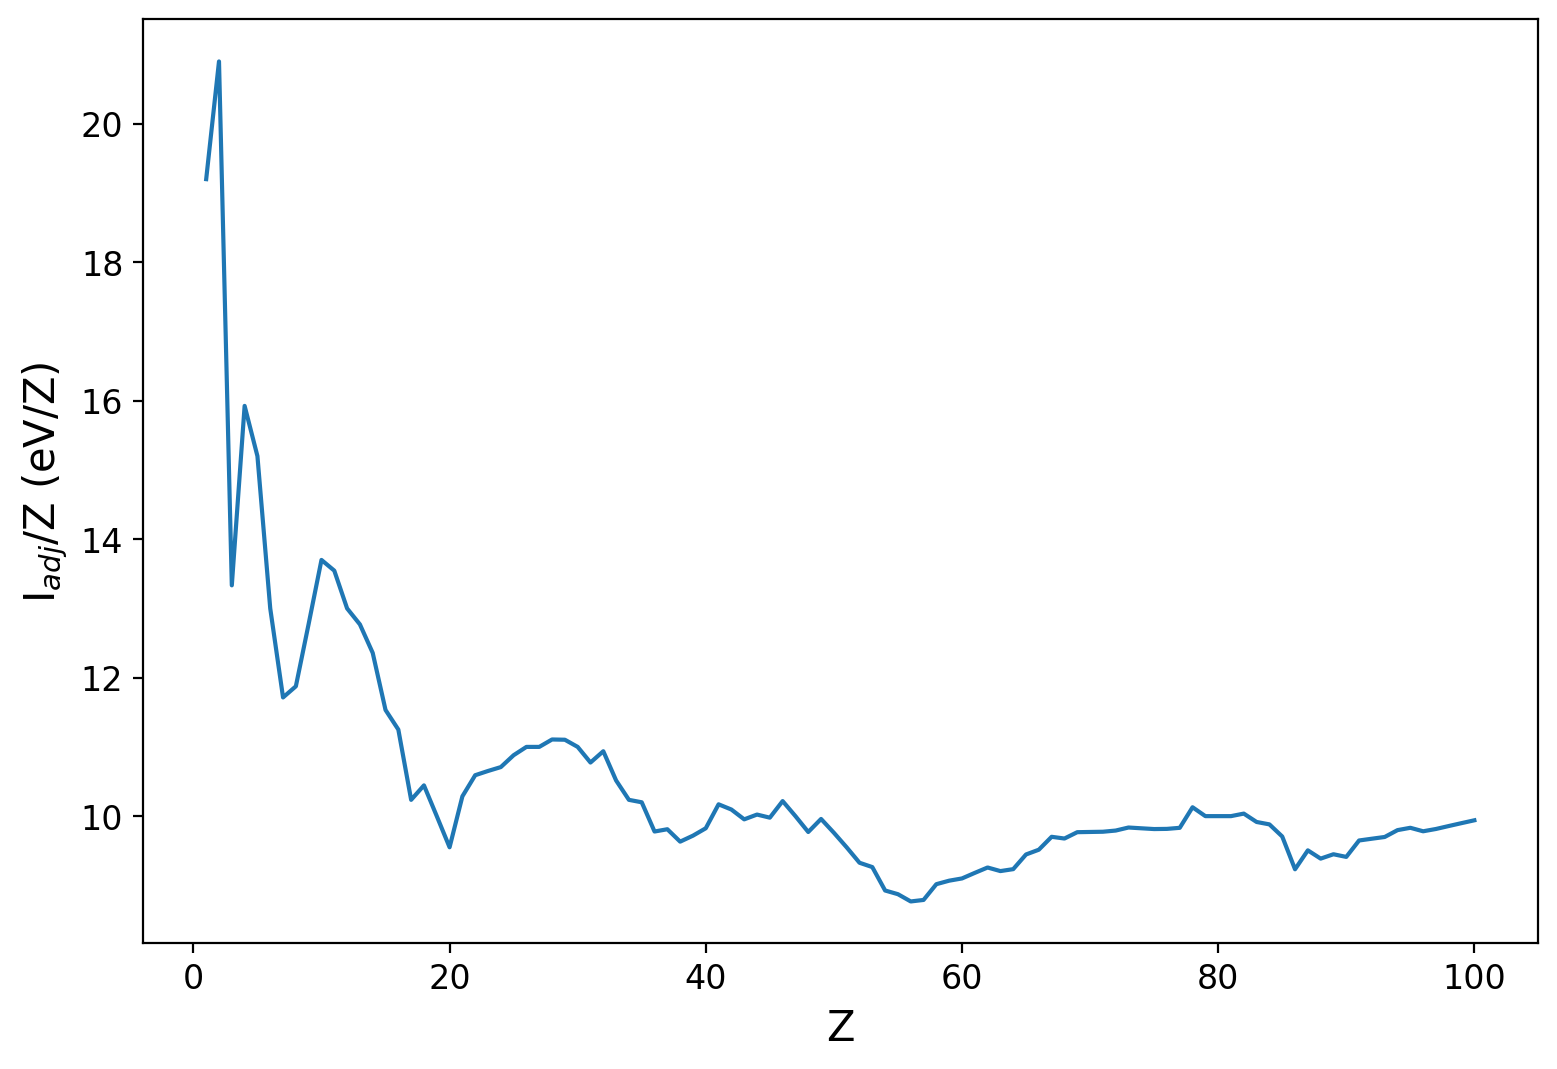

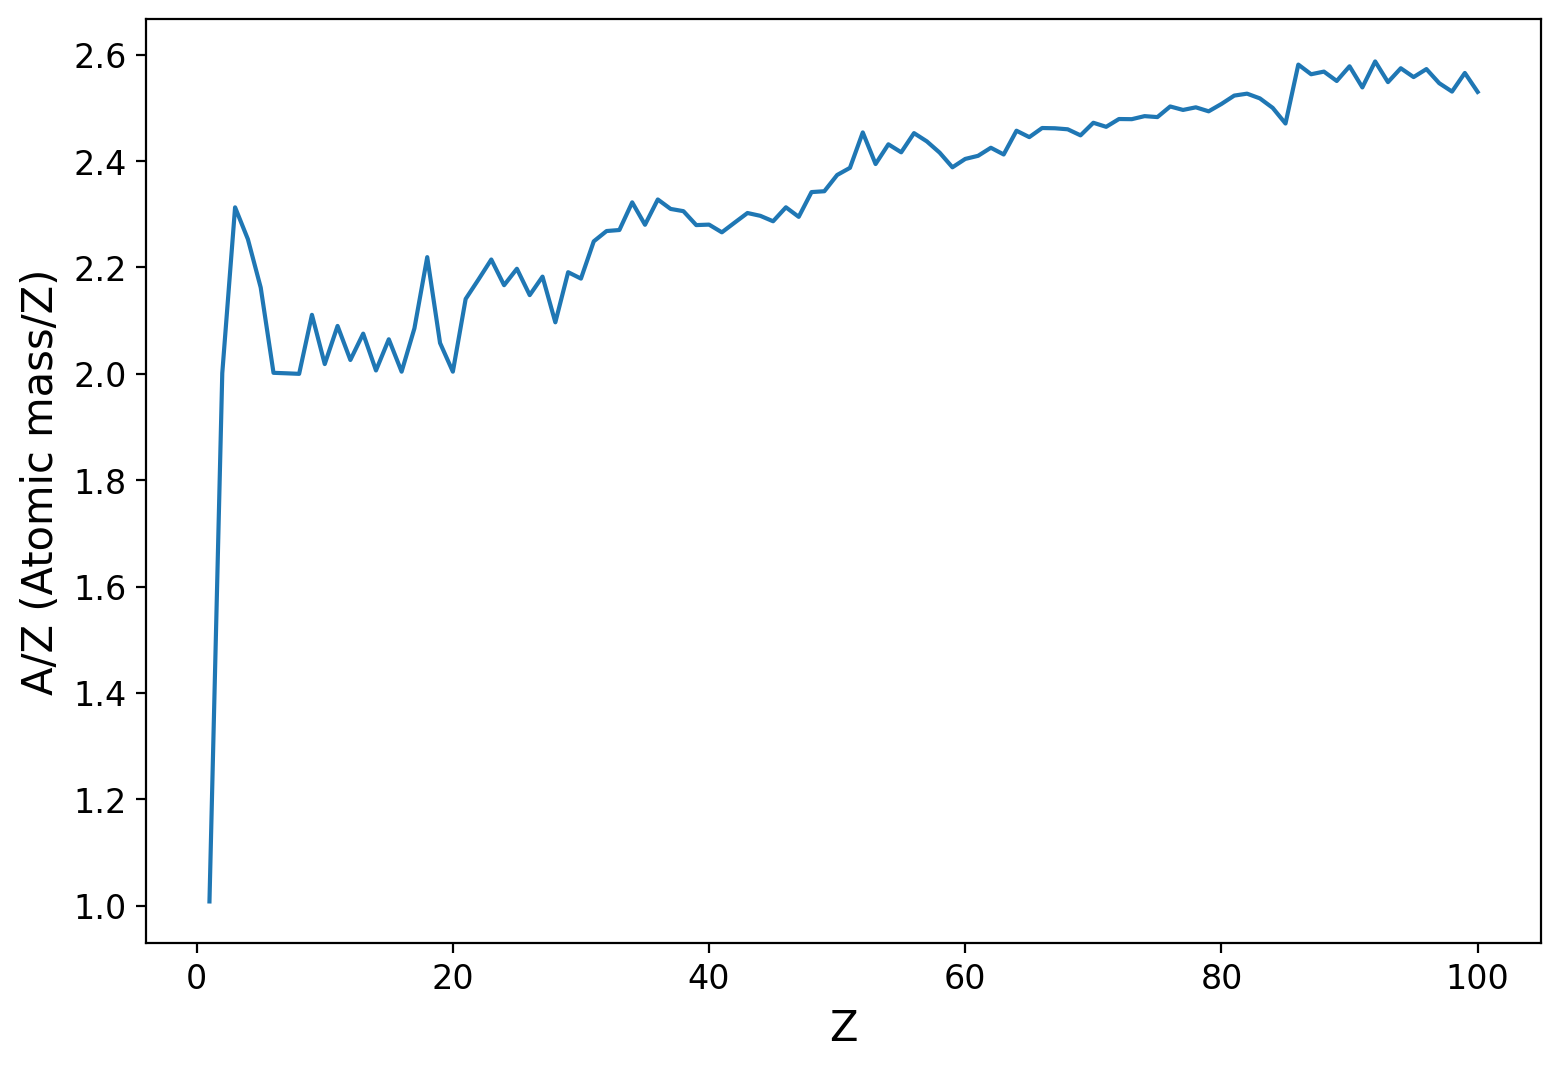

In [3]:
#values
def I(iZ,iPlot=False):
    #https://github.com/nrc-cnrc/EGSnrc/blob/master/HEN_HOUSE/pegs4/pegs4.mortran#L1354-L1391
    lI=[19.2,41.8,40.,63.7,76.0,78.0,82.0,95.0,115.,137.,
     149.,156.,166.,173.,173.,180.,174.,188.,190.,191.,216.,233.,245.,
     257.,272.,286.,297.,311.,322.,330.,334.,350.,347.,348.,357.,352.,
     363.,366.,379.,393.,417.,424.,428.,441.,449.,470.,470.,469.,488.,
     488.,487.,485.,491.,482.,488.,491.,501.,523.,535.,546.,560.,574.,
     580.,591.,614.,628.,650.,658.,674.,684.,694.,705.,718.,727.,736.,
     746.,757.,790.,790.,800.,810.,823.,823.,830.,825.,794.,827.,826.,
     841.,847.,878.,890.,902.,921.,934.,939.,952.,966.,980.,994.]
    lZ=np.arange(1,len(lI)+1)
    if iPlot:
        plt.plot(lZ,lI/lZ)
        plt.xlabel('Z')
        plt.ylabel('I$_{adj}$/Z (eV/Z)')
        plt.show()
    return lI[iZ]*1e-6 #MeV not eV
def A(iZ,iPlot=False):
    #https://github.com/nrc-cnrc/EGSnrc/blob/master/HEN_HOUSE/pegs4/pegs4.mortran#L1354-L1391
    lA=[1.00797,4.0026,6.939,9.0122,10.811,12.01115,14.0067,
     15.9994,18.9984,20.183,22.9898,24.312,26.9815,28.088,30.9738,
     32.064,35.453,39.948,39.102,40.08,44.956,47.90,50.942,51.998,
     54.9380,55.847,58.9332,58.71,63.54,65.37,69.72,72.59,74.9216,
     78.96,79.808,83.80,85.47,87.62,88.905,91.22,92.906,95.94,99.0,
     101.07,102.905,106.4,107.87,112.4,114.82,118.69,121.75,127.60,
     126.9044,131.30,132.905,137.34,138.91,
     140.12,140.907,144.24,147.,150.35,151.98,157.25,158.924,162.50,
     164.930,167.26,168.934,173.04,174.97,178.49,180.948,183.85,
     186.2,190.2,192.2,195.08,196.987,200.59,204.37,207.19,208.980,
     210.,210.,222.,223.,226.,227.,232.036,231.,238.03,237.,242.,
     243.,247.,247.,248.,254.,253.
    ]
    lZ=np.arange(1,len(lA)+1)
    if iPlot:
        plt.plot(lZ,lA/lZ)
        plt.xlabel('Z')
        plt.ylabel('A/Z (Atomic mass/Z)')
        plt.show()
    return lA[iZ-1]
lItmp=I(1,True)
lItmp=A(1,True)

<a name='exercises_21_4'></a>     

| [Top](#section_21_0) | [Restart Section](#section_21_4) | [Next Section](#section_21_5) |


6.36964816414323


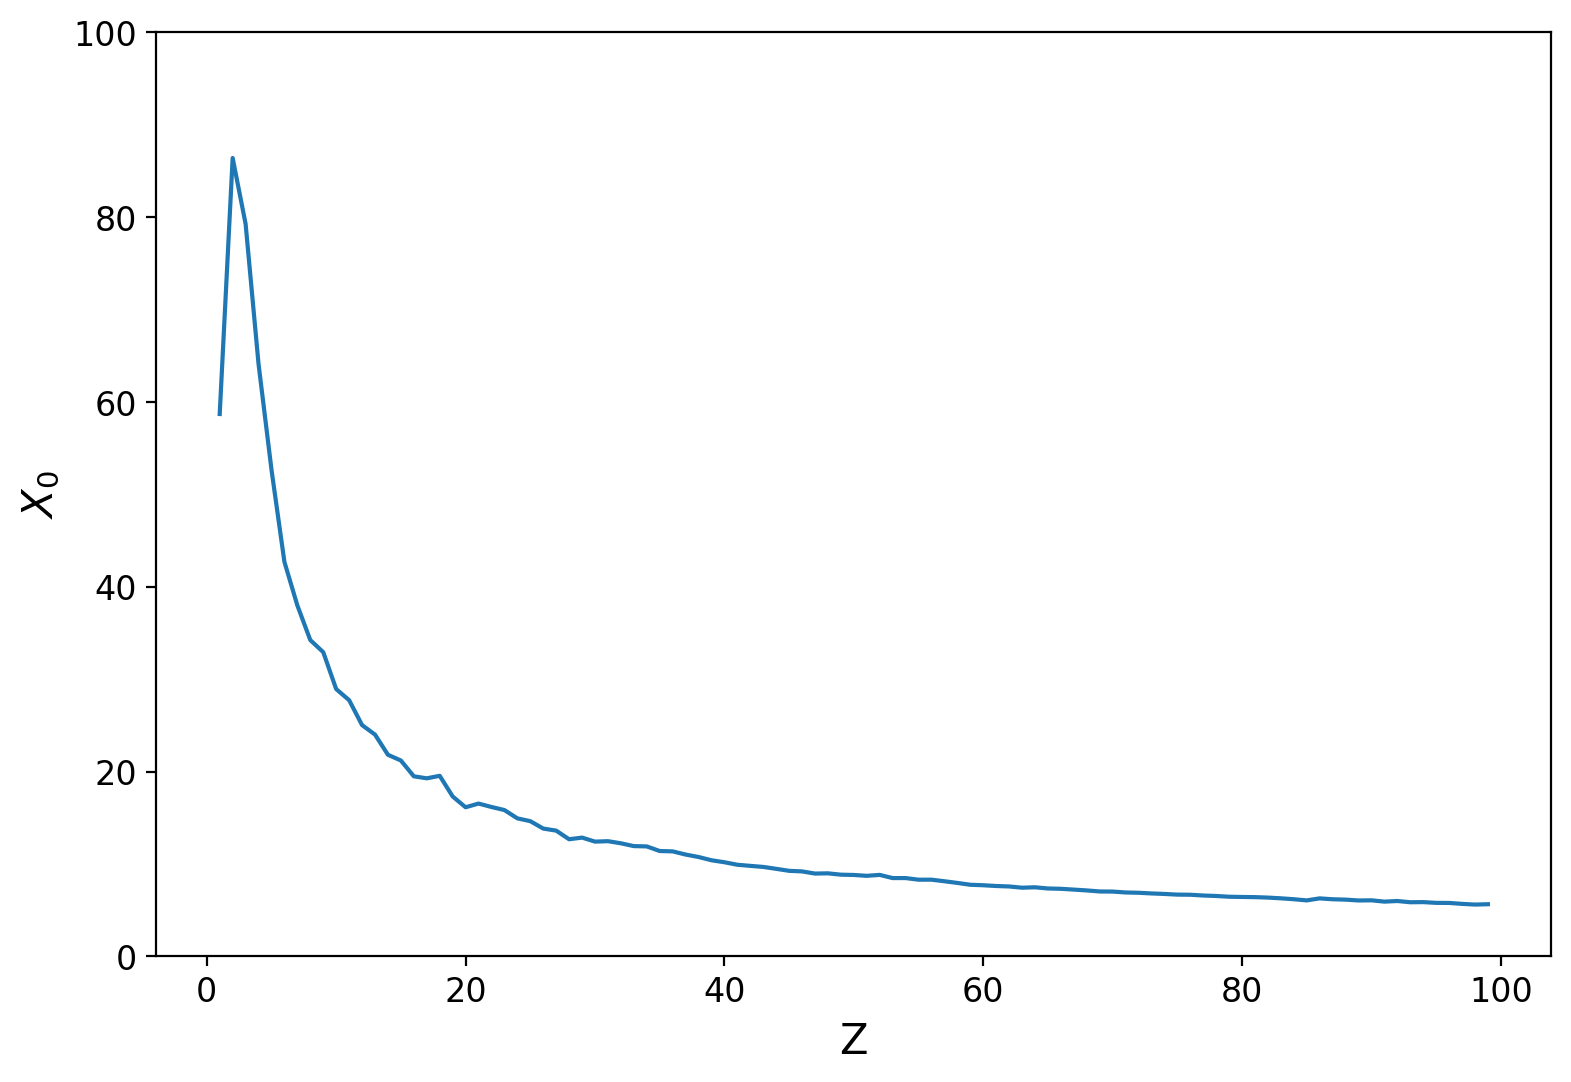

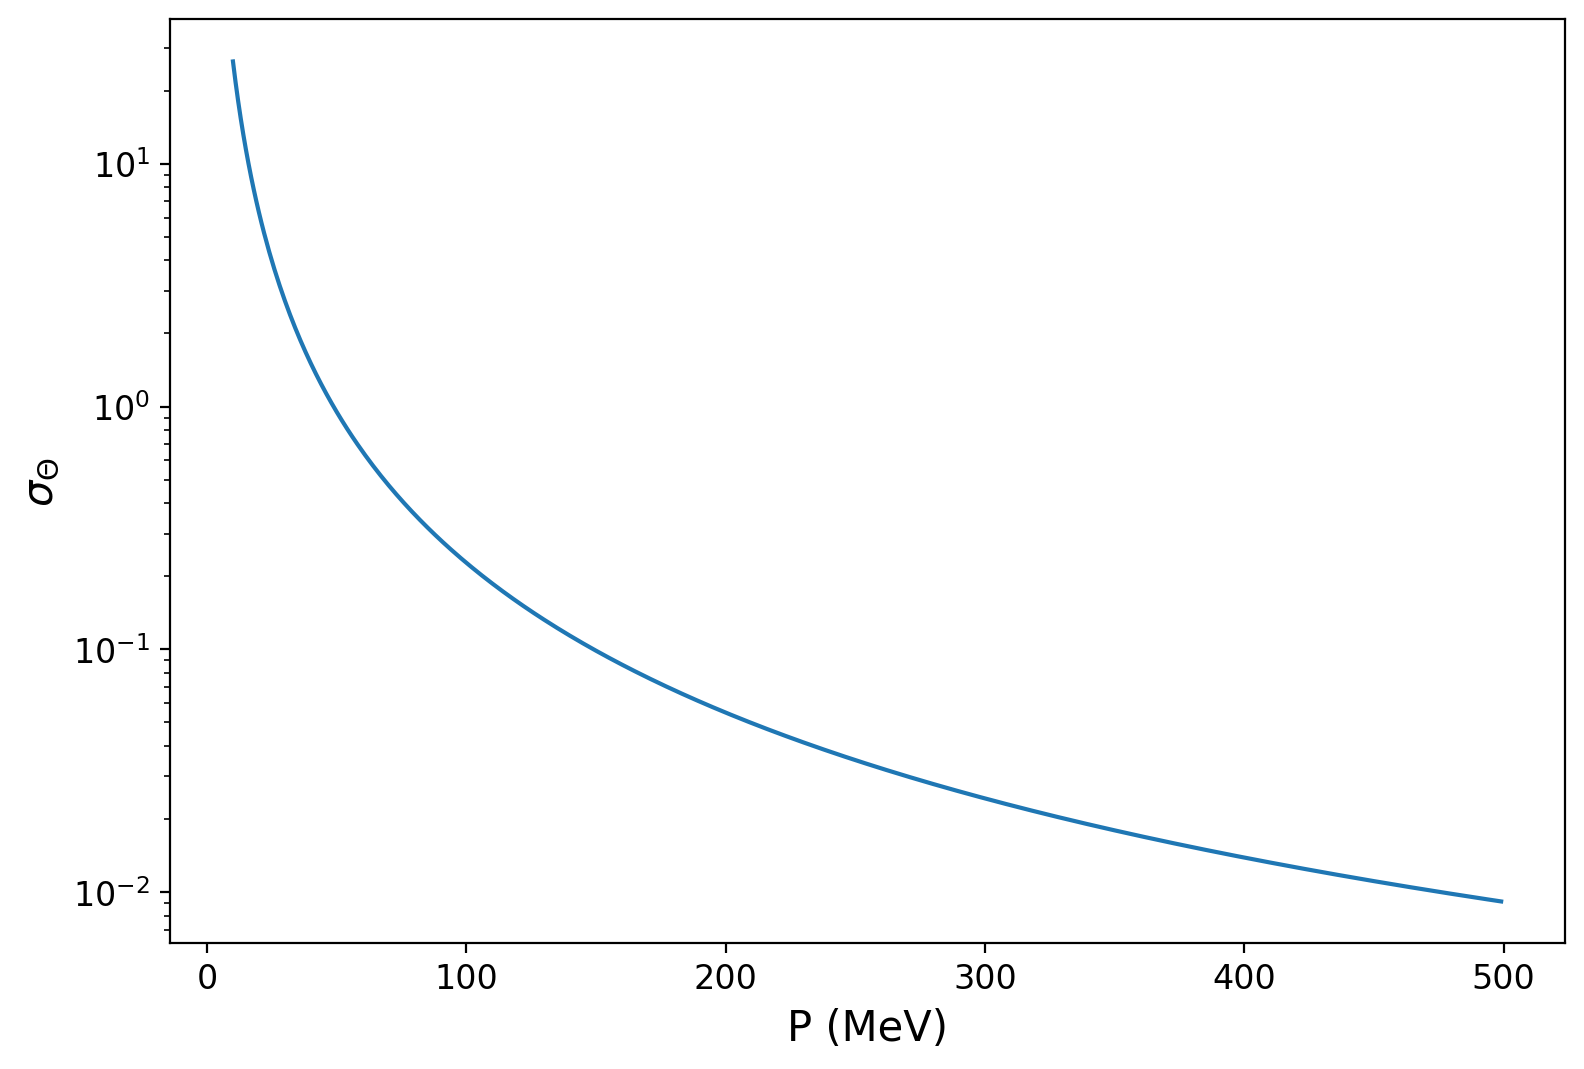

In [8]:
def X0(iZ):
    const=(716.408**-1)/A(iZ)
    a = iZ/137.
    Lrad =np.log(184.15*iZ**(-1./3.))
    Lradp=np.log(1194*iZ**(-2./3.))
    fZ = a**2*((1+a**2)**(-1)+0.20206-0.0369*a**2+0.0083*a**4-0.002*a**6)
    val=const*(iZ**2*(Lrad-fZ)+iZ*Lradp)
    return 1./val

def sigmaTheta(ip,im,iX0,idx=1.0,zpart=1):
    C=13.6
    X0=iX0
    dx=idx/iX0
    const=C/(beta(ip,im)*ip)*zpart*np.sqrt(dx)
    logterm=1+0.038*np.log(dx*zpart**2/beta(ip,im)**2)
    return const*logterm

def thetaScatter(ip,im,iX0,idx,zpart=1):
    z1=np.random.normal(0,1,ip.shape[0])
    z2=np.random.normal(0,1,ip.shape[0])
    stheta=sigmaTheta(ip,im,iX0,zpart)
    dy    =z1*idx*stheta/np.sqrt(12.) + z2*idx*stheta/2
    dtheta=z2*stheta
    return dtheta,dy

lZ=np.arange(1,100,1)
lX0=np.zeros(len(lZ))
for pZ in lZ:
    lX0[pZ-1] = X0(pZ)
print(X0(82))
plt.plot(lZ,lX0)
plt.xlabel("Z")
plt.ylabel("$X_{0}$")
plt.ylim(0,100)
plt.show()

lP=np.arange(10,500,1)
lST = sigmaTheta(lP,mproton,X0(8))
plt.plot(lP,lST)
plt.yscale('log')
plt.xlabel('P (MeV)')
plt.ylabel('$\sigma_{\Theta}$')
plt.show()

What we see above is that for very low energy we have very large angles when we get to the low momenta. Basically, the proton can go anywhere, this can blur out our beam, and if we are using this for cancer therapy can cause more damage.

One important thing to consider is that we need to make sure our angular scatter is physical, that means we should make sure that our angles are ok.

Scanning: 150
Scanning: 200
Scanning: 250
Scanning: 300


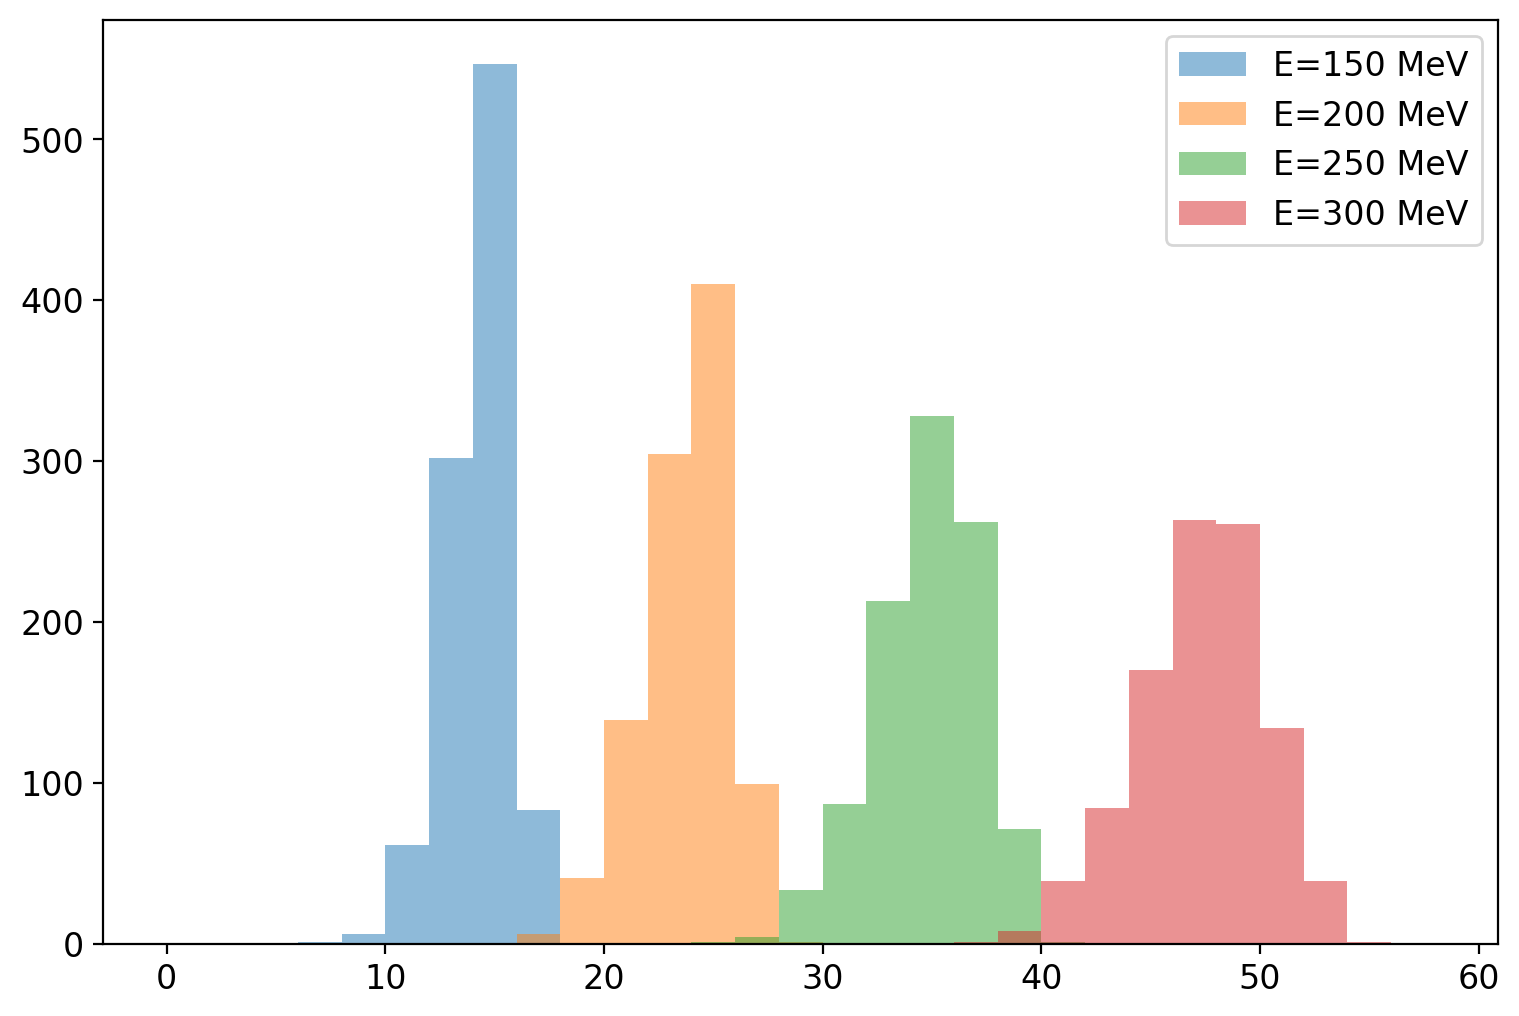

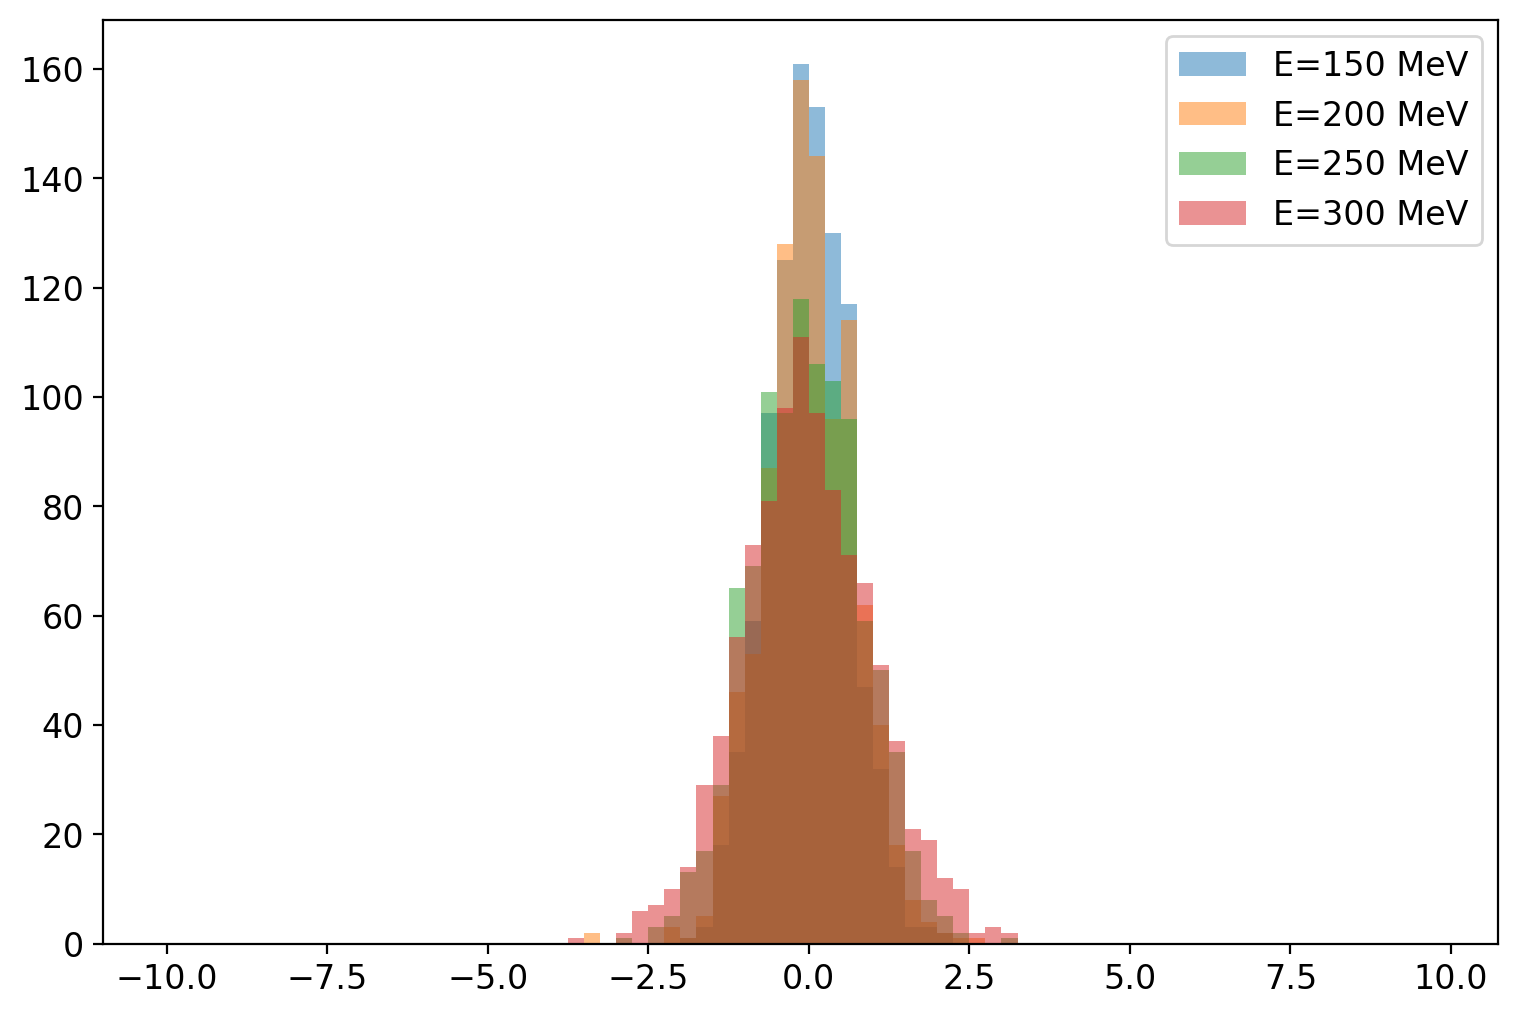

NameError: name 'sumEstep' is not defined

In [9]:
def simNYParallelSample(iN, ie=500,im=935,idt=1e-10,iZ=8):
    xstep  = np.empty((0,iN))
    ystep  = np.empty((0,iN))
    estep  = np.empty((0,iN))
    pstep  = np.empty((0,iN))
    theta=0
    y=0
    c=3e10
    dist=np.zeros(iN)
    e=np.ones(iN)*ie
    lX0 = X0(iZ)
    print("Scanning:",ie)
    while np.any(e > 5):
        p = eToP(e,im)
        lMPV,lWMPV  = landauMPV(p,im,iZ=iZ,irho=1.06)
        dE = np.zeros(lMPV.shape)
        ##Here we have to parallelize by hand, this is not good
        for i0, (pMPV,pWMPV) in enumerate(zip(lMPV,lWMPV)):
            dE[i0]     = landau.sample(pMPV, pWMPV,1)
        dx     = beta(p,im)*c*idt#speed of light
        dTheta,dy = thetaScatter(p,im,lX0,idx=dx,zpart=1)
        pdEdX  = np.minimum(dE*dx,e-0.1)
        e      -= pdEdX
        dist   += dx*np.cos(theta)
        y      += dy + np.sin(theta)*dx
        theta  += dTheta
        xstep  = np.vstack((xstep,dist))
        ystep  = np.vstack((ystep,y))
        estep  = np.vstack((estep,pdEdX))
        pstep  = np.vstack((pstep,e))
    xstep = xstep.T
    estep = estep.T
    pstep = pstep.T
    ystep = ystep.T
    return xstep,pstep,estep,ystep

xstep150,pstep150,estep150,ystep150=simNYParallelSample(ie=150,im=mproton,iN=1000,idt=1e-10,iZ=8)
xstep200,pstep200,estep200,ystep200=simNYParallelSample(ie=200,im=mproton,iN=1000,idt=1e-10,iZ=8)
xstep250,pstep250,estep250,ystep250=simNYParallelSample(ie=250,im=mproton,iN=1000,idt=1e-10,iZ=8)
xstep300,pstep300,estep300,ystep300=simNYParallelSample(ie=300,im=mproton,iN=1000,idt=1e-10,iZ=8)

xrange=np.arange(0,60,2)
plt.hist(xstep150[:,-1],bins=xrange,alpha=0.5,label='E=150 MeV')
plt.hist(xstep200[:,-1],bins=xrange,alpha=0.5,label='E=200 MeV')
plt.hist(xstep250[:,-1],bins=xrange,alpha=0.5,label='E=250 MeV')
plt.hist(xstep300[:,-1],bins=xrange,alpha=0.5,label='E=300 MeV')
plt.legend()
plt.show()

xrange=np.arange(-10,10,0.25)
plt.hist(ystep150[:,-1],bins=xrange,alpha=0.5,label='E=150 MeV')
plt.hist(ystep200[:,-1],bins=xrange,alpha=0.5,label='E=200 MeV')
plt.hist(ystep250[:,-1],bins=xrange,alpha=0.5,label='E=250 MeV')
plt.hist(ystep300[:,-1],bins=xrange,alpha=0.5,label='E=300 MeV')
plt.legend()
plt.show()

ef150,eb150=sumEstep(estep150,xstep150)
ef200,eb200=sumEstep(estep200,xstep200)
ef250,eb250=sumEstep(estep250,xstep250)
ef300,eb300=sumEstep(estep300,xstep300)

xrange=np.arange(0,15,0.5)
plt.hist(ef150,bins=xrange,alpha=0.5,label='E=150 MeV (dE/dx Front)')
plt.hist(ef200,bins=xrange,alpha=0.5,label='E=200 MeV (dE/dx Front)')
plt.hist(ef250,bins=xrange,alpha=0.5,label='E=250 MeV (dE/dx Front)')
plt.hist(ef300,bins=xrange,alpha=0.5,label='E=300 MeV (dE/dx Front)')
plt.legend()
plt.show()

xrange=np.arange(0,60,2)
plt.hist(eb150,bins=xrange,alpha=0.5,label='E=150 MeV (dE/dx Back)')
plt.hist(eb200,bins=xrange,alpha=0.5,label='E=200 MeV (dE/dx Back)')
plt.hist(eb250,bins=xrange,alpha=0.5,label='E=250 MeV (dE/dx Back)')
plt.hist(eb300,bins=xrange,alpha=0.5,label='E=300 MeV (dE/dx Back)')
plt.legend()
plt.show()


## Constructing a likelihood

<a name='exercises_22_2'></a>     

| [Top](#section_22_0) | [Restart Section](#section_22_2) | [Next Section](#section_22_3) |


<a name='section_20_3'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.3 Generating Full Bragg Scattering Details </h2>  

| [Top](#section_20_0) | [Previous Section](#section_20_2) | [Exercises](#exercises_20_3) | [Next Section](#section_20_4) |

Given the success of above, lets look at our events and see if we can try to generate a fully detailed event. Recall that we actually save the energy loss, x and y positions of each proton event. We can translate this to directly to an image by considering the Z-axis as the energy deposited. Lets go ahead and try to translate this to an image, and see what it looks like.

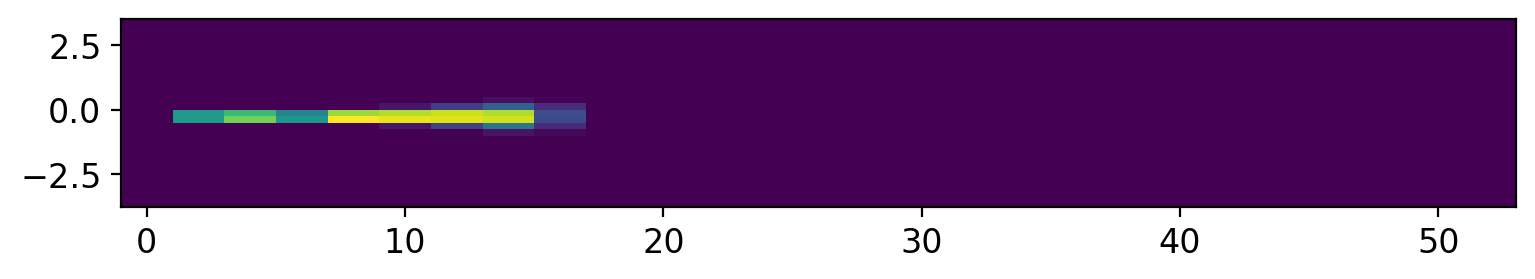

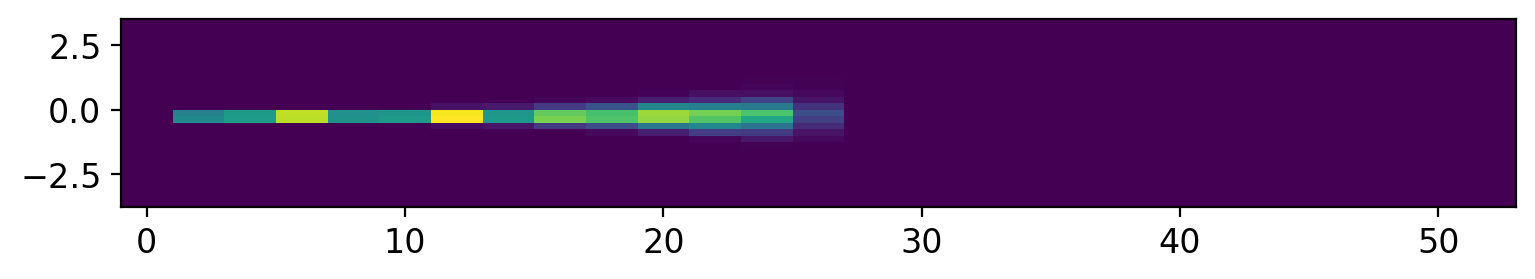

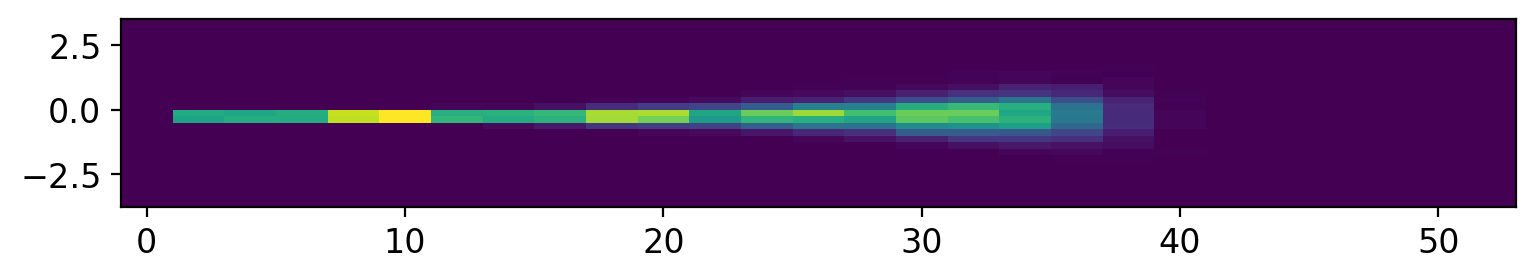

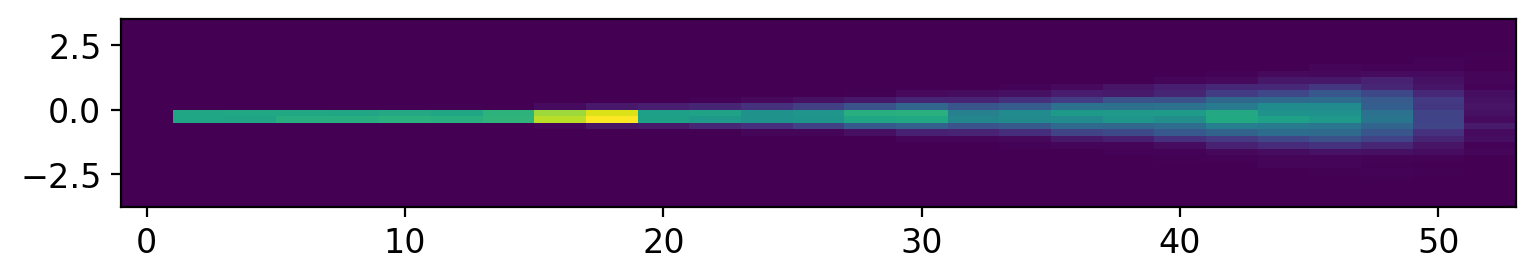

(1000, 1, 28, 28)
(1000, 1, 28, 28)
(1000, 1, 28, 28)
(1000, 1, 28, 28)


In [15]:
from torch.utils.data import Dataset, DataLoader
class DataSet(Dataset):
    def __init__(self, samples, labels):
        self.labels  = labels
        self.samples = samples
        if len(samples) != len(labels):
            raise ValueError(
                f"should have the same number of samples({len(samples)}) as there are labels({len(labels)})")

    def __len__(self):
        return len(self.labels)

    def nfeatures(self):
        return self.samples.shape[1]

    def __getitem__(self, index):
        y = self.labels[index]
        x = self.samples[index]
        return x, y
    
def plotImage(iId,ixstep,iestep,iystep):
    #plt.plot(ixstep[iId],iystep[iId])#,iestep[iId])
    #plt.show()
    #Now lets make a regular image
    xbin = np.arange(-1,55, 2)
    ybin = np.arange(-3.75, 3.75, 0.25)
    #xbin = np.arange(-0.5,60.5, 1)
    #ybin = np.arange(-5.125, 5.125, 0.25)
    H, xedges, yedges = np.histogram2d(ixstep.flatten(), iystep.flatten(), bins=(xbin, ybin),weights=iestep.flatten())
    plt.imshow(H.T,extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
    plt.show()
    #X, Y = np.meshgrid(xedges, yedges)
    #plt.pcolormesh(X,Y,H.T)
    #plt.show()

plotImage(-1,xstep150,estep150,ystep150)
plotImage(-1,xstep200,estep200,ystep200)
plotImage(-1,xstep250,estep250,ystep250)
plotImage(-1,xstep300,estep300,ystep300)


def makeImageDataSet(iE,ixstep,iestep,iystep):
    dataset=np.empty((0,1,28,28))
    for pX,pE,pY in zip(ixstep,iestep,iystep):
        xbin = np.arange(-1,57, 2)
        ybin = np.arange(-3.625, 3.625, 0.25)
        H, xedges, yedges = np.histogram2d(pX.flatten(), pY.flatten(), bins=(xbin, ybin),weights=pE.flatten())
        #H, xedges, yedges = np.histogram2d(ixstep.flatten(), iystep.flatten(), bins=(xbin, ybin),weights=iestep.flatten())
        #plt.imshow(H.T,extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
        #plt.show()
        H = np.reshape(H.T,(1,1,28,28))
        dataset = np.vstack((dataset,H))
    print(dataset.shape)
    Tdataset = torch.tensor(dataset).float()
    datasetout=DataSet(samples=Tdataset,labels=np.ones(dataset.shape[0])*iE)
    return datasetout,dataset

image150,dimage150=makeImageDataSet(1.50,xstep150,estep150,ystep150)
image200,dimage200=makeImageDataSet(2.00,xstep200,estep200,ystep200)
image250,dimage250=makeImageDataSet(2.50,xstep250,estep250,ystep250)
image300,dimage300=makeImageDataSet(3.00,xstep300,estep300,ystep300)

Now from this lets go ahead and make a VAE that describes our dataset. We can exploit the VAE architecture used above, just slightly tweaked.

In [16]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, stride=2, padding=1)
        self.batch2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 32, 3, stride=2, padding=0)
        self.linear1 = nn.Linear(3*3*32, 128)
        self.linear2 = nn.Linear(128, latent_dims)
        self.linear3 = nn.Linear(128, latent_dims)

        #Now we need sample in phase space
        self.N       = torch.distributions.Normal(0, 1)
        self.N.loc   = self.N.loc
        self.N.scale = self.N.scale
        self.kl = 0

        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )

        self.decoder_lin = nn.Sequential(
            nn.Linear(latent_dims, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True)
        )


    def encoder(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.batch2(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu =  self.linear2(x) #Mean in the gaussian space
        sigma = torch.exp(self.linear3(x)) #sigma in the space
        z = mu + sigma*self.N.sample(mu.shape) #smear
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum() #Now compute the KL divergence
        return z


    def decoder(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        return x


    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

torch.manual_seed(0)
d = 4
vae = VariationalAutoEncoder(latent_dims=d)
lr = 1e-2
optim = torch.optim.Adam(vae.parameters(), lr=lr, weight_decay=1e-5)
train_loader = torch.utils.data.DataLoader(image150, batch_size=500)

In [20]:
def plot_ae_outputs(idataset,ivae,n=10):
    plt.figure(figsize=(16,4.5))
    t_idx = np.random.randint(10,size=10)
    for i in range(n):
      ax = plt.subplot(2,n,i+1)
      img = idataset[t_idx[i]][0].unsqueeze(0)
      vae.eval()
      #encoder.eval()
      #decoder.eval()
      with torch.no_grad():
         rec_img  = vae.decoder(vae.encoder(img))
      plt.imshow(img.cpu().squeeze().numpy())#, cmap='gist_gray')
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)
      if i == n//2:
        ax.set_title('Original images')
      ax = plt.subplot(2, n, i + 1 + n)
      plt.imshow(rec_img.cpu().squeeze().numpy())#, cmap='gist_gray')
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)
      if i == n//2:
         ax.set_title('Reconstructed images')
    plt.show()
def train_epoch(mnvae, dataloader, optimizer):
    # Set train mode for both the encoder and the decoder
    mnvae.train()
    train_loss = 0.0
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for x, _ in dataloader:
        # Move tensor to the proper device
        x_hat = mnvae(x)
        # Evaluate loss
        loss = ((x - x_hat)**2).sum() + mnvae.kl
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        #print('\t partial train loss (single batch): %f' % (loss.item()))
        train_loss+=loss.item()

    return train_loss / len(dataloader.dataset)



 EPOCH 1/2500 	 train loss 4236.529 	 val loss 0.000


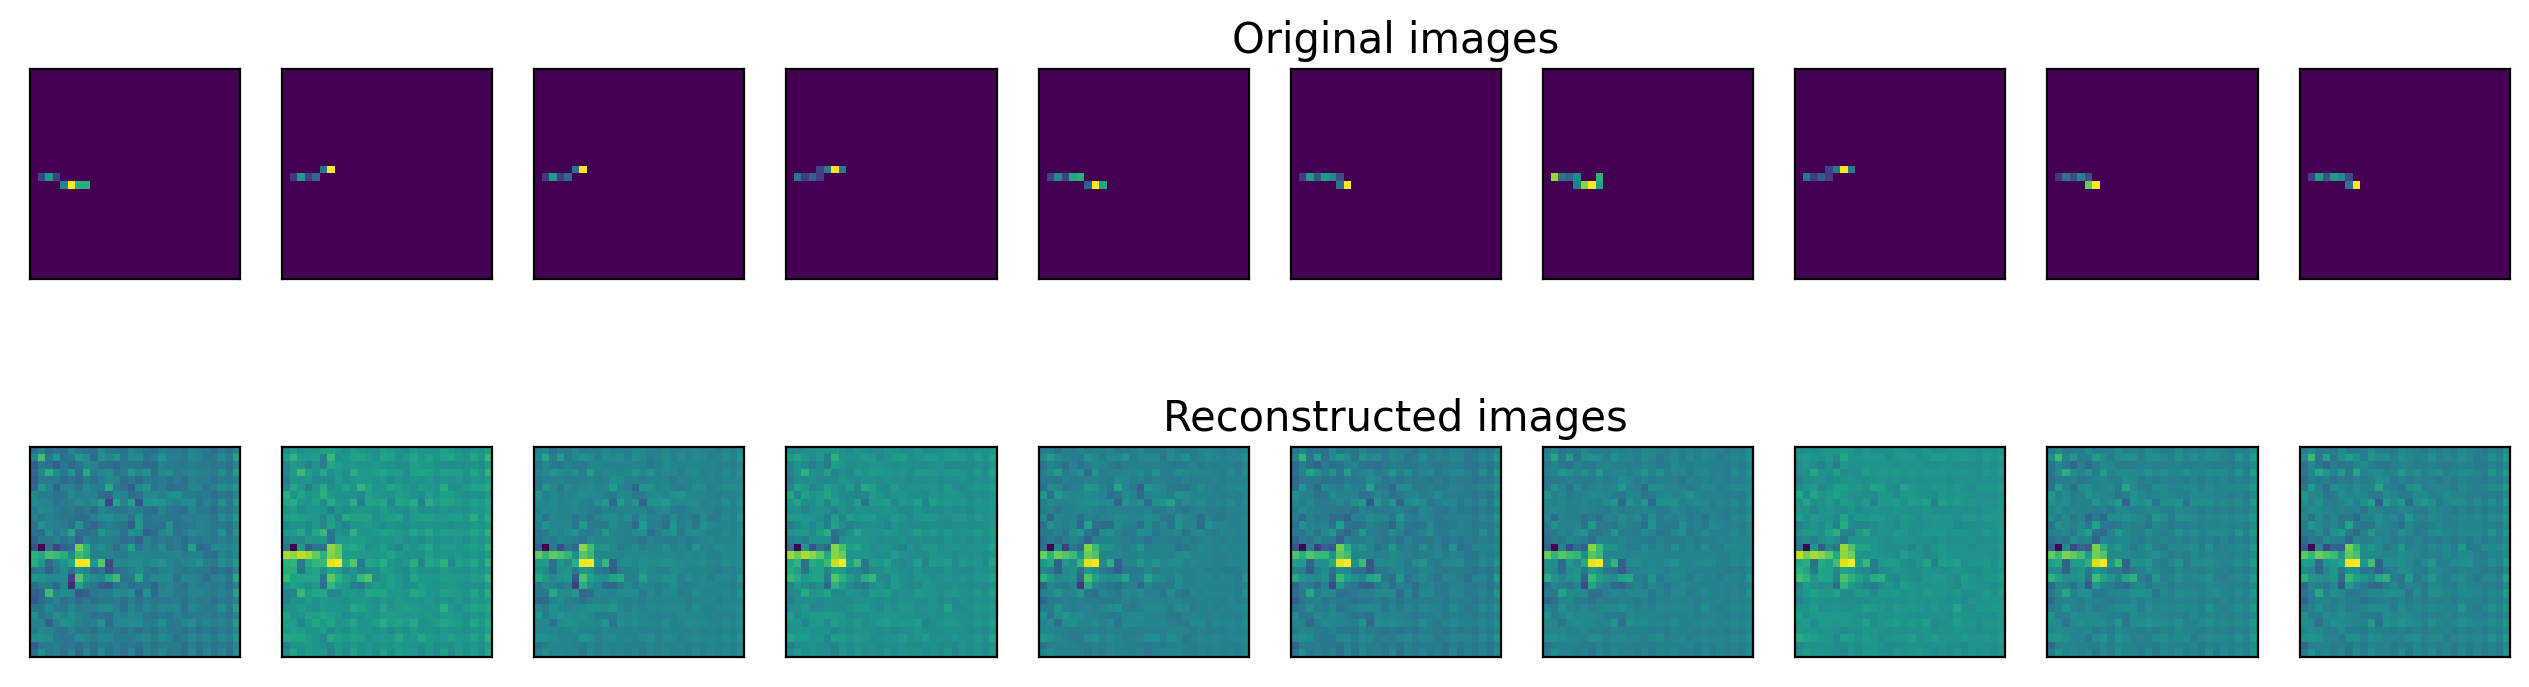


 EPOCH 501/2500 	 train loss 78.700 	 val loss 0.000


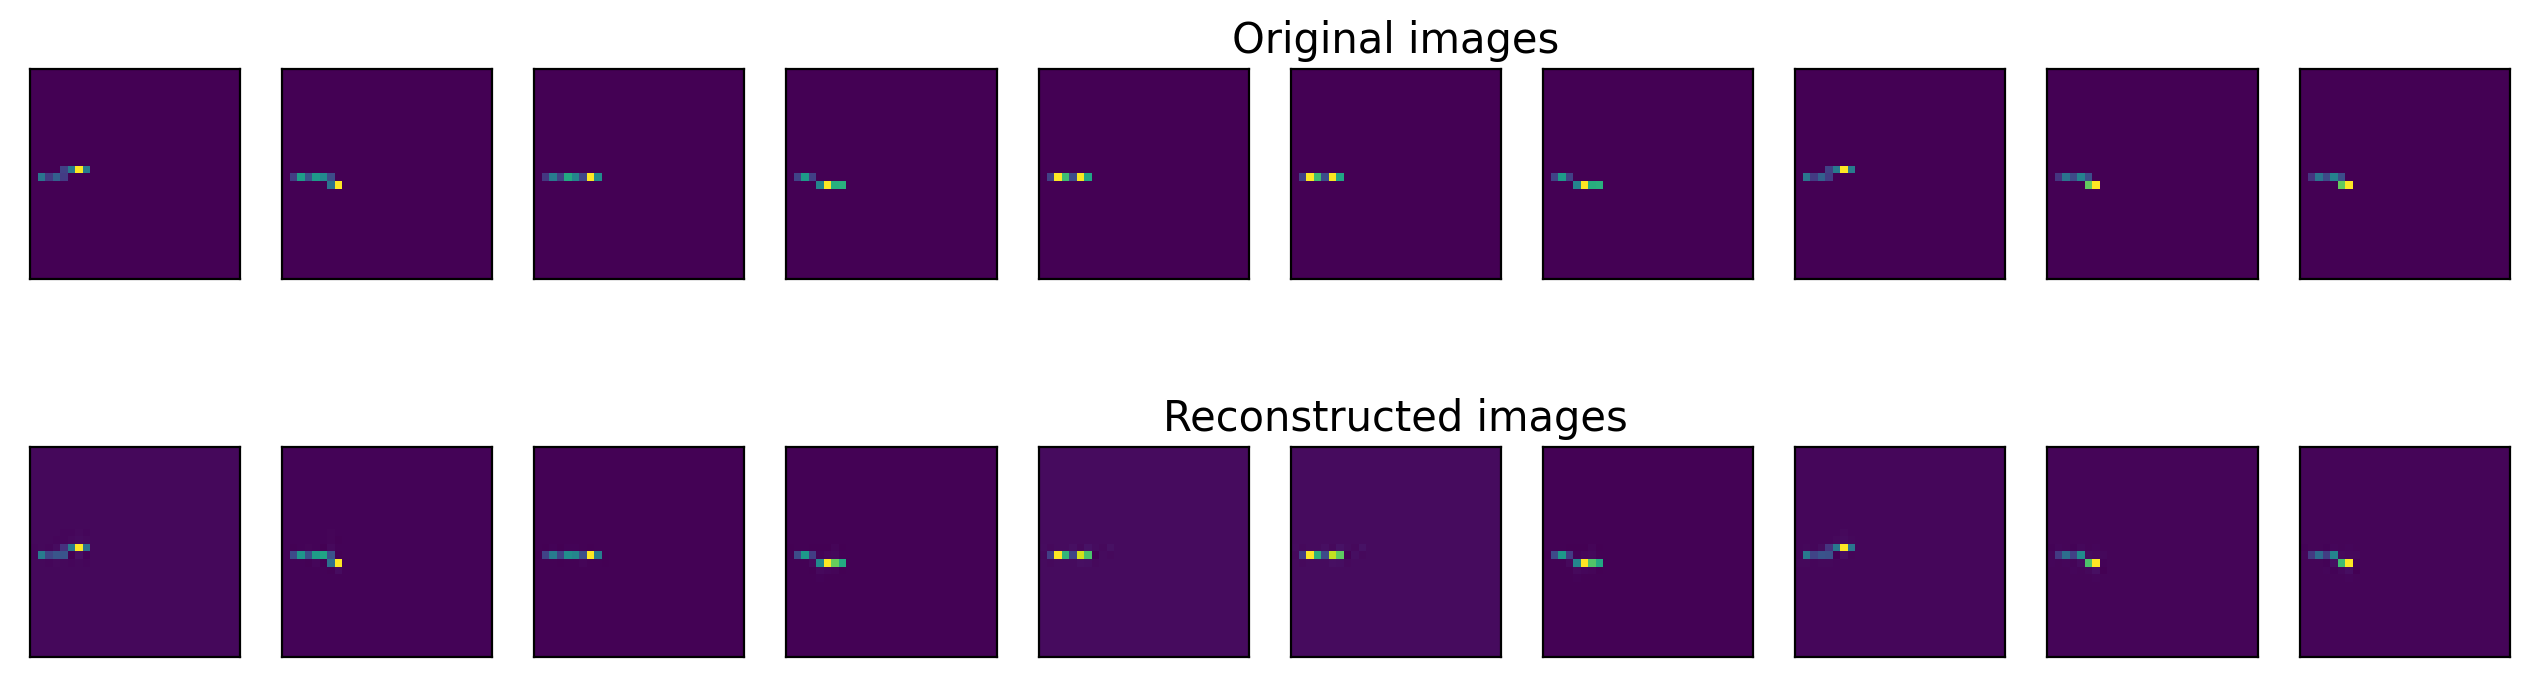


 EPOCH 1001/2500 	 train loss 52.382 	 val loss 0.000


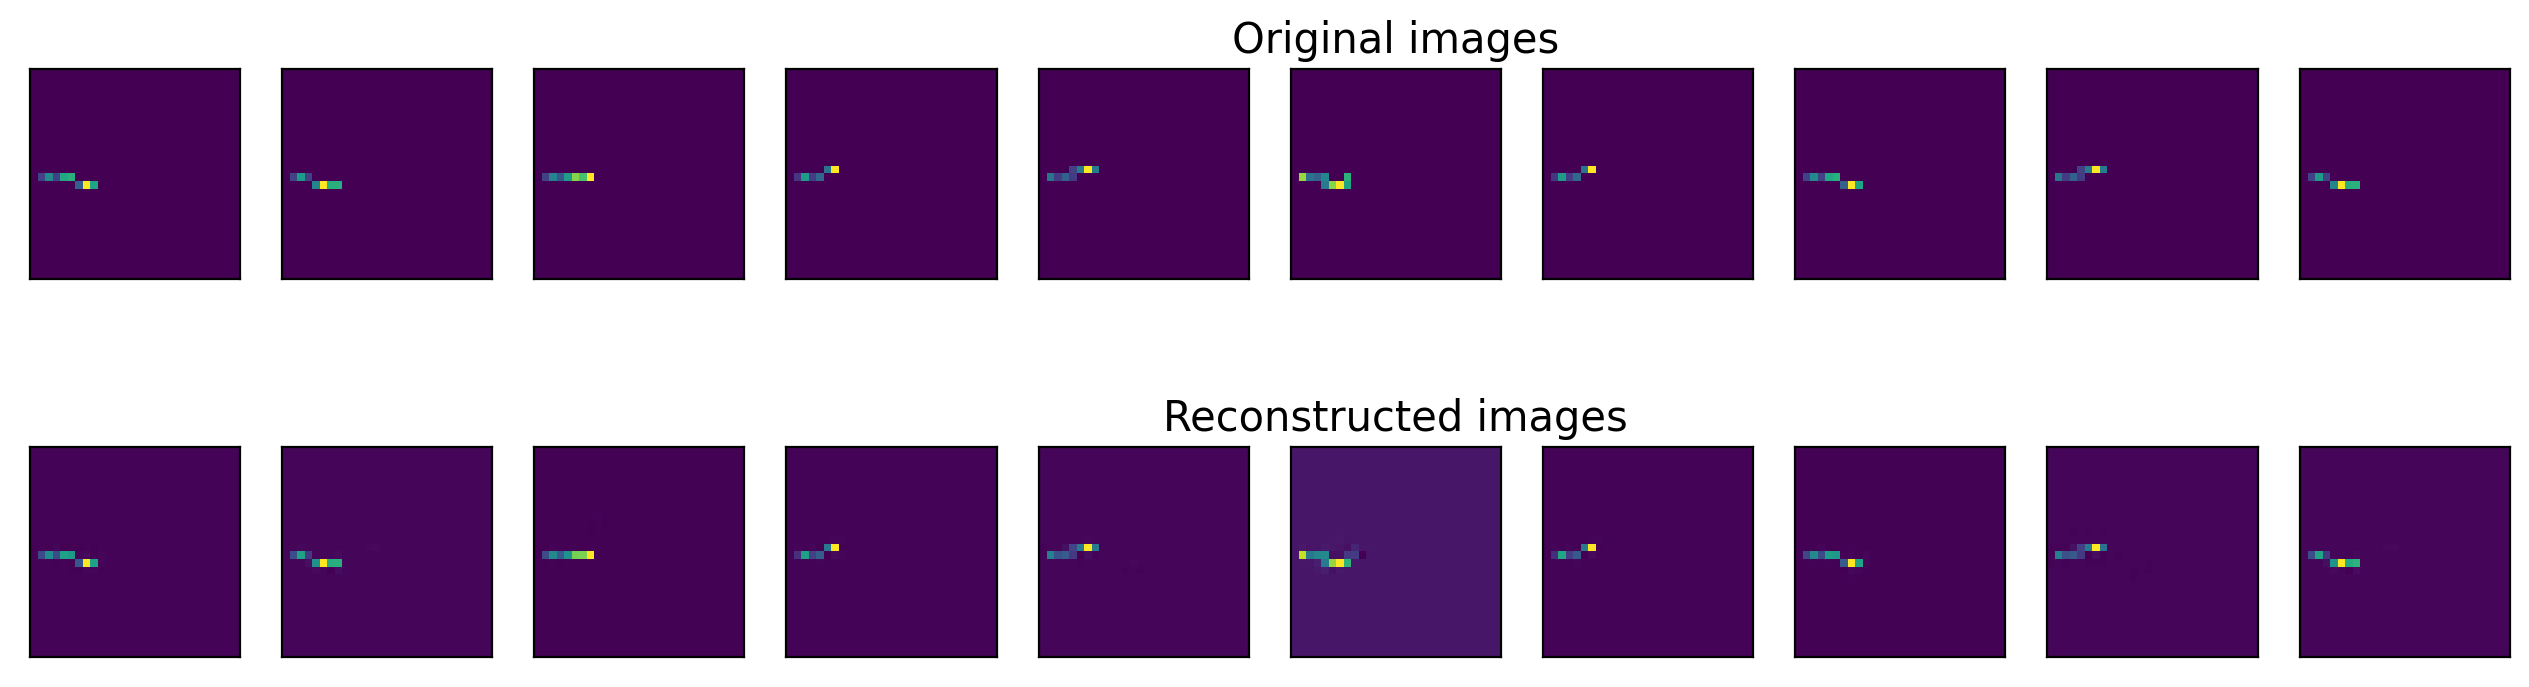


 EPOCH 1501/2500 	 train loss 46.526 	 val loss 0.000


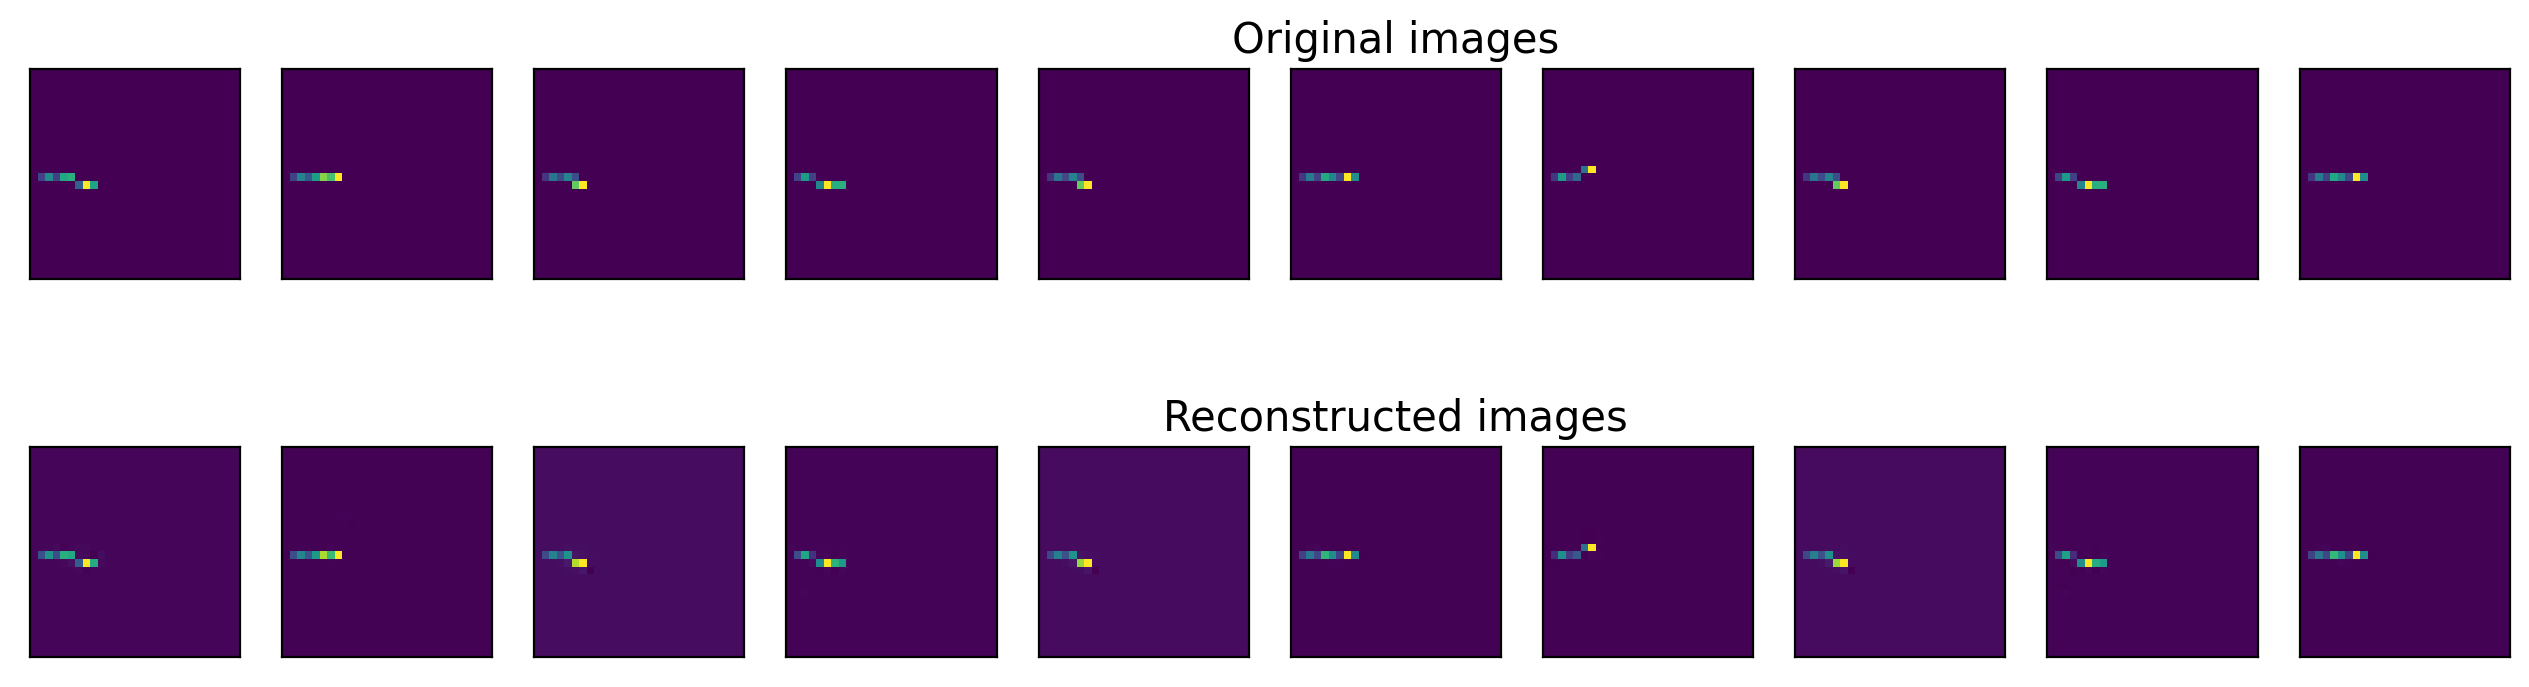


 EPOCH 2001/2500 	 train loss 45.687 	 val loss 0.000


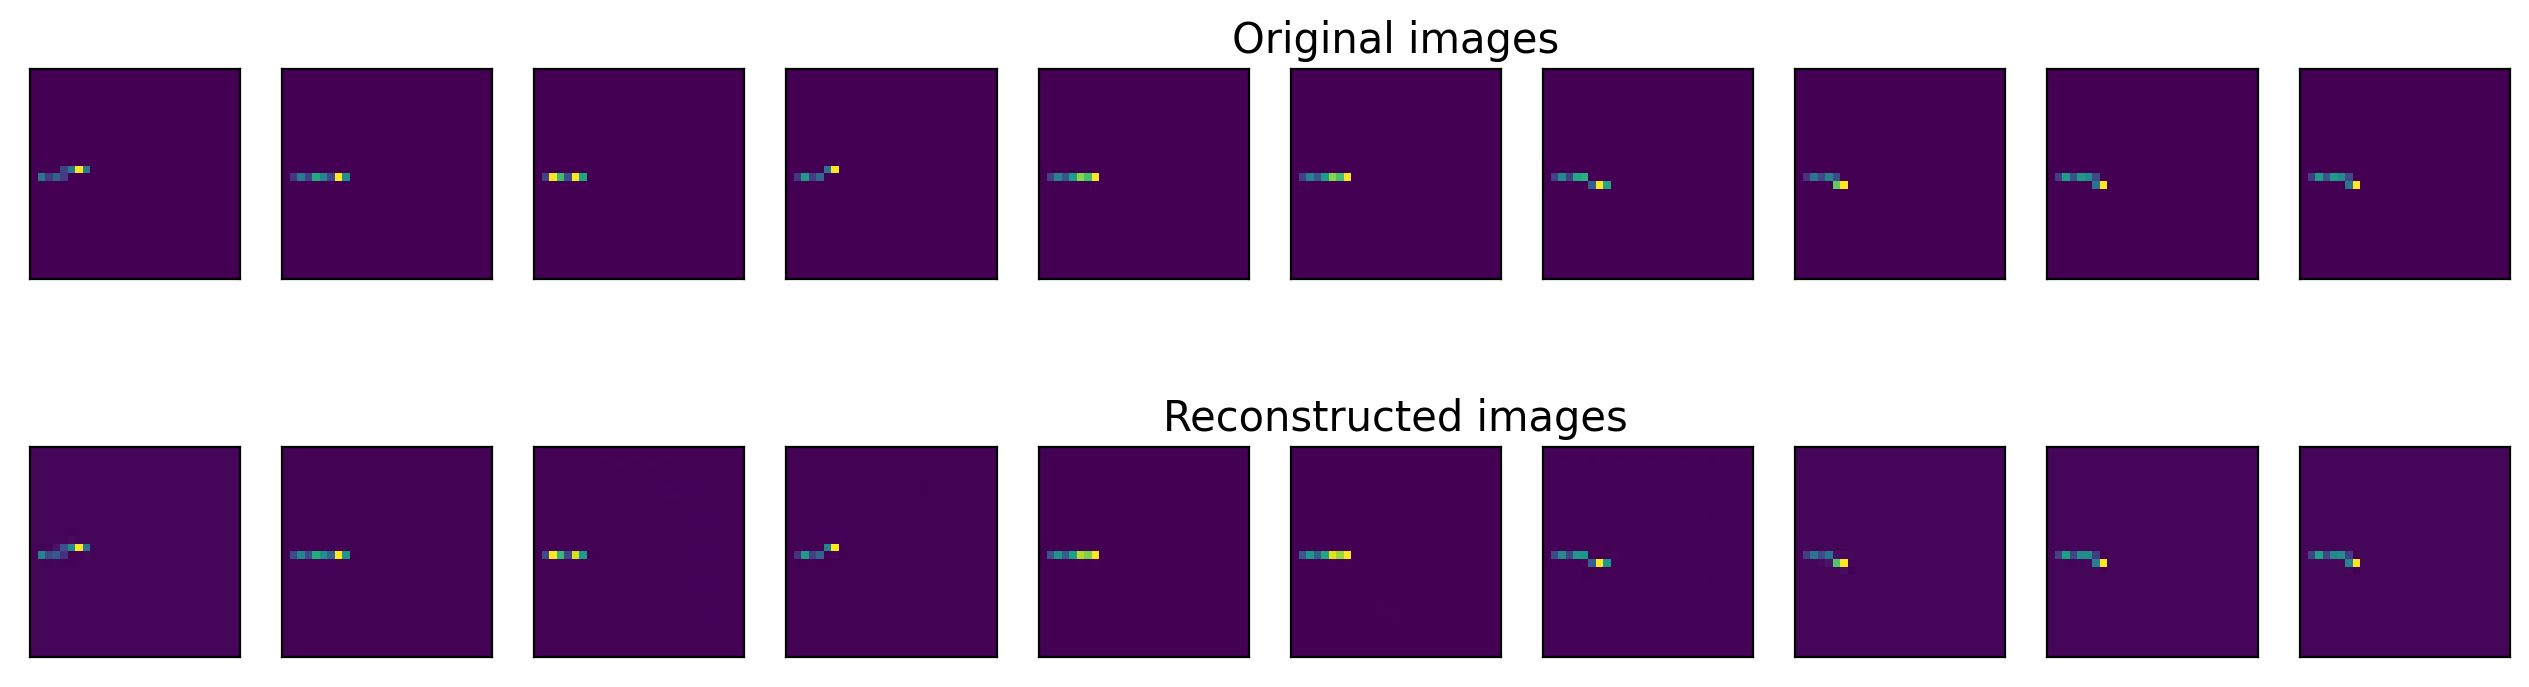

In [21]:
num_epochs = 2500

for epoch in range(num_epochs):
    train_loss = train_epoch(vae,train_loader,optim)
    val_loss=0
    if epoch % 500 == 0:
        print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(epoch + 1, num_epochs,train_loss,val_loss))
        plot_ae_outputs(image150,vae,n=10)

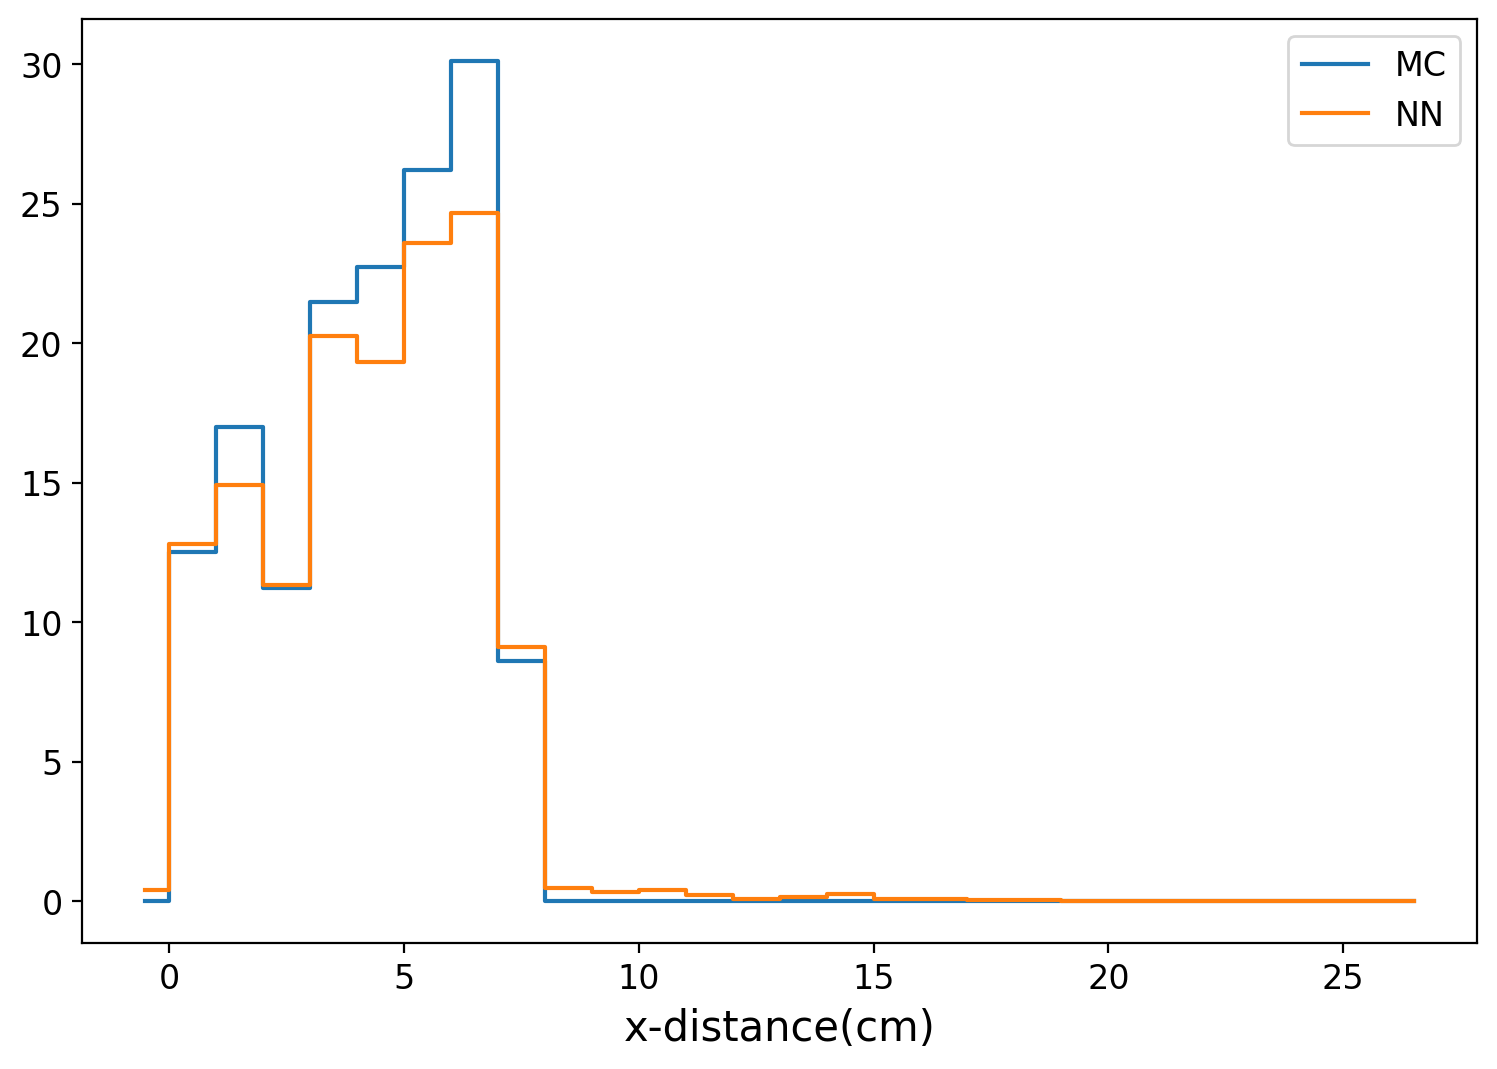

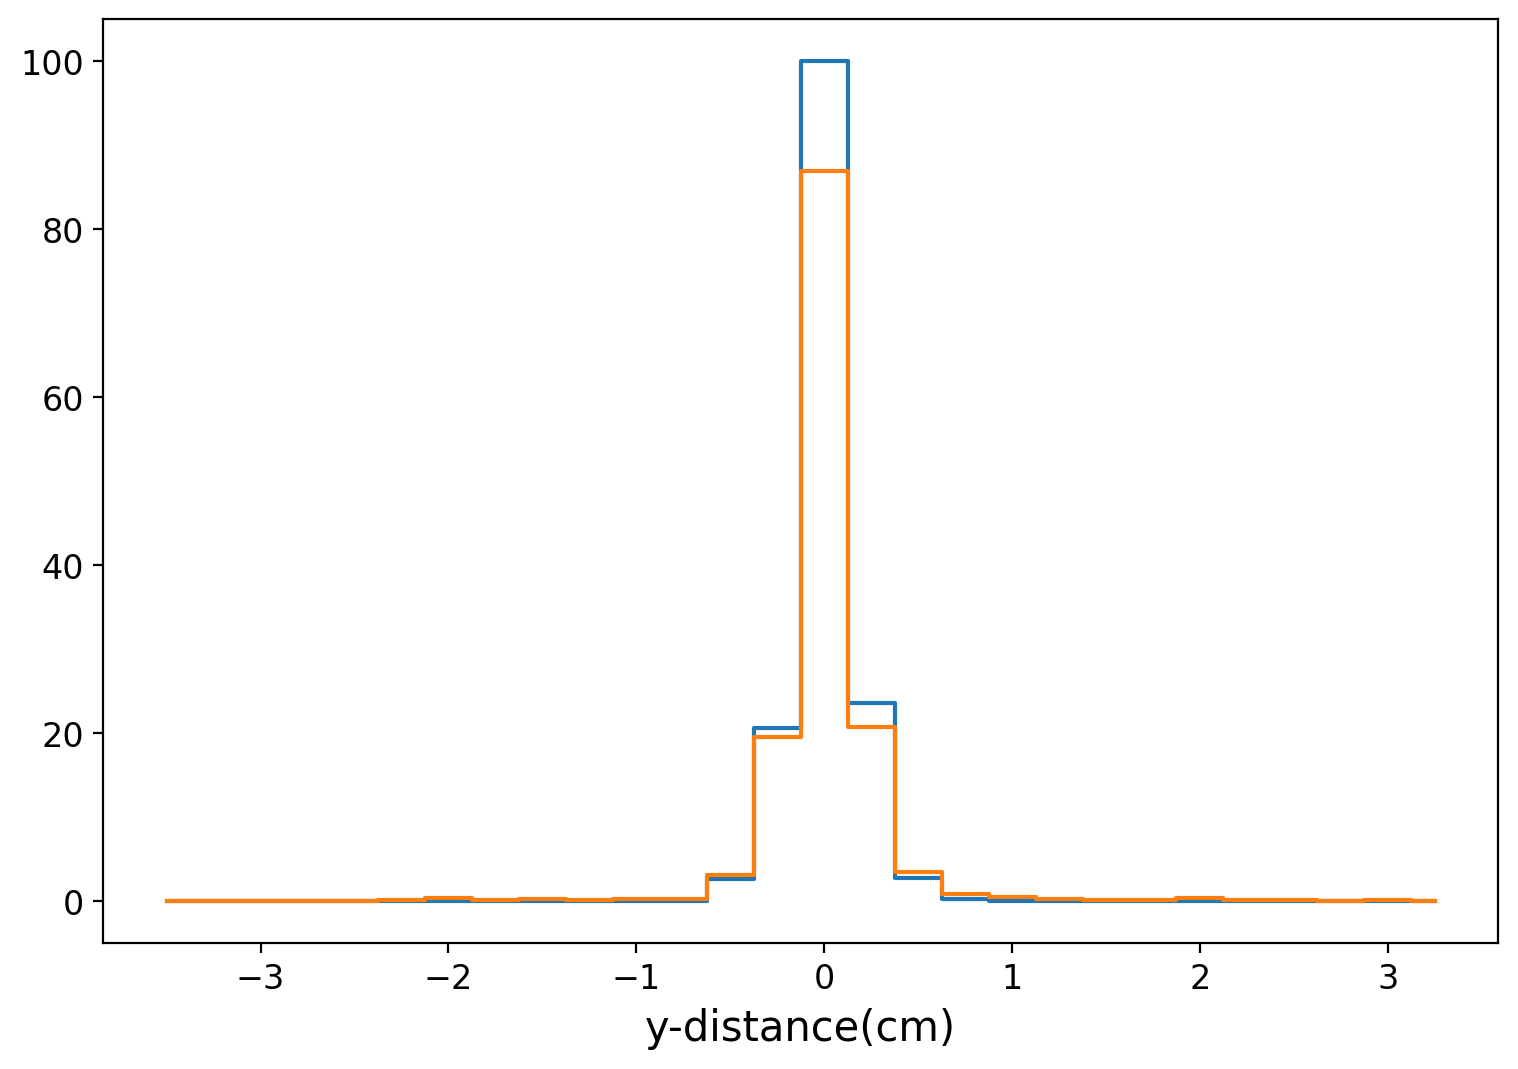

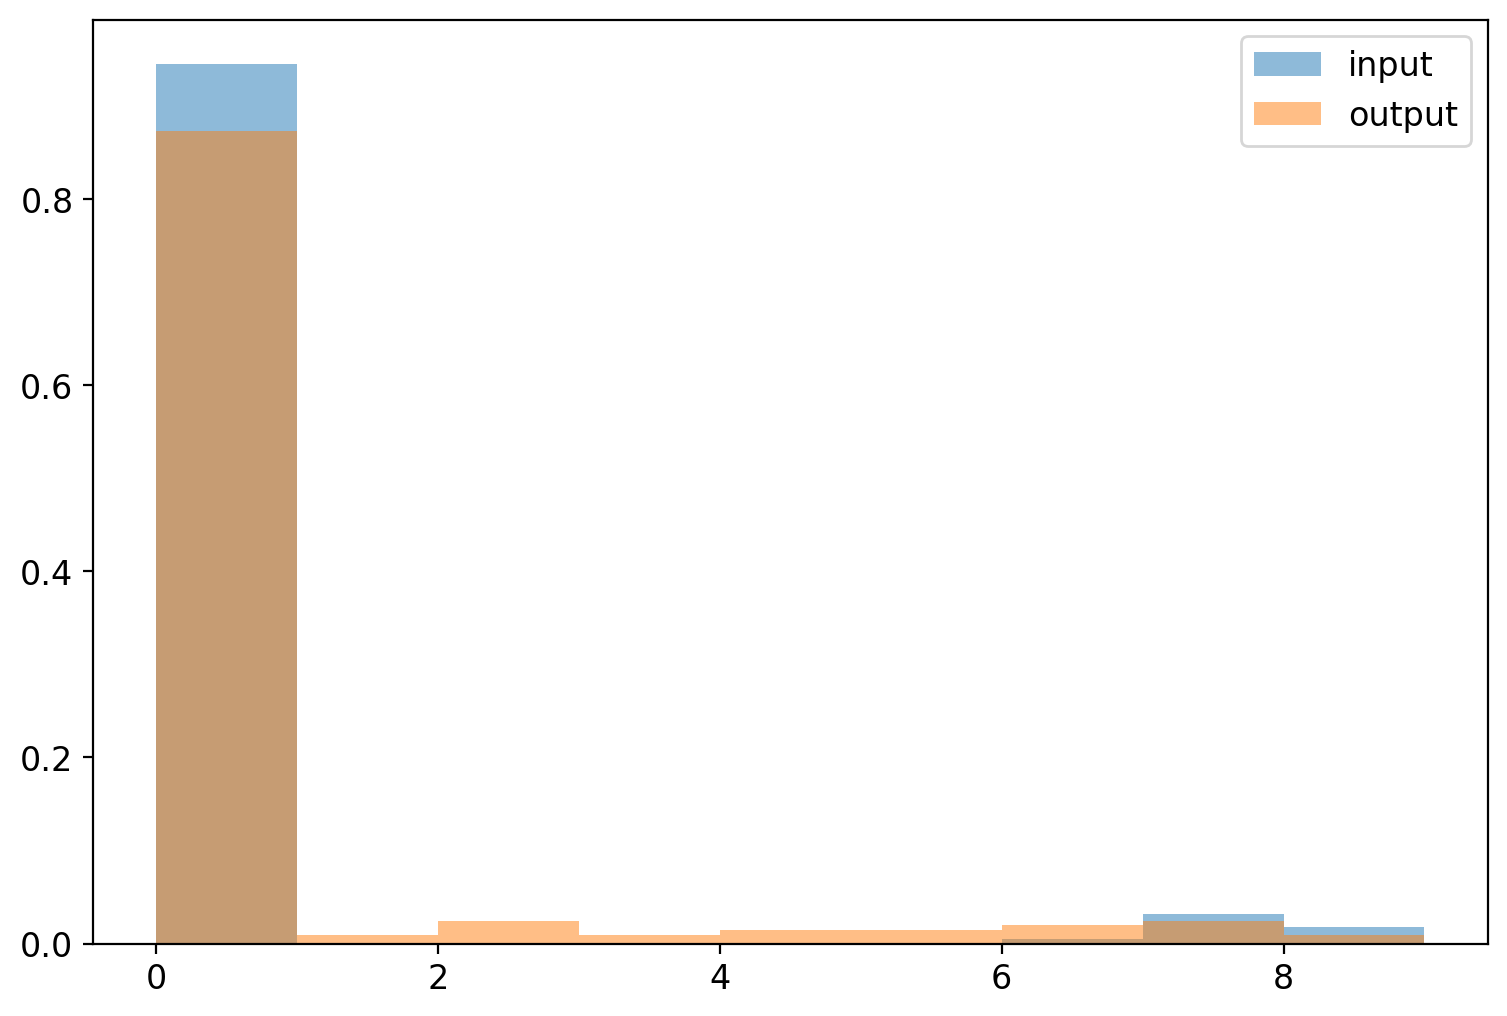

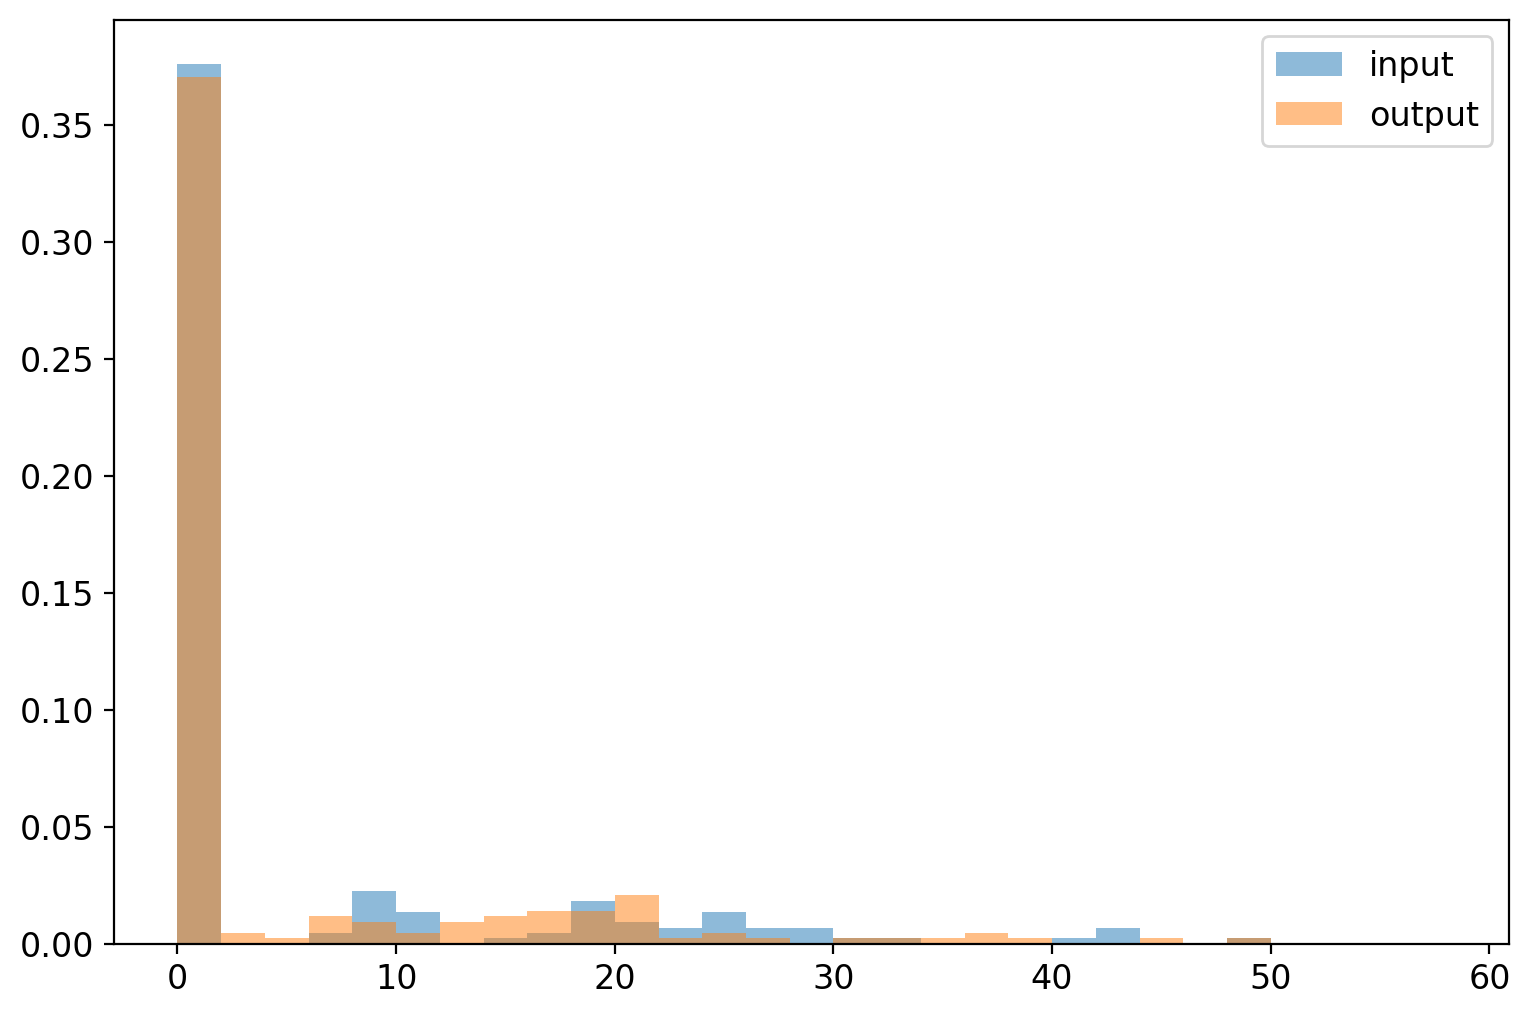

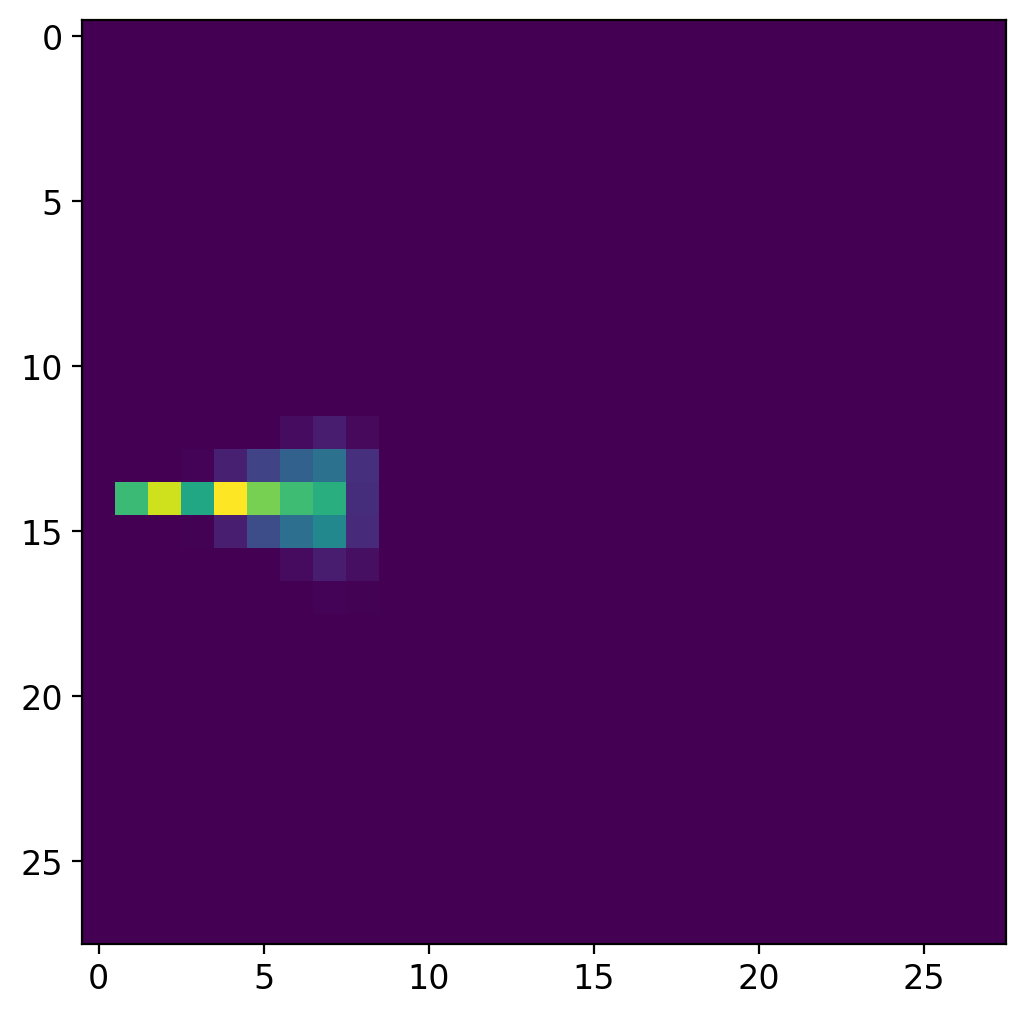

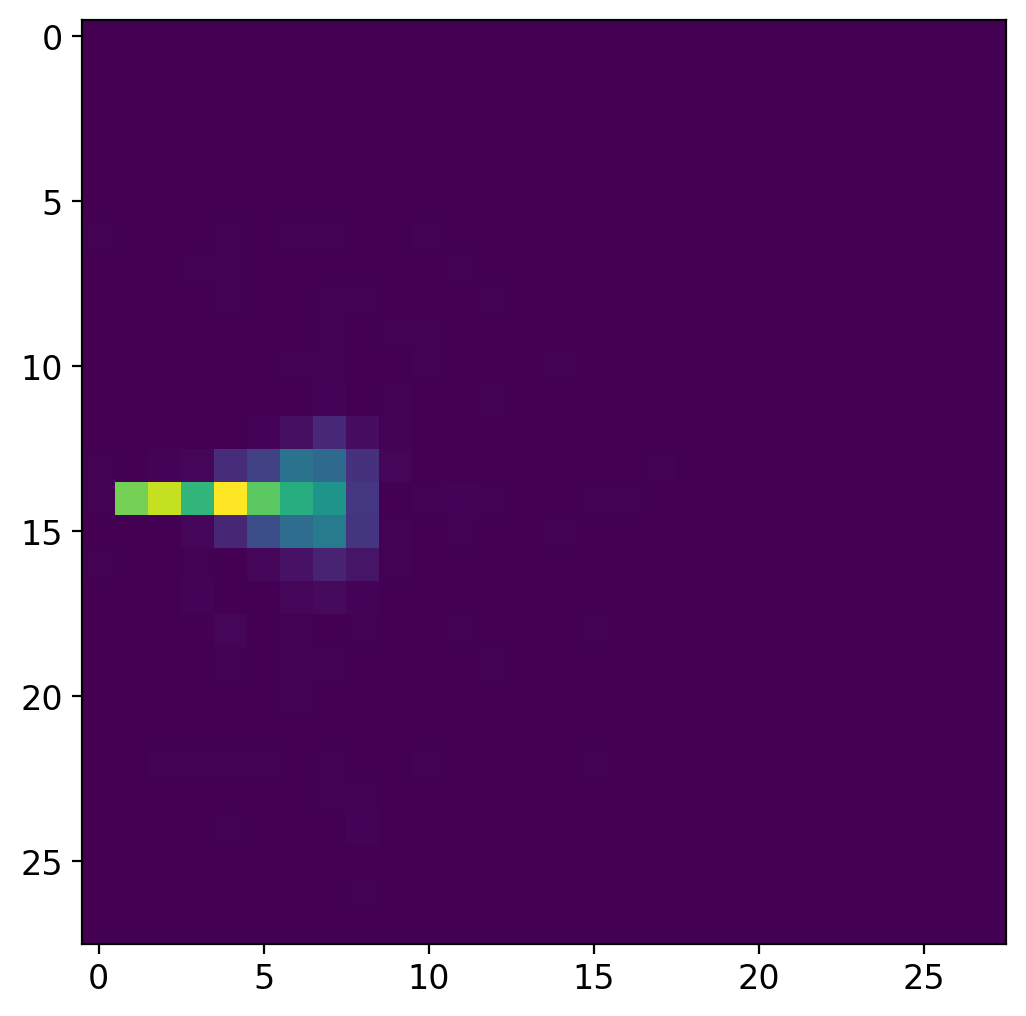

In [22]:
def plotVAEImageOutputs(iLatentDim,iDataSet):
    testlatent=torch.randn(iDataSet.shape[0],iLatentDim)
    testlatent=testlatent.reshape(iDataSet.shape[0],iLatentDim)
    rec_img  = vae.decoder(testlatent)
    rec_img  = rec_img.detach().numpy()

    xbin = np.arange(-0.5,27.5, 1)
    ybin = np.arange(-3.5, 3.5, 0.25)
    plt.plot(xbin,np.mean(np.sum(iDataSet,axis=2),axis=0).flatten(),drawstyle='steps-mid',label='MC')
    plt.plot(xbin,np.mean(np.sum(rec_img,axis=2),axis=0).flatten(),drawstyle='steps-mid',label='NN')
    plt.legend()
    plt.xlabel('x-distance(cm)')
    plt.show()


    plt.plot(ybin,np.mean(np.sum(iDataSet,axis=3),axis=0).flatten(),drawstyle='steps-mid',label='MC')
    plt.plot(ybin,np.mean(np.sum(rec_img,axis=3),axis=0).flatten(),drawstyle='steps-mid',label='NN')
    plt.xlabel('y-distance(cm)')
    plt.show()

    xrange=np.arange(0,10,1)
    plt.hist(np.sum(iDataSet,axis=2)[0:10].flatten(),label='input',alpha=0.5,bins=xrange,density=True)
    plt.hist(np.sum(rec_img ,axis=2)[0:10].flatten(),label='output',alpha=0.5,bins=xrange,density=True)
    plt.legend()
    plt.show()

    xrange=np.arange(0,60,2)
    plt.hist(np.sum(iDataSet,axis=2)[12:20].flatten(),label='input',alpha=0.5,bins=xrange,density=True)
    plt.hist(np.sum(rec_img ,axis=2)[12:20].flatten(),label='output',alpha=0.5,bins=xrange,density=True)
    plt.legend()
    plt.show()

    dimage150_avg = np.mean(iDataSet,axis=0)
    plt.imshow(dimage150_avg[0])
    plt.show()

    rec_img_avg = np.mean(rec_img,axis=0)
    plt.imshow(rec_img_avg[0])
    plt.show()

#dimage150_avg = np.mean(dimage150,axis=0)
#plt.imshow(dimage150_avg[0])
#plt.show()
#dimage150_tmp = np.mean(dimage150,axis=0)
#plt.imshow(dimage150[0][0])
#plt.show()
#test=np.mean(np.sum(dimage150,axis=3),axis=0)
plotVAEImageOutputs(d,dimage150)
torch.save(vae.state_dict(), 'vae_150.pt')

<a name='exercises_22_3'></a>     

| [Top](#section_22_0) | [Restart Section](#section_22_3) | [Next Section](#section_22_4) |


<a name='section_20_4'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.4 Conditional VAEs allowing for energy based generation </h2>  



| [Top](#section_20_0) | [Previous Section](#section_20_3) | [Exercises](#exercises_20_4) | [Next Section](#section_20_5) |

Now that we have created a basica VAE that captures most of the features that our Monte Carlo Simulation does, lets go ahead and now train for all of our beam energies.

Training with all of the beam energies is a bit trickier, because we would like to embed our knowledge of the energy into the VAE so that we can decode our setup with the knowledge of the beam energy. We can think of this as
our decorder $d(x)$ now needs to be conditional on the beam energy. We can write this as:

$$
d\left(x|E\right) = f_{NN}\left(\mathcal{N}(\vec{x}|\vec{\sigma}),E\right)
$$

Where $f_{NN}$ is our neural network, which now takes in the sampled distribution, and the energy. The scheme here is that  we are adding Energy to our latent space as an additional input that we do not sample. This construction is known as a conditional VAE, since now the latent space construction changes conditioned on the beam energy. Let's take a look at the architecture.

In [23]:
class CondVariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(CondVariationalAutoEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, stride=2, padding=1)
        self.batch2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 32, 3, stride=2, padding=0)
        self.linear1  = nn.Linear(3*3*32, 64)
        self.linear1a = nn.Linear(64, 8)
        self.linear1b = nn.Linear(9,  8)
        self.linear2 = nn.Linear(8, latent_dims)
        self.linear3 = nn.Linear(8, latent_dims)

        #Now we need sample in phase space
        self.N       = torch.distributions.Normal(0, 1)
        self.N.loc   = self.N.loc
        self.N.scale = self.N.scale
        self.kl = 0

        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            #nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )

        self.decoder_lin = nn.Sequential(
            nn.Linear(latent_dims+1, 64),
            nn.ReLU(True),
            nn.Linear(64, 3 * 3 * 32),
            nn.ReLU(True)
        )


    def encoder(self, x, c): #c is our condition
        x = F.relu(self.conv1(x))
        #x = F.relu(self.batch2(self.conv2(x)))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear1a(x))
        x = torch.hstack((x,c))
        x = F.relu(self.linear1b(x))
        mu =  self.linear2(x) #Mean in the gaussian space with the condition
        sigma = torch.exp(self.linear3(x)) #sigma in the space with the condition
        z = mu + sigma*self.N.sample(mu.shape) #smear
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum() #Now compute the KL divergence
        return z


    def decoder(self, x, c):
        x = torch.hstack((x,c))
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        return x


    def forward(self, x, c):
        z = self.encoder(x, c)
        return self.decoder(z, c)

torch.manual_seed(0)
d = 6
cvae_proton_image = CondVariationalAutoEncoder(latent_dims=d)
lr = 1e-2
optim = torch.optim.Adam(cvae_proton_image.parameters(), lr=lr, weight_decay=1e-5)
from torch.utils.data import ConcatDataset
megeimage=ConcatDataset([image150, image200,image250,image300])
train_loader = torch.utils.data.DataLoader(megeimage, batch_size=500)
#from torchsummary import summary
#summary(cvae_proton_image, ((1, 28, 28),1))

Note the subtlelties here. For this setup, we are feeding the condition in at a few different points. The condition comes in before the latent space is constructed. The condition also comes into the decoder. The point being here is that we know the condition and so we have the liberty to put this in whereever we want.

Let's go ahead and train it. We will have to rewrite the functions for training from above, so we put them down here:


 EPOCH 1/500 	 train loss 4864.685 	 val loss 0.000


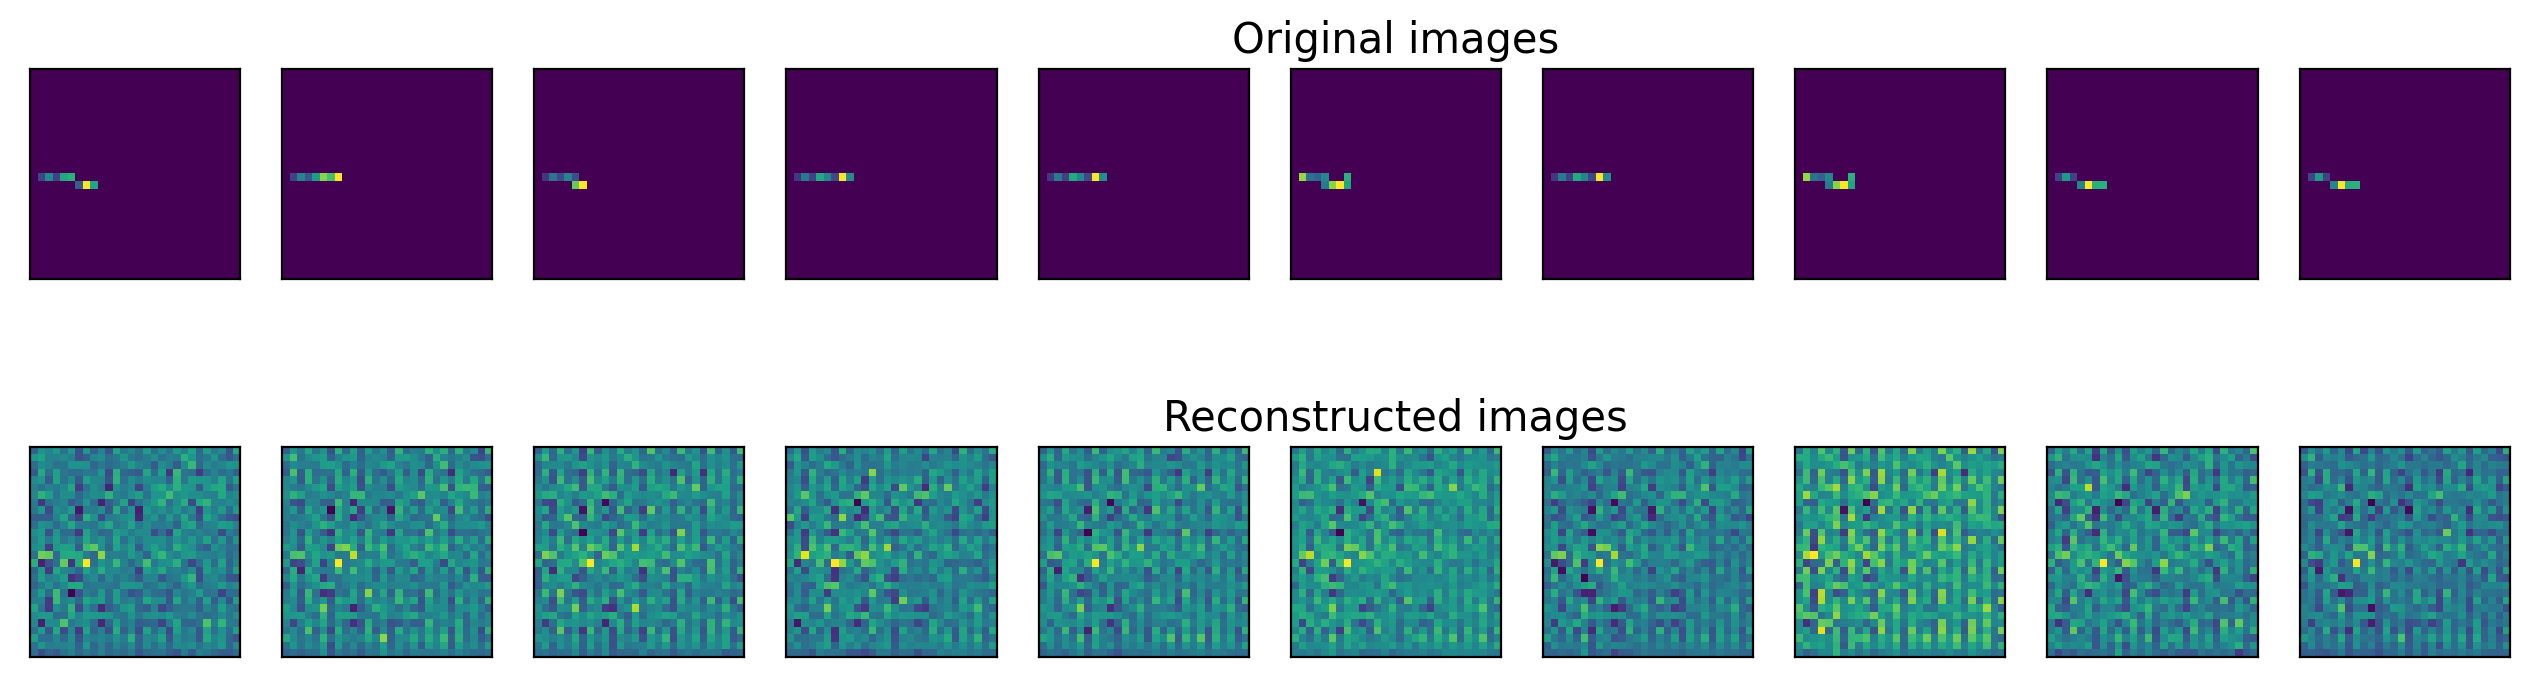


 EPOCH 51/500 	 train loss 2915.027 	 val loss 0.000


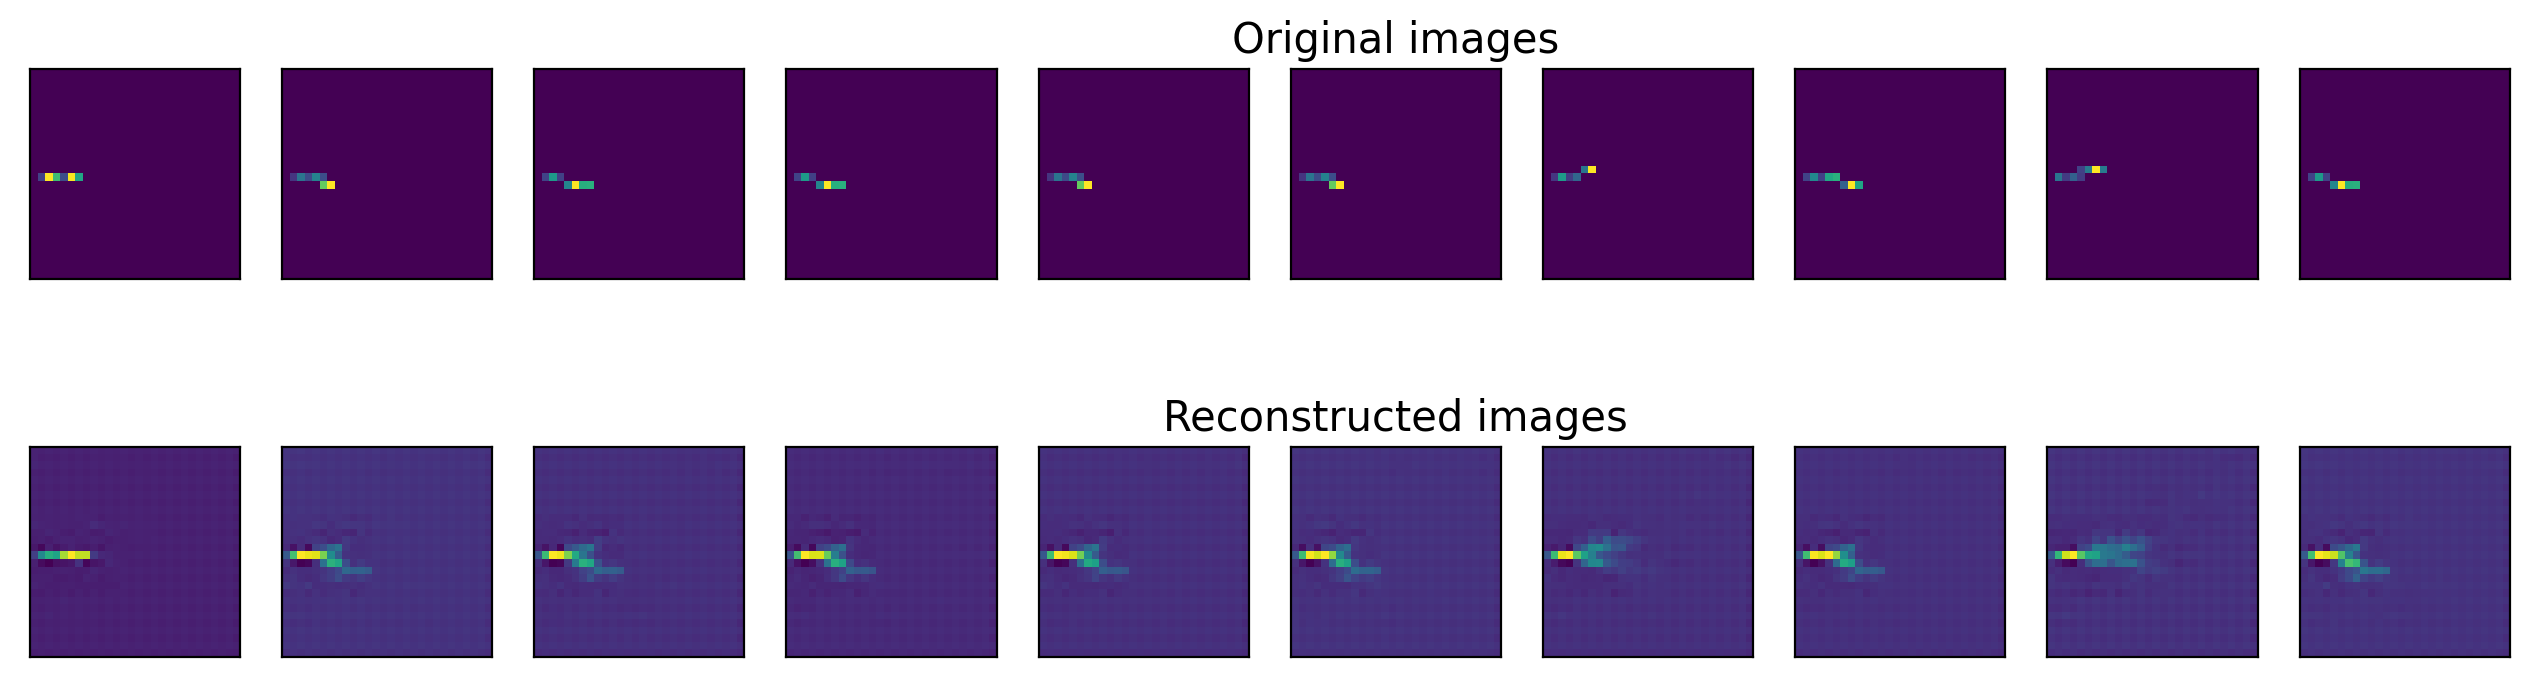


 EPOCH 101/500 	 train loss 2125.803 	 val loss 0.000


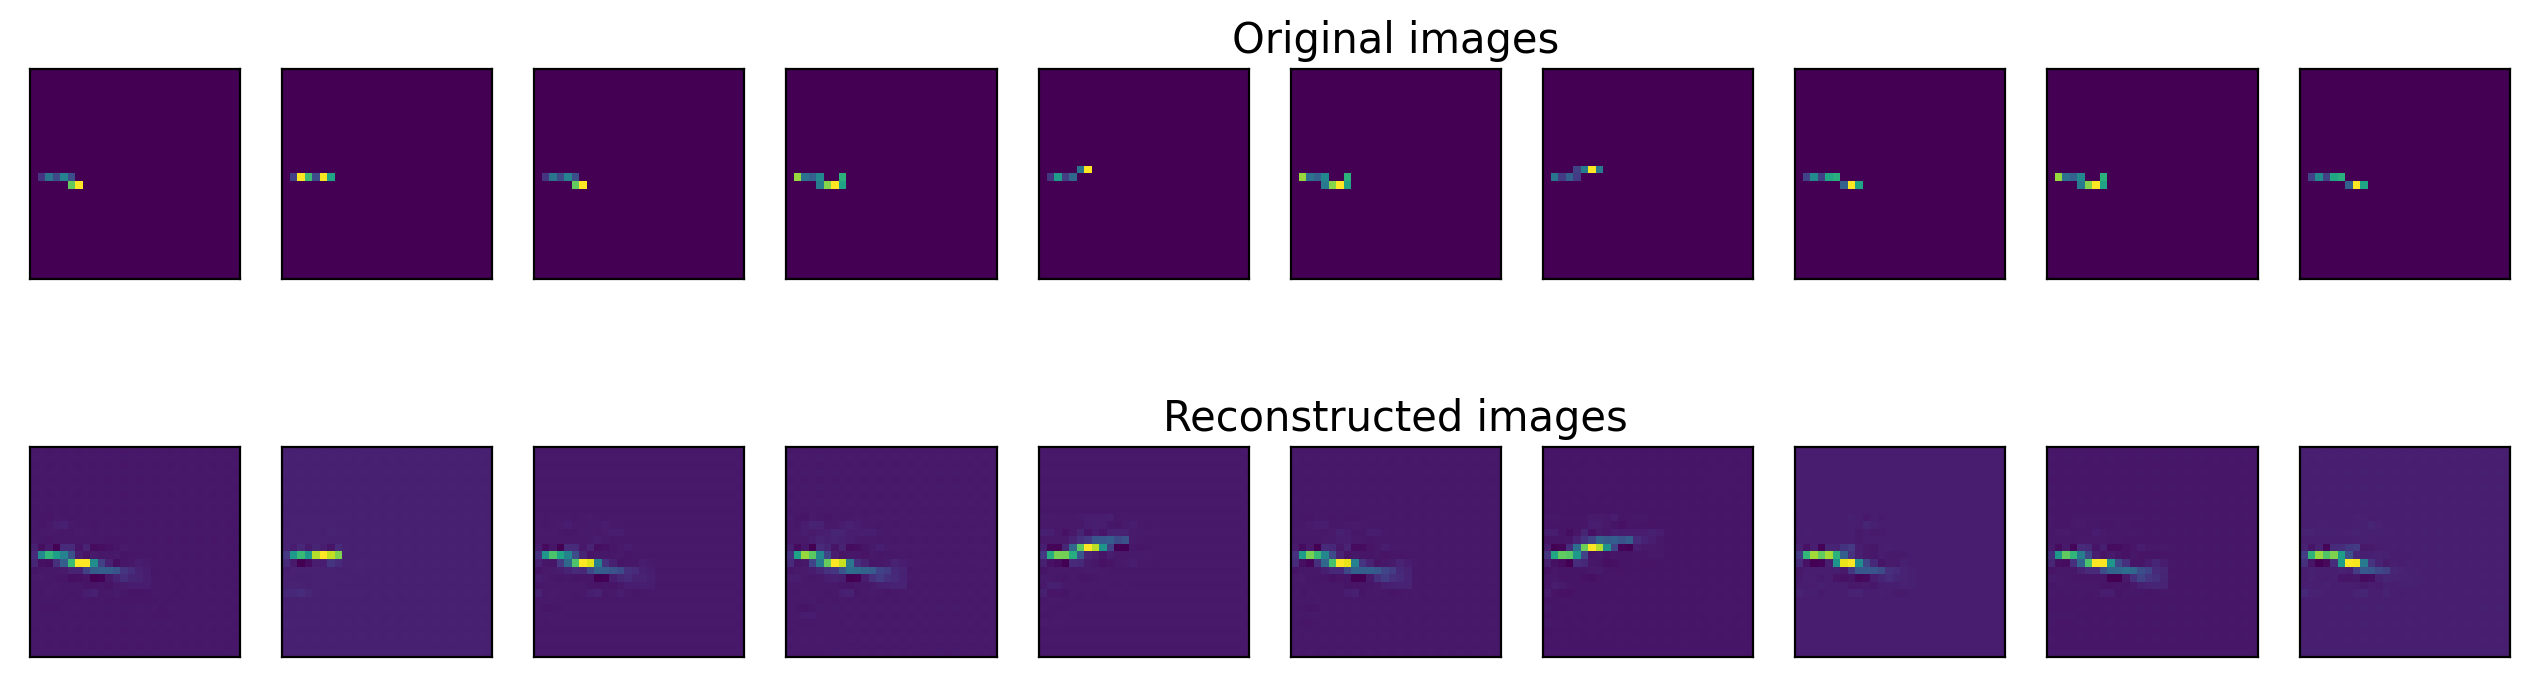


 EPOCH 151/500 	 train loss 1777.800 	 val loss 0.000


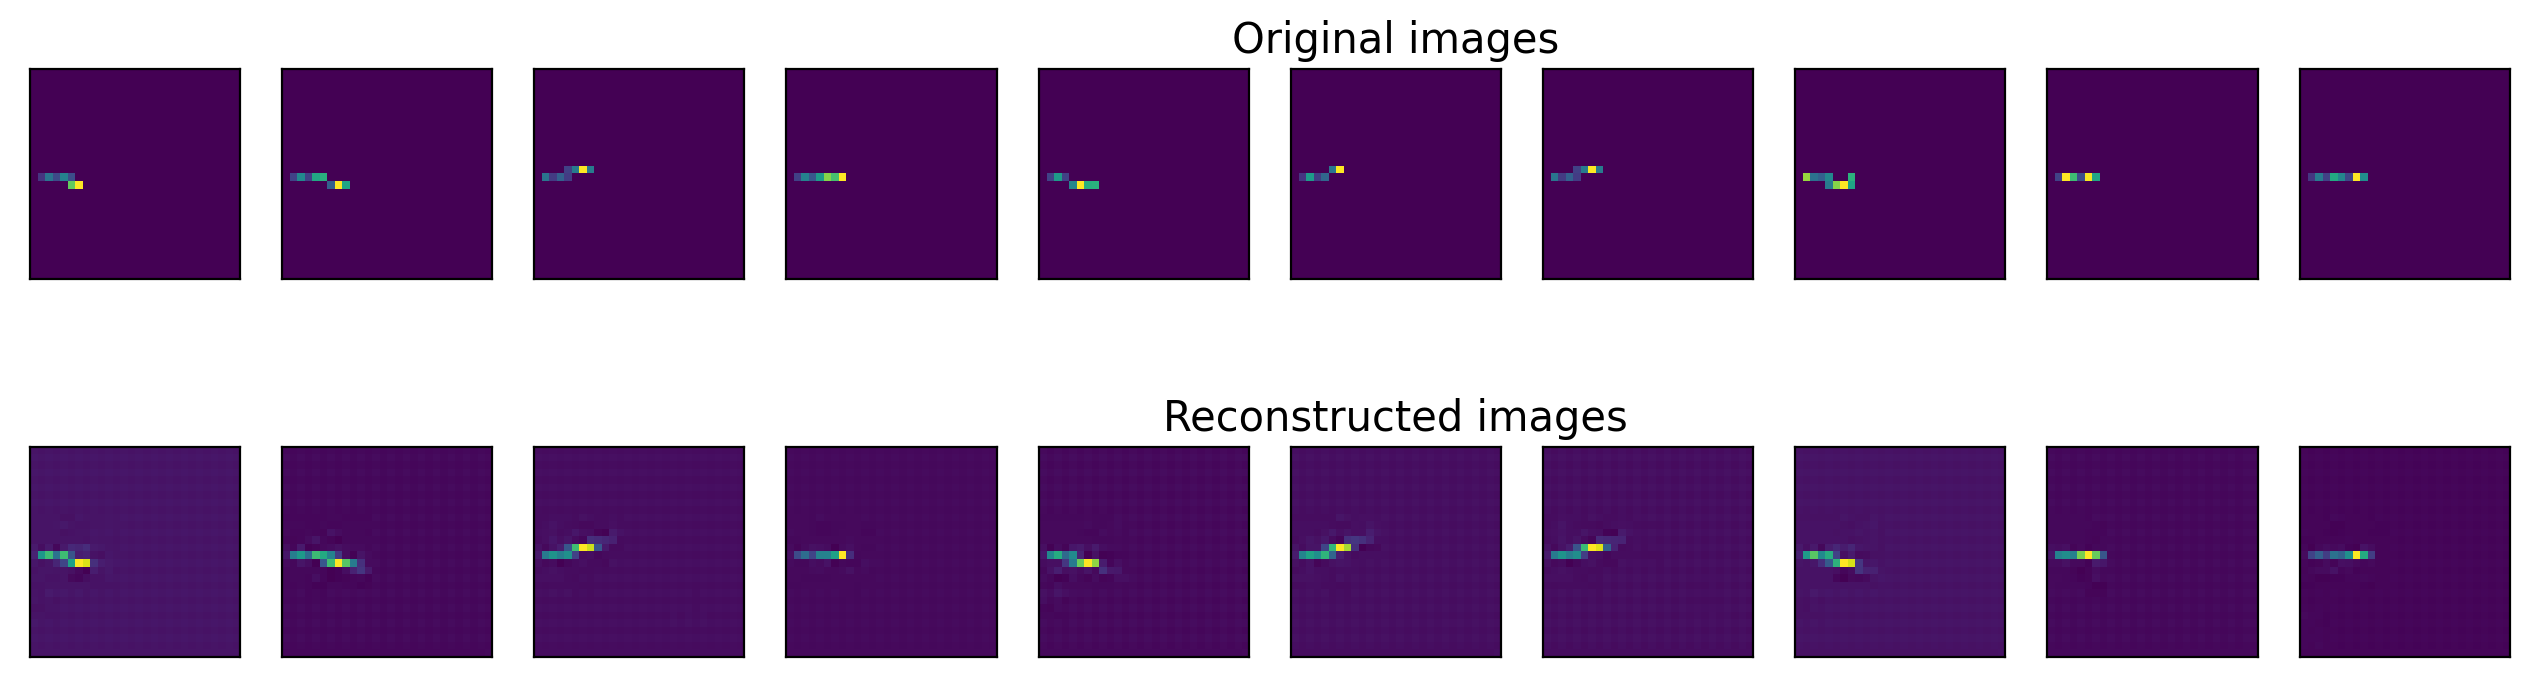


 EPOCH 201/500 	 train loss 1573.834 	 val loss 0.000


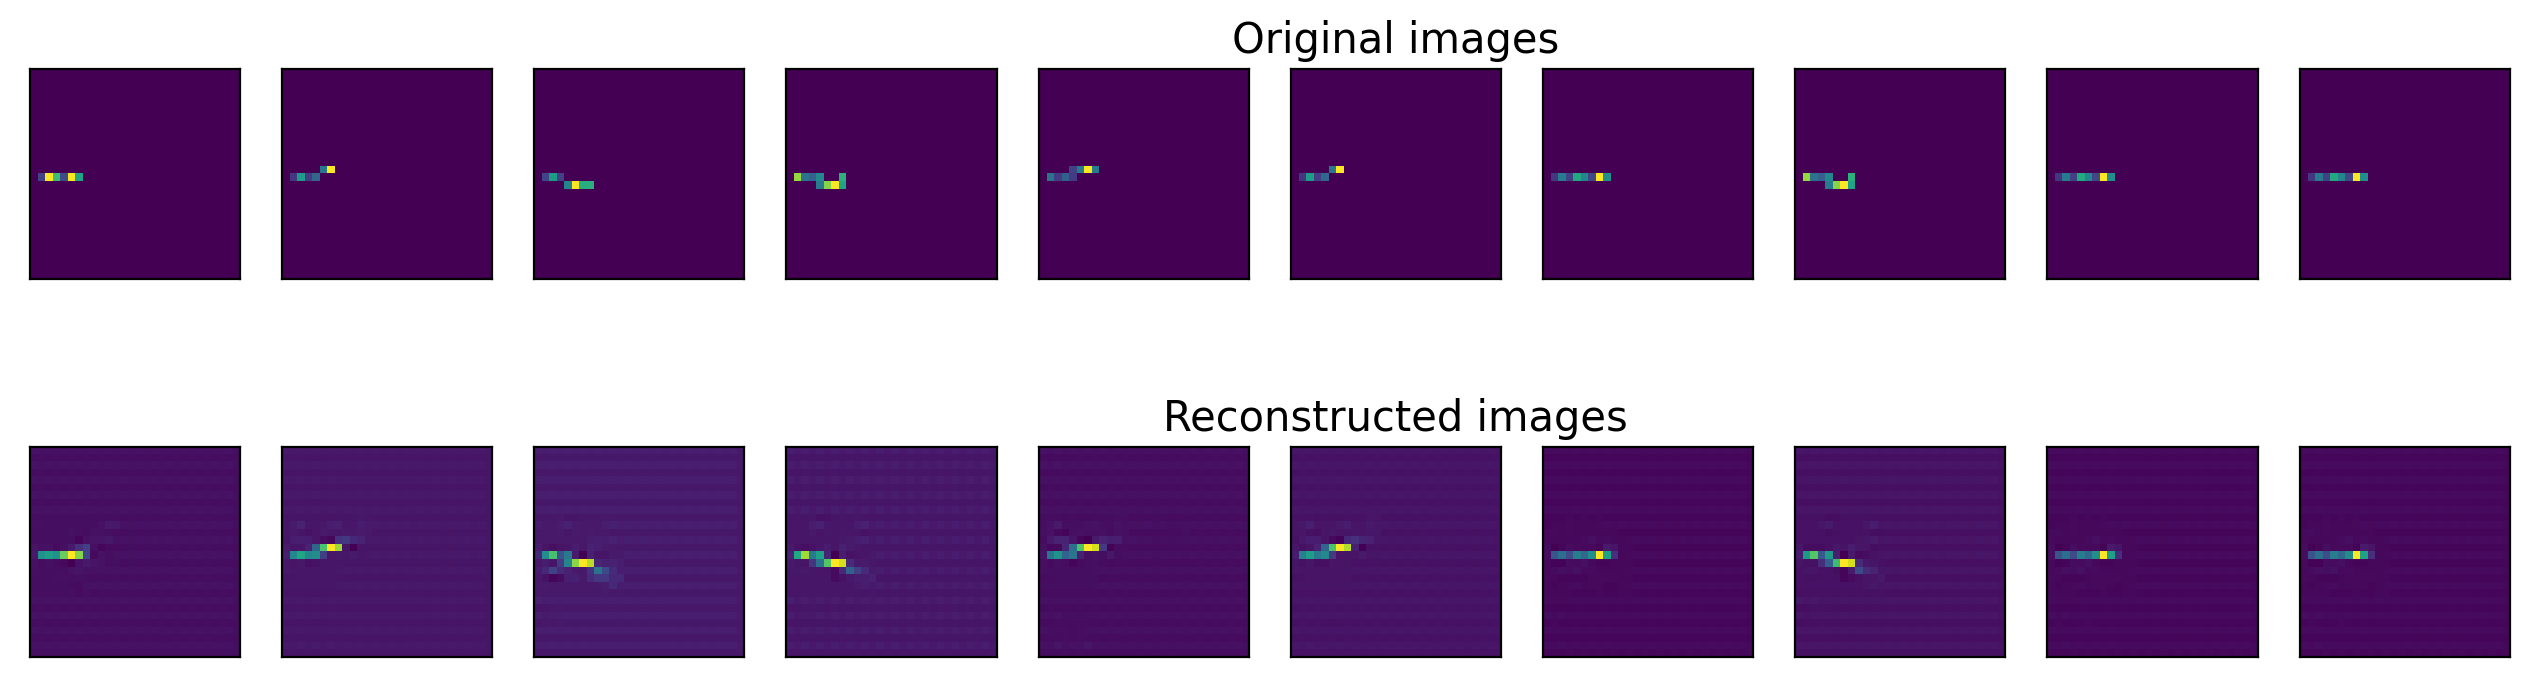


 EPOCH 251/500 	 train loss 1479.084 	 val loss 0.000


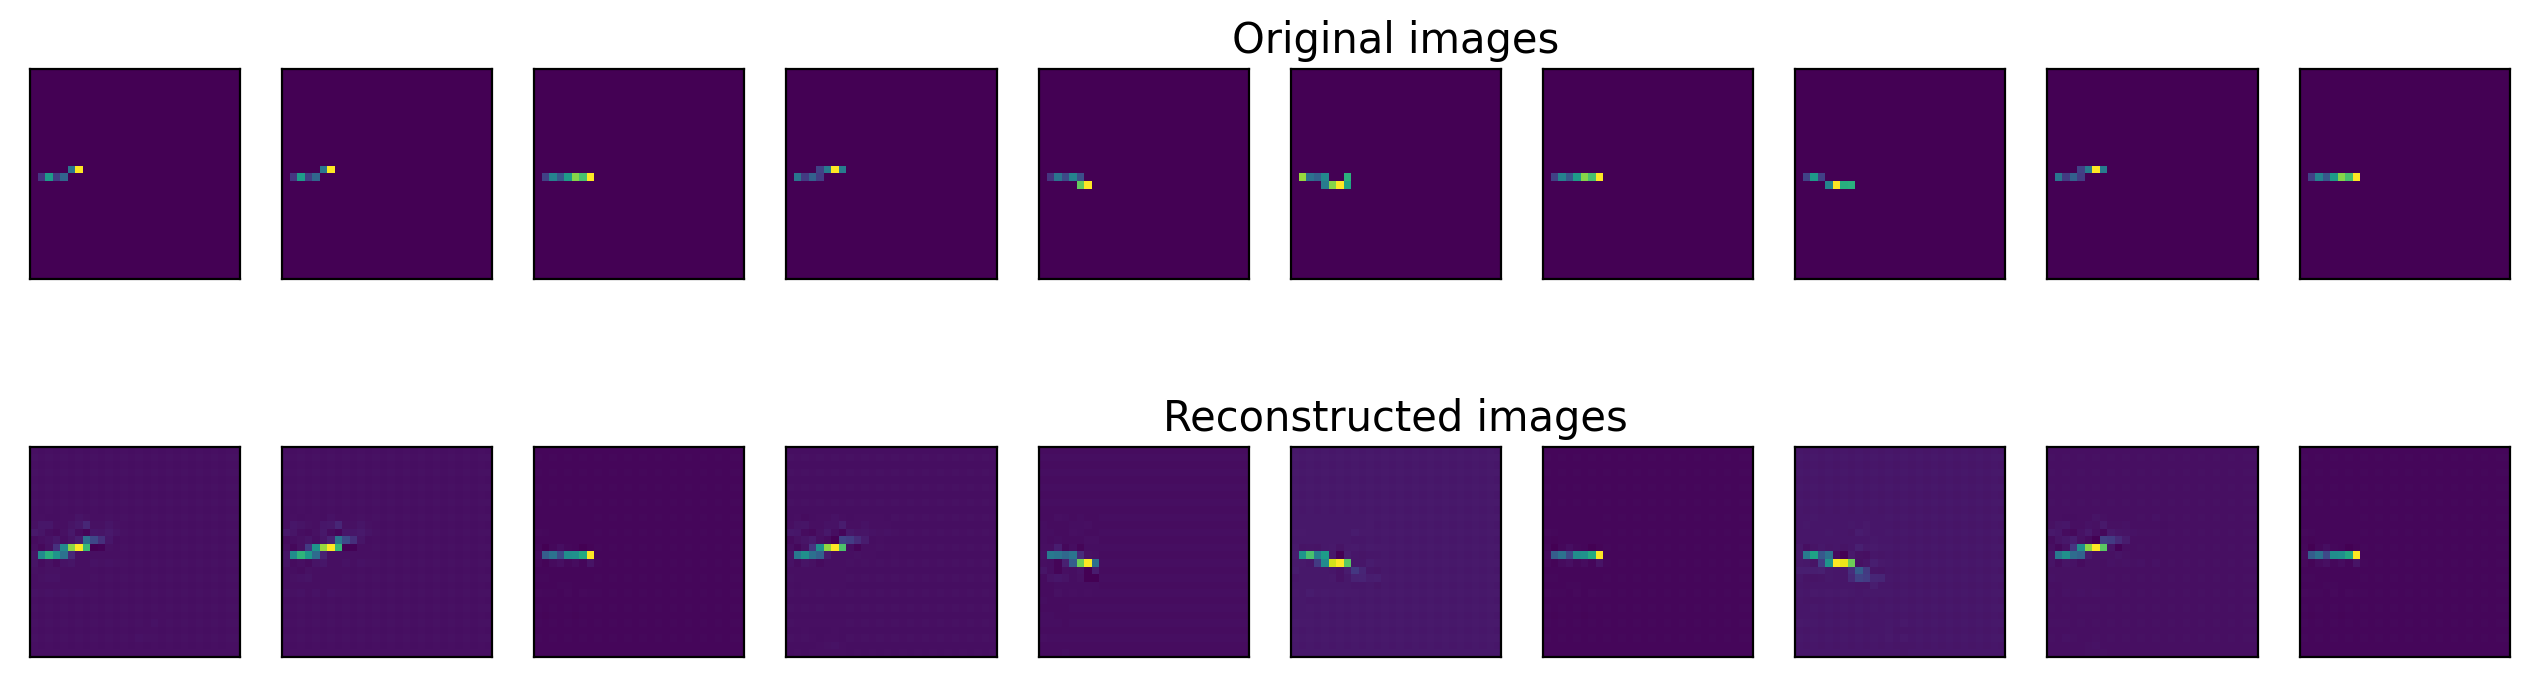


 EPOCH 301/500 	 train loss 1408.480 	 val loss 0.000


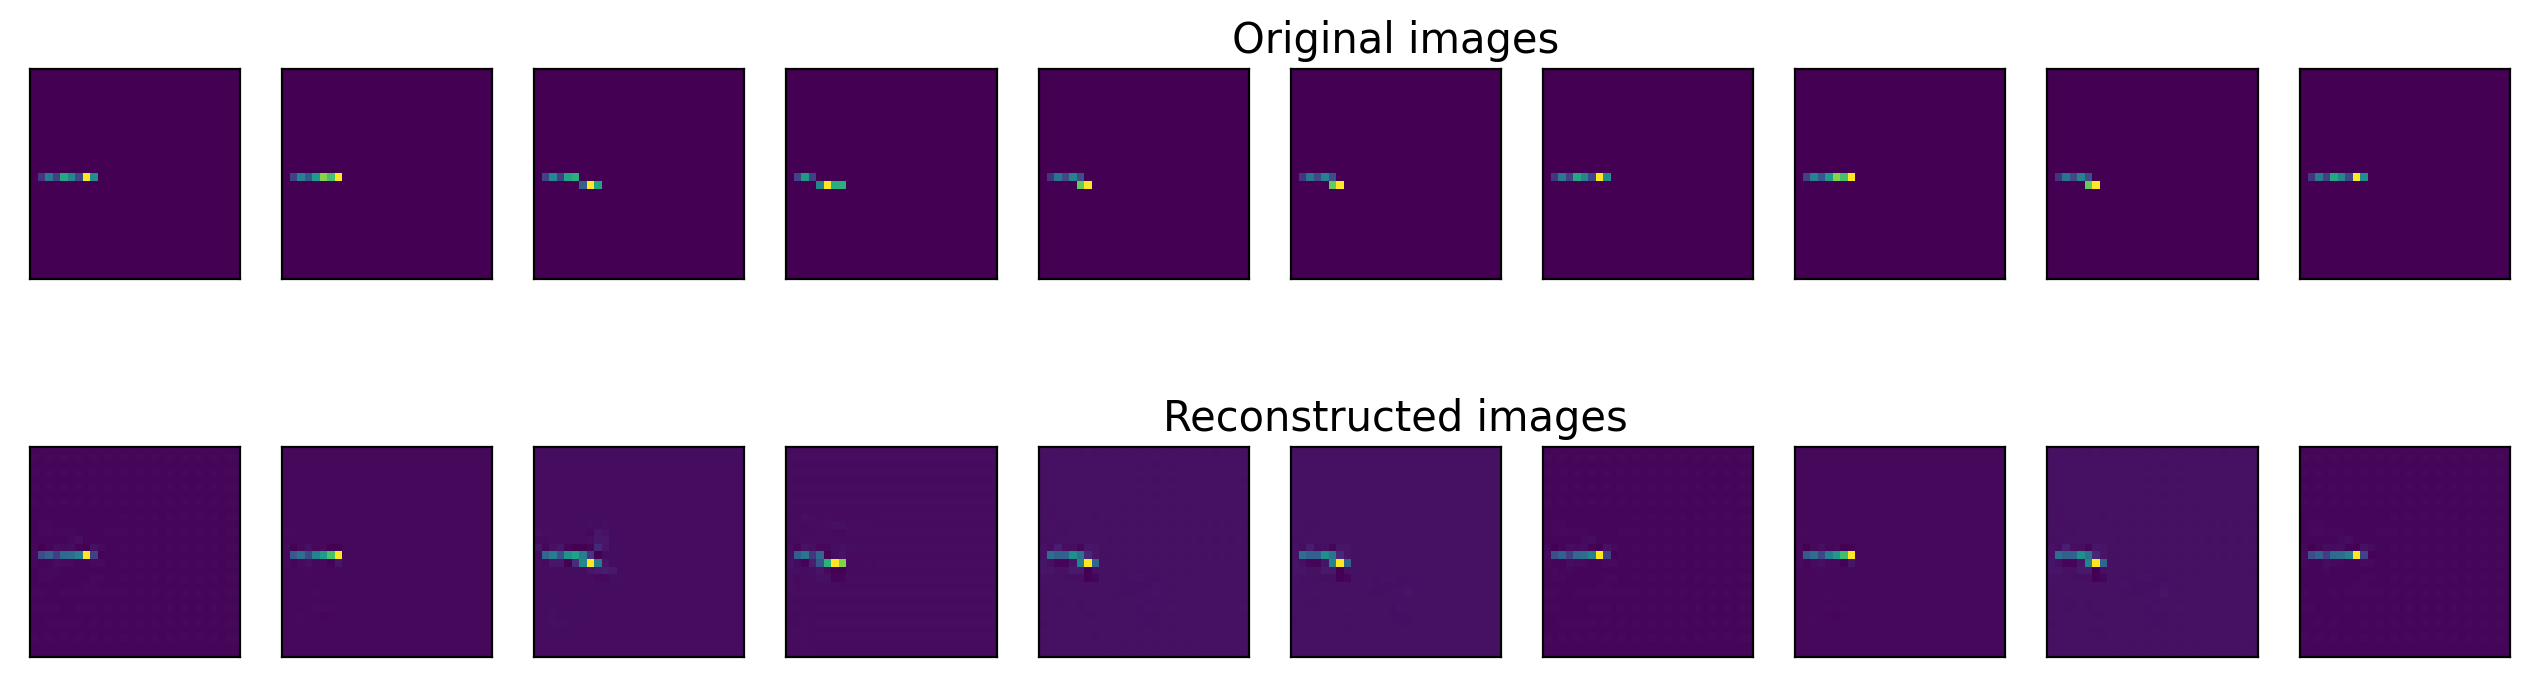


 EPOCH 351/500 	 train loss 1285.452 	 val loss 0.000


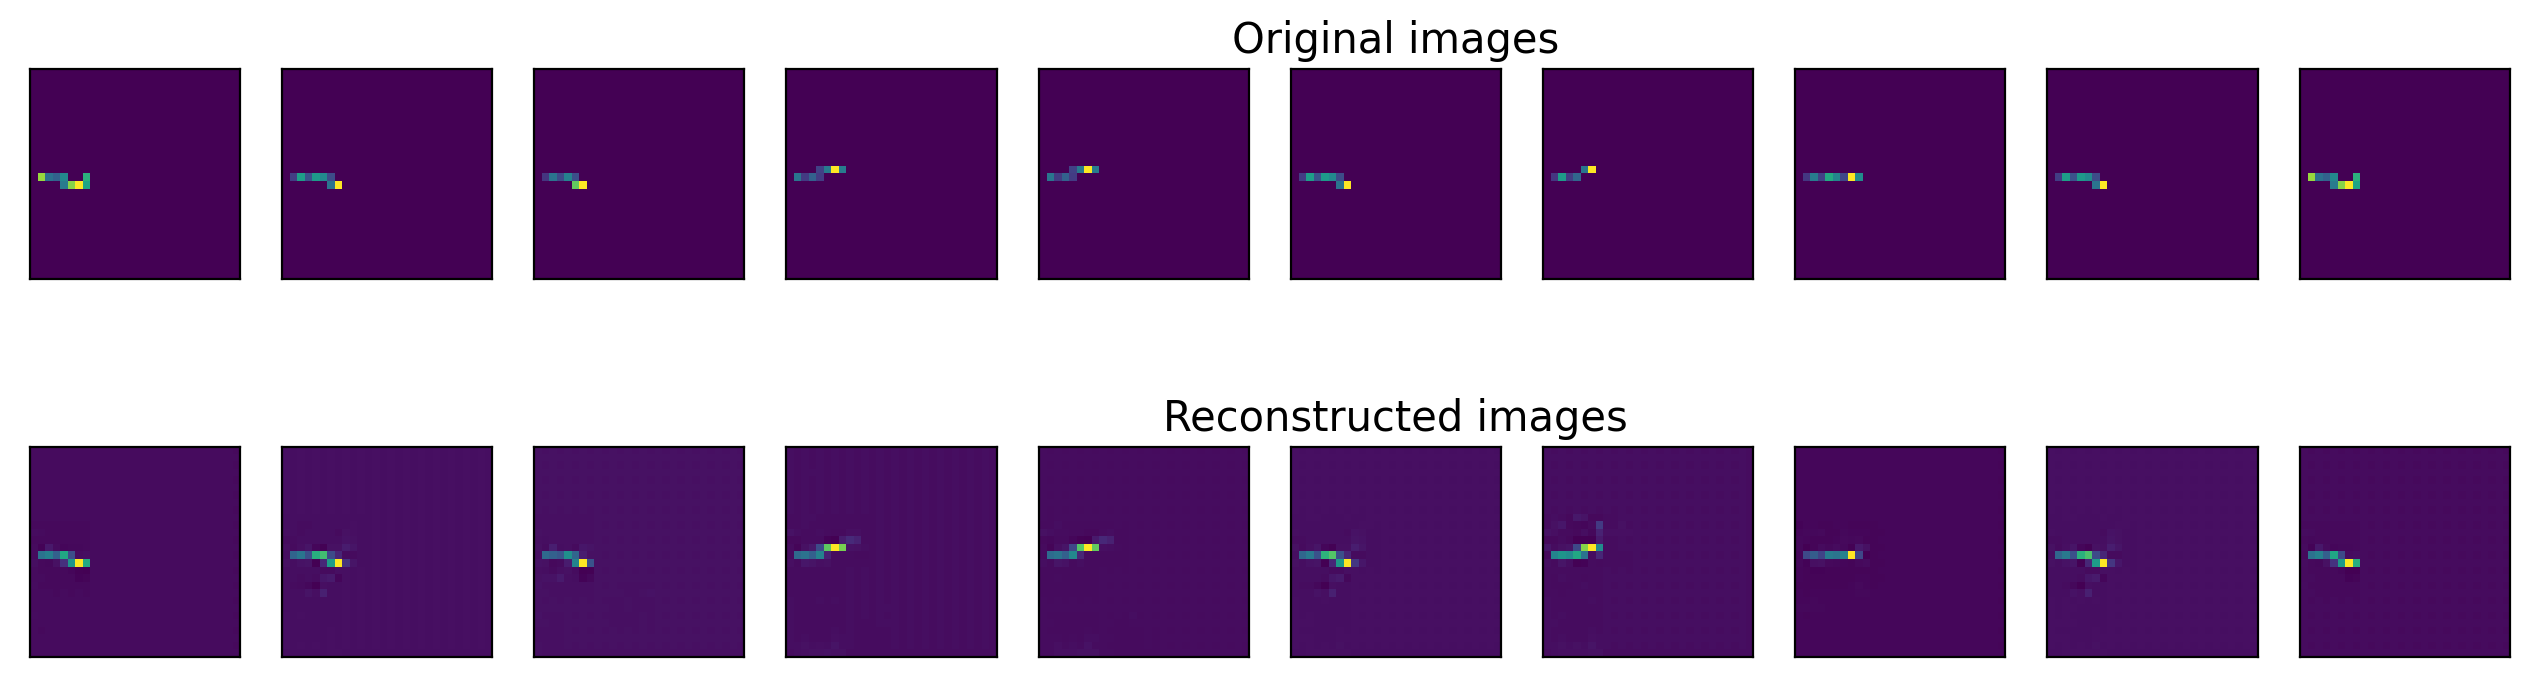


 EPOCH 401/500 	 train loss 1232.081 	 val loss 0.000


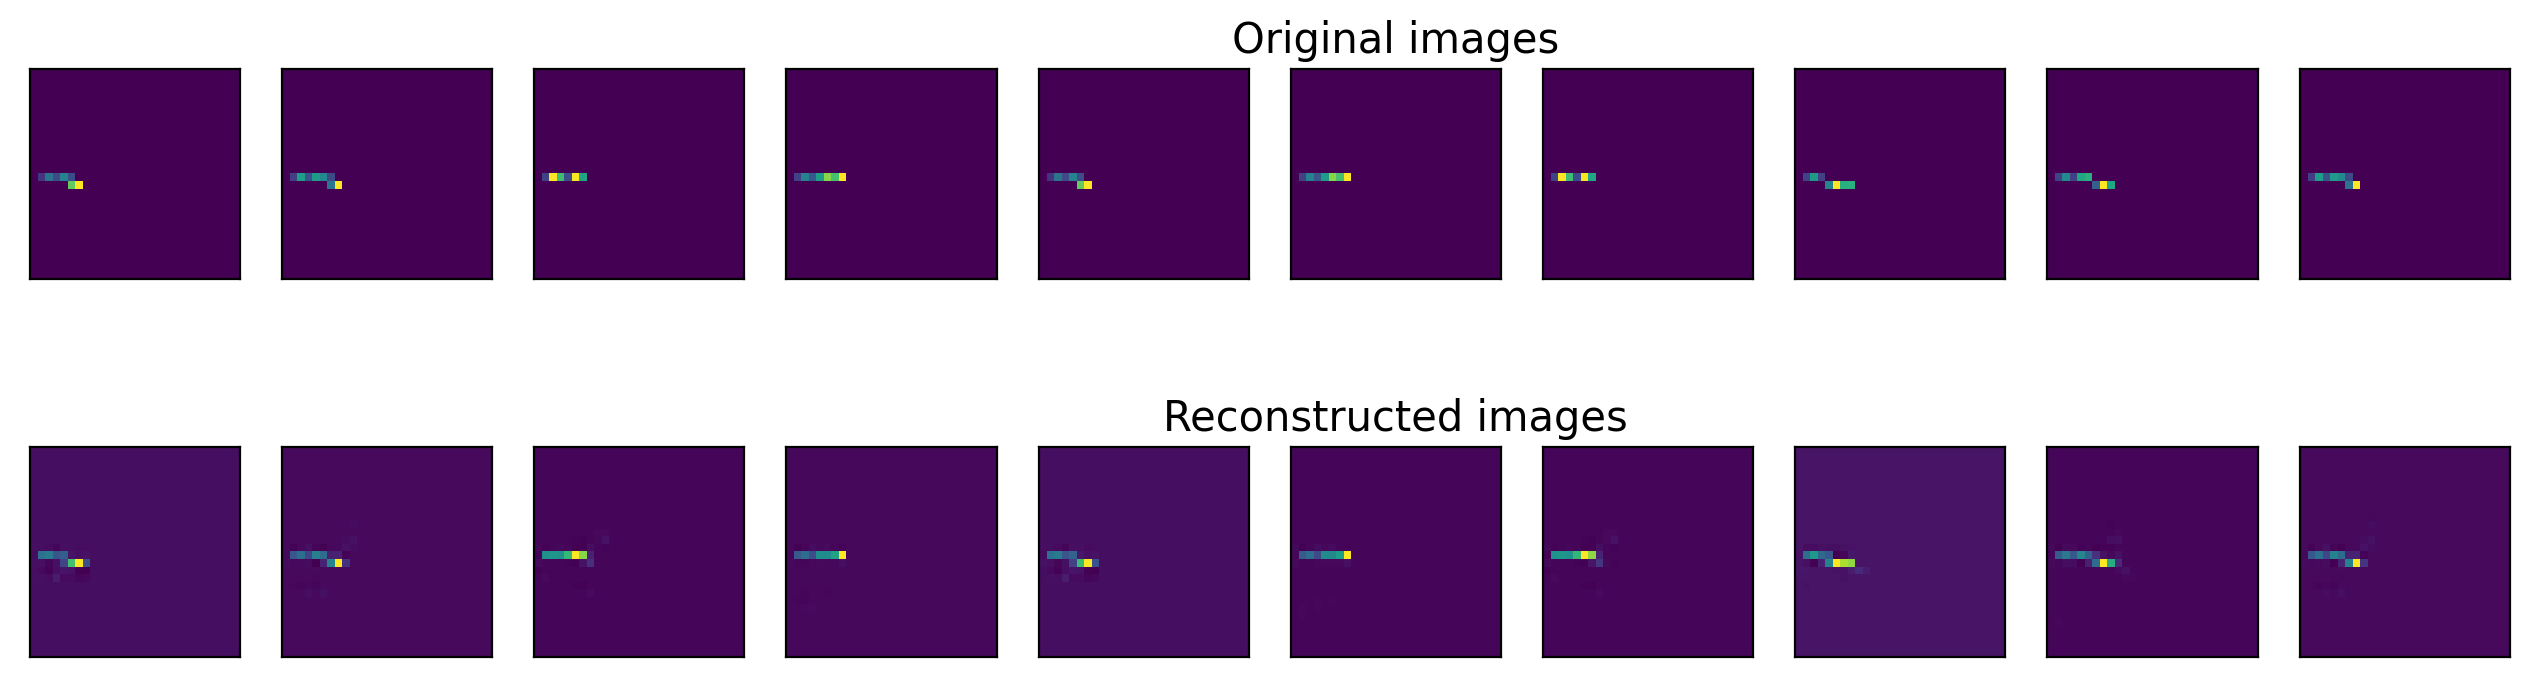


 EPOCH 451/500 	 train loss 1229.463 	 val loss 0.000


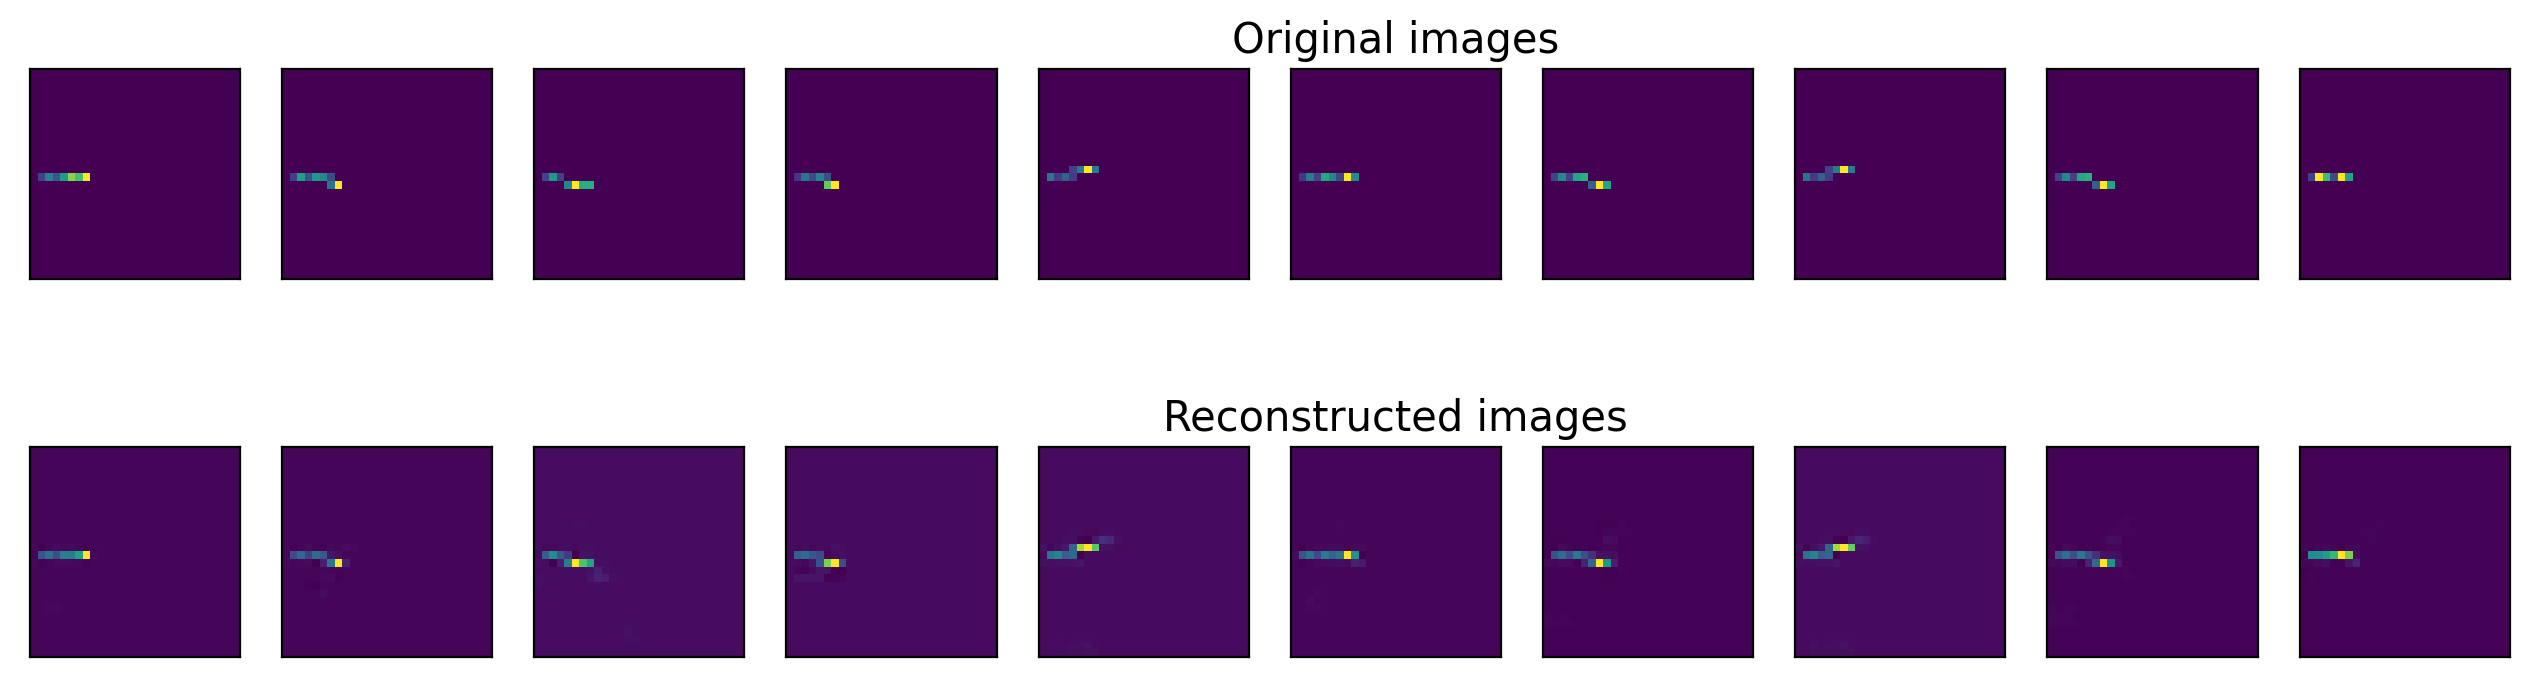

In [24]:
def plot_ae_outputs(idataset,ivae,n=10):
    plt.figure(figsize=(16,4.5))
    t_idx = np.random.randint(10,size=10)
    for i in range(n):
      ax = plt.subplot(2,n,i+1)
      img = idataset[t_idx[i]][0].unsqueeze(0)
      ivae.eval()
      #encoder.eval()
      #decoder.eval()
      npones=np.ones((1,1))*1.50
      beam=torch.tensor(npones).float()
      with torch.no_grad():
         rec_img  = ivae.decoder(ivae.encoder(img,beam),beam)
      plt.imshow(img.cpu().squeeze().numpy())#, cmap='gist_gray')
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)
      if i == n//2:
        ax.set_title('Original images')
      ax = plt.subplot(2, n, i + 1 + n)
      plt.imshow(rec_img.cpu().squeeze().numpy())#, cmap='gist_gray')
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)
      if i == n//2:
         ax.set_title('Reconstructed images')
    plt.show()

### Training function
def train_epoch(vae, dataloader, optimizer):
    # Set train mode for both the encoder and the decoder
    vae.train()
    train_loss = 0.0
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for x, c in dataloader:
        # Move tensor to the proper device
        c=c.reshape(len(c),1).float()
        x_hat = vae(x,c)
        # Evaluate loss
        loss = ((x - x_hat)**2).sum() + vae.kl
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        #print('\t partial train loss (single batch): %f' % (loss.item()))
        train_loss+=loss.item()

    return train_loss / len(dataloader.dataset)

lr = 1e-3
optim = torch.optim.Adam(cvae_proton_image.parameters(), lr=lr, weight_decay=1e-5)

num_epochs = 500

for epoch in range(num_epochs):
    train_loss = train_epoch(cvae_proton_image,train_loader,optim)
    val_loss=0
    if epoch % 50 == 0:
        print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(epoch + 1, num_epochs,train_loss,val_loss))
        plot_ae_outputs(image150,cvae_proton_image,n=10)

Now, lets go ahead and see how well our conditional VAE models the shower shapes, as we vary the shower.

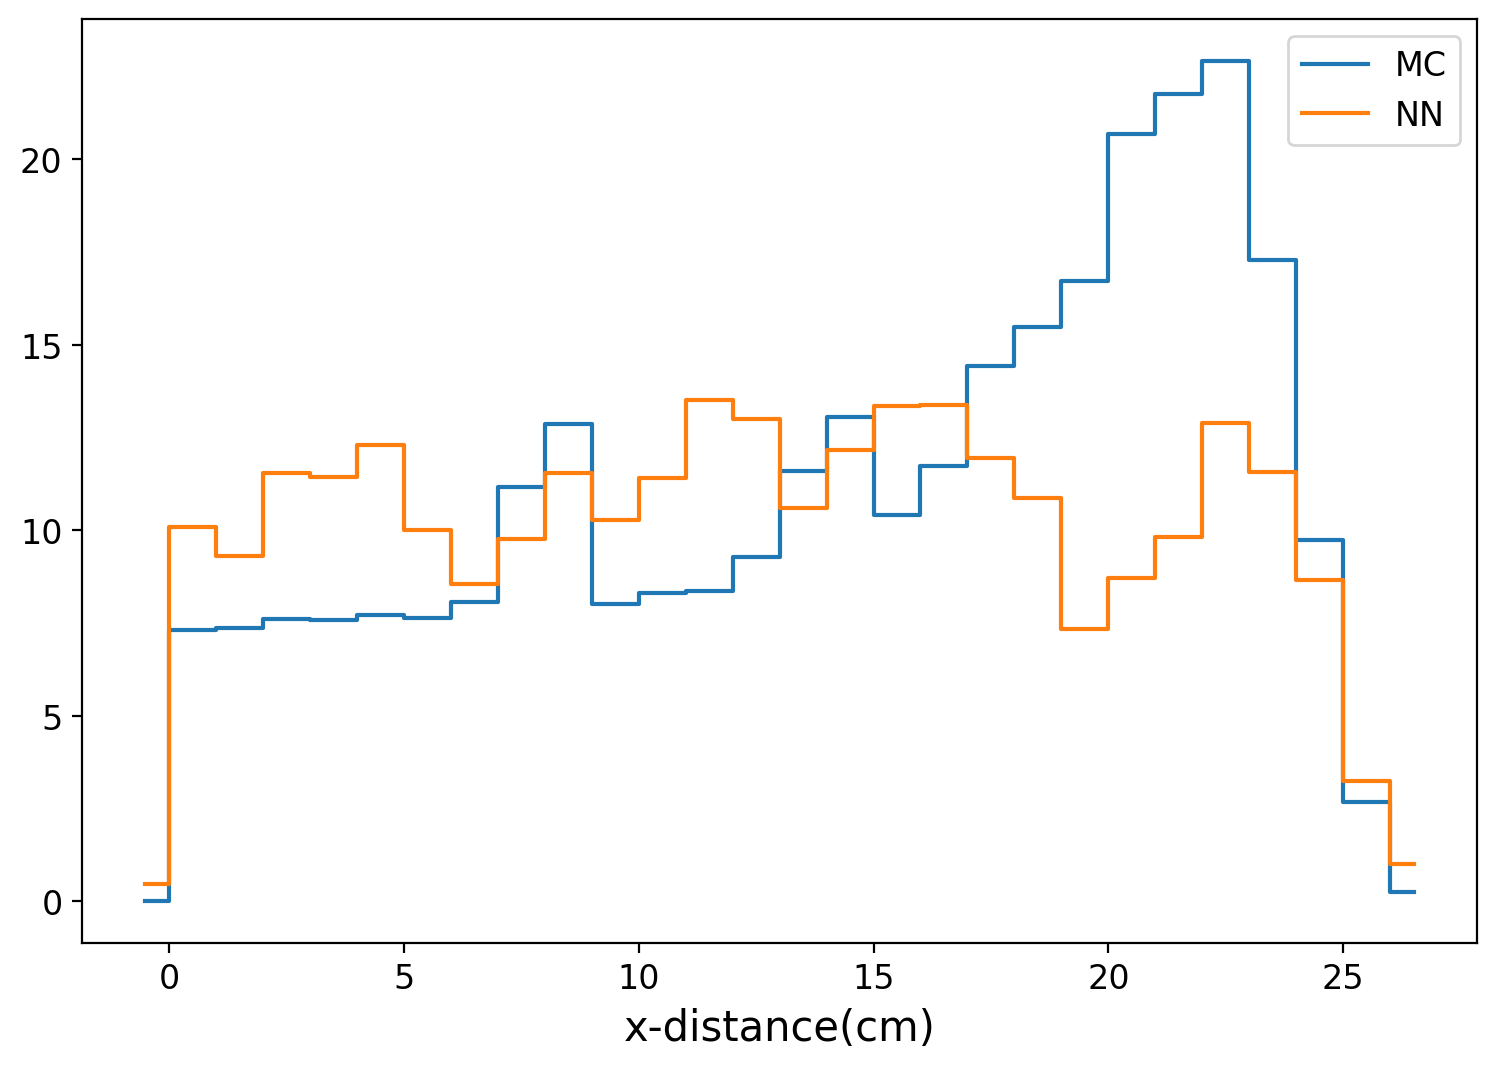

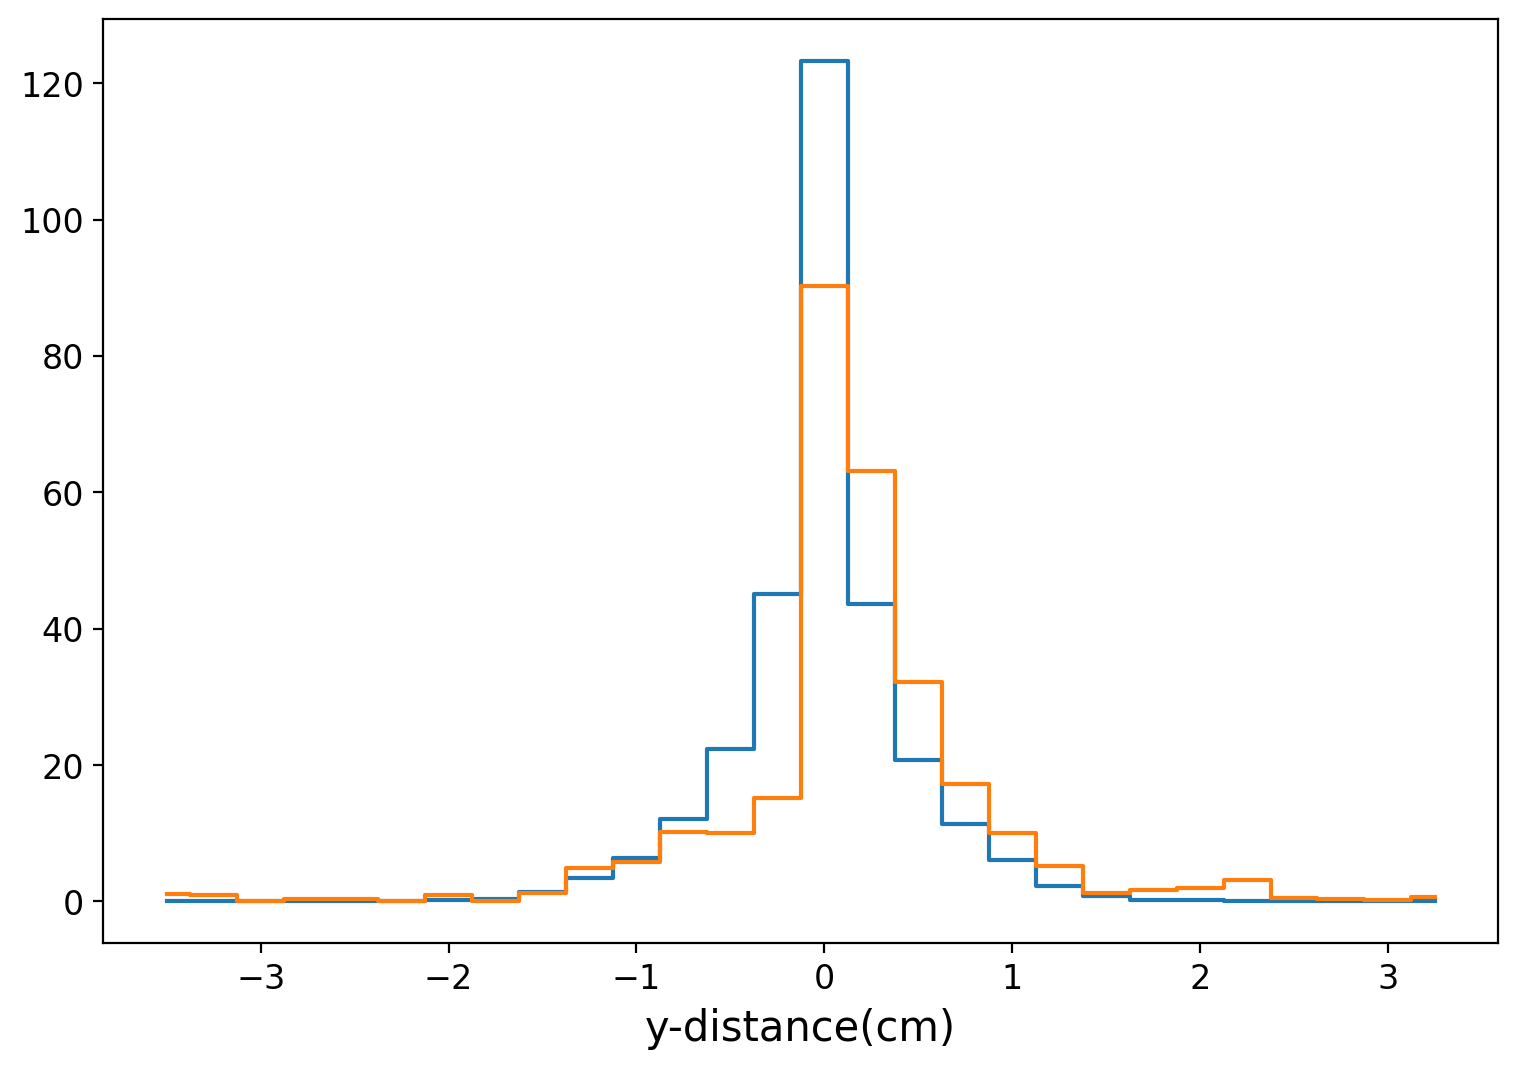

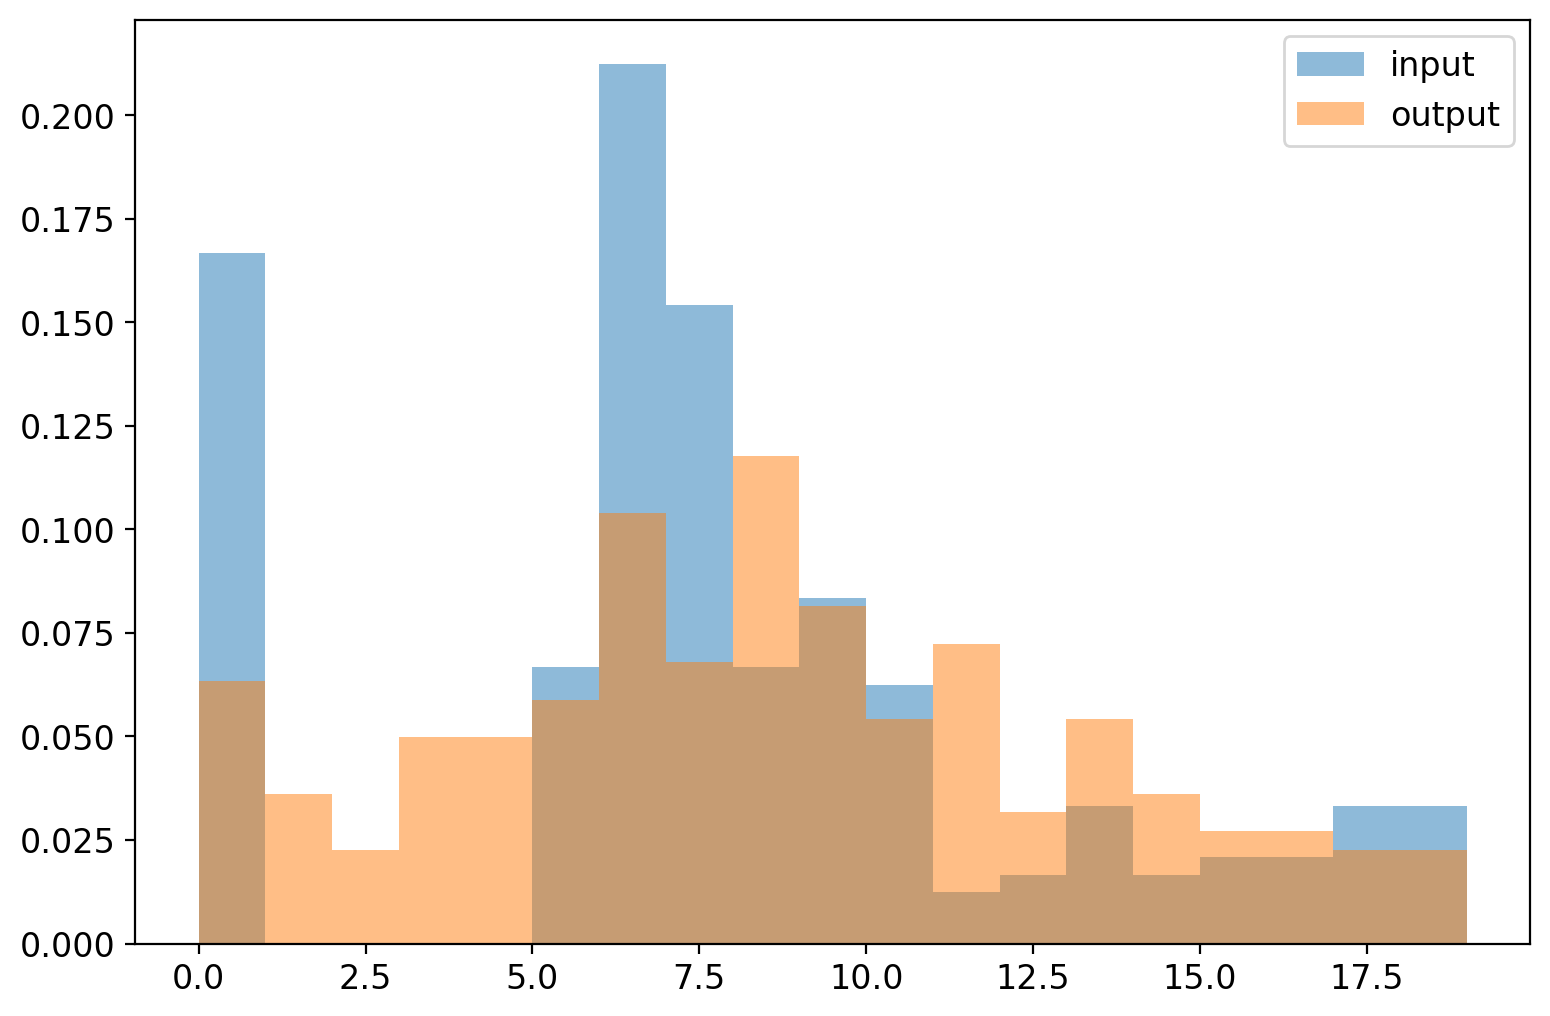

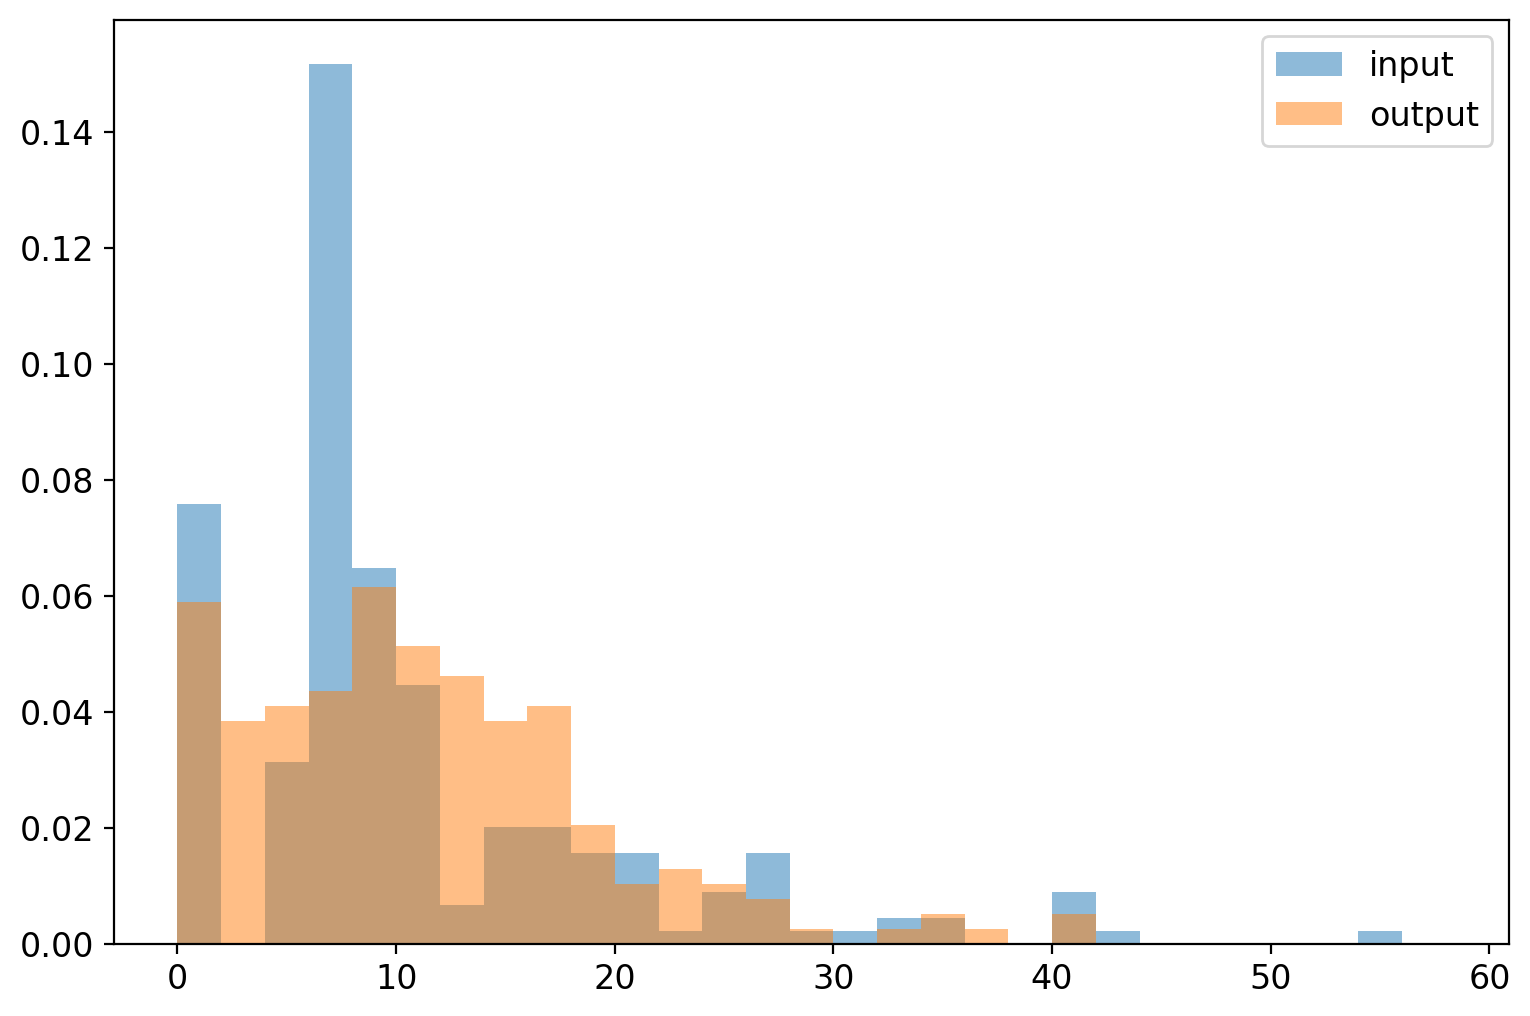

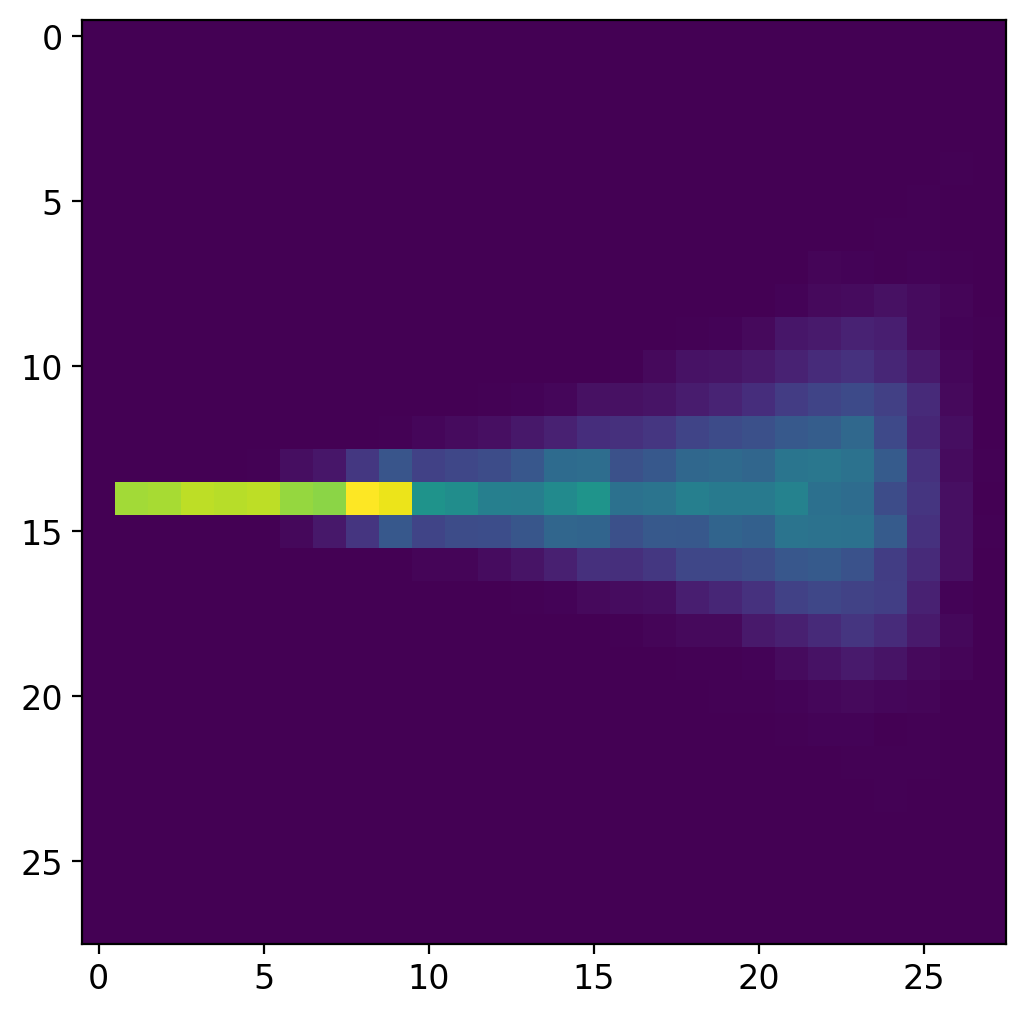

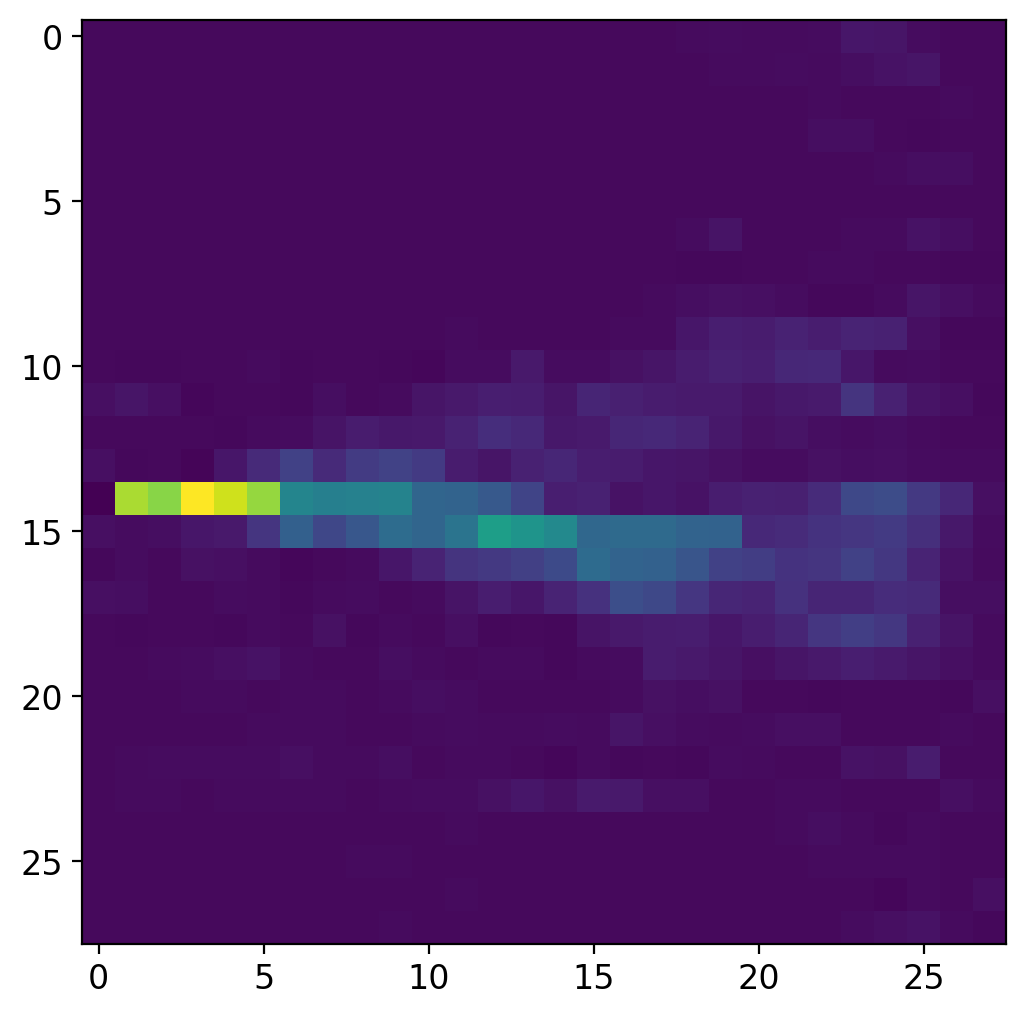

In [27]:
def plotCondVAEImageOutputs(iE,iLatentDim,iDataSet,iCVAE):
    testlatent=torch.randn(iDataSet.shape[0],iLatentDim)
    testlatent=testlatent.reshape(iDataSet.shape[0],iLatentDim)
    beamenergy = torch.ones(iDataSet.shape[0],1)*iE
    rec_img  = iCVAE.decoder(testlatent,beamenergy)
    rec_img  = rec_img.detach().numpy()

    xbin = np.arange(-0.5,27.5, 1)
    ybin = np.arange(-3.5, 3.5, 0.25)
    plt.plot(xbin,np.mean(np.sum(iDataSet,axis=2),axis=0).flatten(),drawstyle='steps-mid',label='MC')
    plt.plot(xbin,np.mean(np.sum(rec_img,axis=2),axis=0).flatten(),drawstyle='steps-mid',label='NN')
    plt.xlabel('x-distance(cm)')
    plt.legend()
    plt.show()


    plt.plot(ybin,np.mean(np.sum(iDataSet,axis=3),axis=0).flatten(),drawstyle='steps-mid',label='MC')
    plt.plot(ybin,np.mean(np.sum(rec_img,axis=3),axis=0).flatten(),drawstyle='steps-mid',label='NN')
    plt.xlabel('y-distance(cm)')
    plt.show()

    xrange=np.arange(0,20,1)
    plt.hist(np.sum(iDataSet,axis=2)[0:10].flatten(),label='input',alpha=0.5,bins=xrange,density=True)
    plt.hist(np.sum(rec_img ,axis=2)[0:10].flatten(),label='output',alpha=0.5,bins=xrange,density=True)
    plt.legend()
    plt.show()

    xrange=np.arange(0,60,2)
    plt.hist(np.sum(iDataSet,axis=2)[12:20].flatten(),label='input',alpha=0.5,bins=xrange,density=True)
    plt.hist(np.sum(rec_img ,axis=2)[12:20].flatten(),label='output',alpha=0.5,bins=xrange,density=True)
    plt.legend()
    plt.show()

    dimage150_avg = np.mean(iDataSet,axis=0)
    plt.imshow(dimage150_avg[0])
    plt.show()

    rec_img_avg = np.mean(rec_img,axis=0)
    plt.imshow(rec_img_avg[0])
    plt.show()

#plotCondVAEImageOutputs(1.50,d,dimage150,cvae_proton_image)
#plotCondVAEImageOutputs(2.25,d,dimage200,cvae_proton_image)
plotCondVAEImageOutputs(3.00,d,dimage300,cvae_proton_image)
#torch.save(cvae_proton_image.state_dict(), 'cvae_test.pt')

In [28]:
import time

def generate(iLatentDim,iN,iCVAE,iE):
    testlatent=torch.randn(iN,iLatentDim)
    testlatent=testlatent.reshape(iN,iLatentDim)
    beamenergy = torch.ones(testlatent.shape[0],1)*iE
    rec_img  = iCVAE.decoder(testlatent,beamenergy)
    rec_img  = rec_img.detach().numpy()
    return rec_img

N=250
start=time.time()
generate(d,N,cvae_proton_image,1.5)
stop=time.time()
print("Time to generate 250 events:",(stop-start))
timeNN=(stop-start)

start=time.time()
simNYParallelSample(ie=150,im=mproton,iN=N,idt=1e-10,iZ=8)
stop=time.time()
print("Time to generate 250 events:",(stop-start))
timeGen=(stop-start)

print("===> speed up",timeGen/timeNN)

Time to generate 250 events: 0.01318812370300293
Scanning: 150
Time to generate 250 events: 16.91485595703125
===> speed up 1282.5824459911416


## Normalizing Flows :  more Expressive model

Now, if we really want to make our model extra expressive, we can consider adding normalizing flow layers. The flow would replace the existing Gaussian sample with a Gaussian sample in a transformed space. The iterative transforming in a normalizing flow can make the latent space progressively more and more expressive.

We will skip this for now, mostly because its nto clear we can train this fast enough for this lecture, and it could use some tweaking before its ready to be in the notes.

<a name='exercises_22_4'></a>     

| [Top](#section_22_0) | [Restart Section](#section_22_4) | [Next Section](#section_22_5) |


<a name='section_20_5'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.5 Bootstrapping </h2>  


| [Top](#section_20_0) | [Previous Section](#section_20_4) | [Exercises](#exercises_20_5) | [Next Section](#section_20_6) |

When we look at the above generation, the full image will a full energy profile can yield a shape. We can run a lot of generation, and treat this shape as a simulation. However, when we quote uncertainties on this shape, we can treat this as a Poisson uncertainty on each bin, since there bins are correlated.

To get the full uncertainty of this setup, we really need to go a bit further and deploy techniques that can account for the fact that the whole shape is correlated. There are really two ways to do this:

 * Write down all the uncertainties going into how you generate your simulation and vary them
   * For above, this means many to name a few
     * uncertainty in the beam profile,
     * uncertainty in the enrgy distribution,
     * uncertainty in the detector shape
     * uncertainty in the training
     * ...
   * The uncertainty in the training can be very hard to estimate
     * Sometimes this means multiple traings
   * We can often miss uncertainties
     * Or we just ignore them (eg Laudau unc.)
 * Reverse engineer the uncertainty from the ultimate variations in the data
   * Sometimes its just too complicated to get the uncertainty from inputs
   * We can analyze the uncertainty by removing events and looking at the prediction variations
     * This involves some assumptions about uncertainty
   * Bootstrapping

Now before we go ahead and try to solve the problems of our simulation, lets go ahead and do some very basic boostrap examples. Let's sample a uniform distribution from 100 to 300.

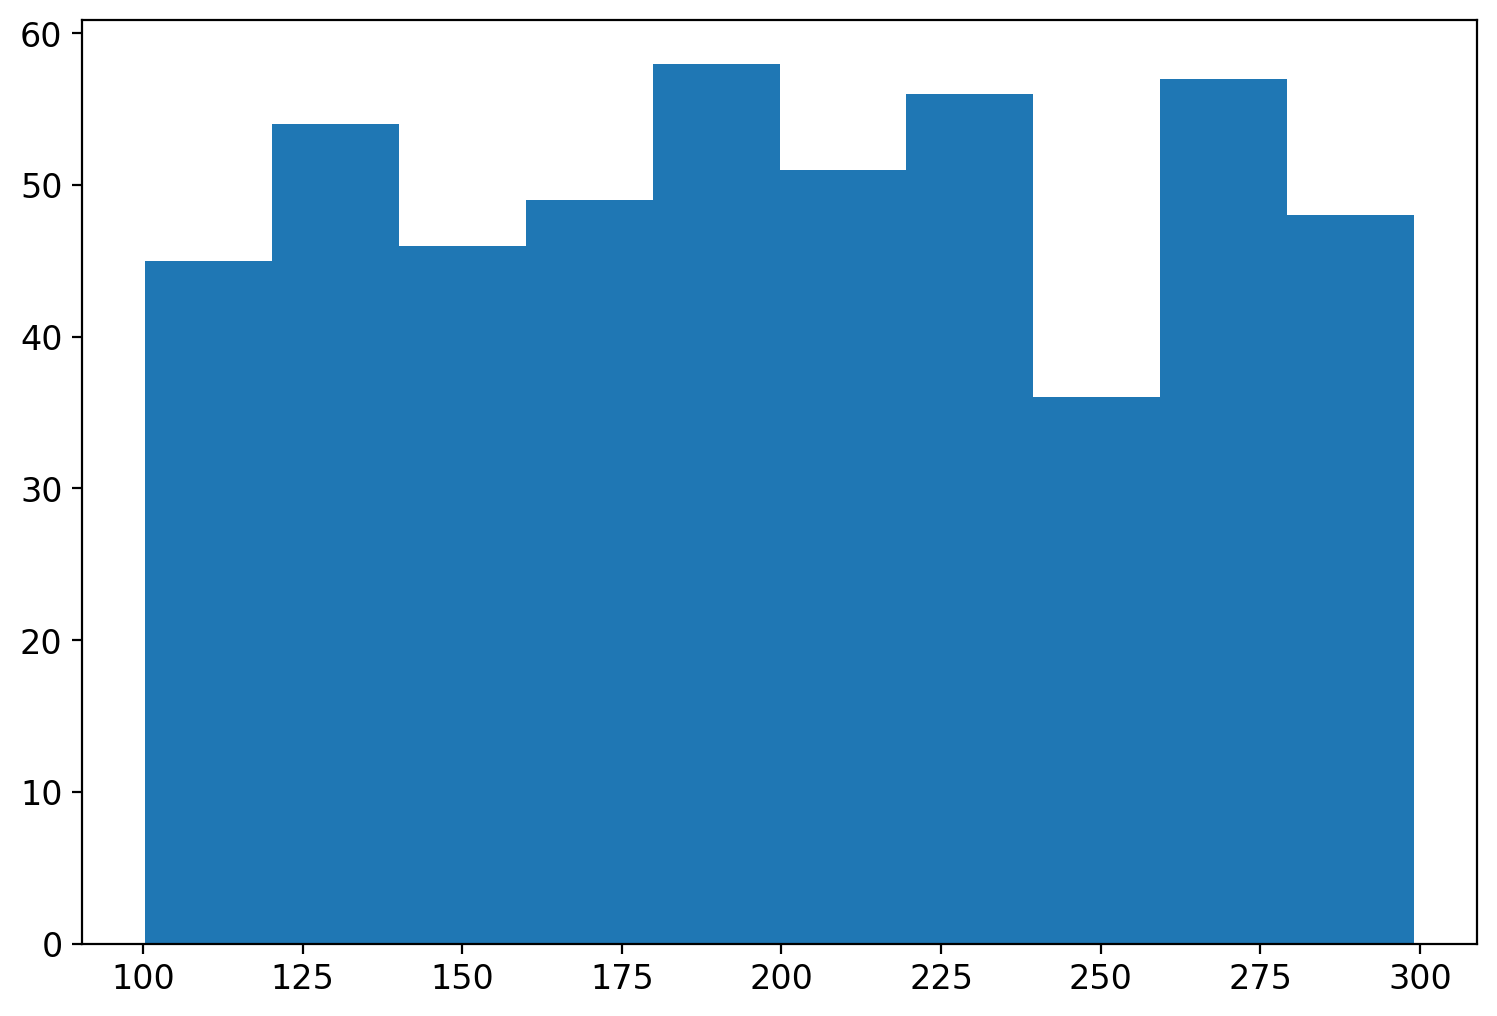

Mean: 200.08770783517346
RMS: 56.58058658033926


In [54]:
#np.random.seed(0)
samples = np.random.uniform(100,300,500)
plt.hist(samples)
plt.show()

print("Mean:",np.mean(samples))
print("RMS:",np.std(samples))

Ok, so my first question for you is, what is the analytic mean and standard deviation of this sample?


This is a just a flat distribution, so we can immediately write the mean and standard deviation of a [flat distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution) raging from $a$ to $b$ as

$$
\bar{x} = \frac{1}{(b-a)}\\
\sigma_{x} = \frac{b-a}{\sqrt{12}}
$$

Secondly, we can ask ourselves what the uncertainty on the mean and standard variance is for $N$ measurements. If you recall early on in this, class this is computed by computing the variance in the mean over a sample and variance of a standard deviation over the sample for $N$ samples. Analytically, we can write this as:

$$
\sigma_{\bar{x}} = \frac{\sigma_{x}}{\sqrt{N}} \\
\sigma_{\sigma_{x}} = \frac{\sigma_{x}}{\sqrt{2N}}
$$

Now, what if we want to compute the uncertainty in the kurtosis or perhaps the ratio of the kurotsis to the mean distribution, or something else, how would we compute that?

Well....we can do it analytically, but lets try another approach

Lets resample our existing distribution with a random poisson sampler, and make a toy experiment. When can then proceed to make many toys and then look at the distribution of our means and standard deviations, and see if they agree with our analytical forms.

To do that, we are going to use the random choice, which is our Poisson sampler on an array. Let's take a look at how it works

[0 1 2 3 4 5 6 7 8 9]
[9 6 7 4 5]
[5 9 4 2 8 7 1 8 1 3]
[8 8 6 5 7 2 0 7 2 3 7 4 8 0 3 4 5 8 6 3]


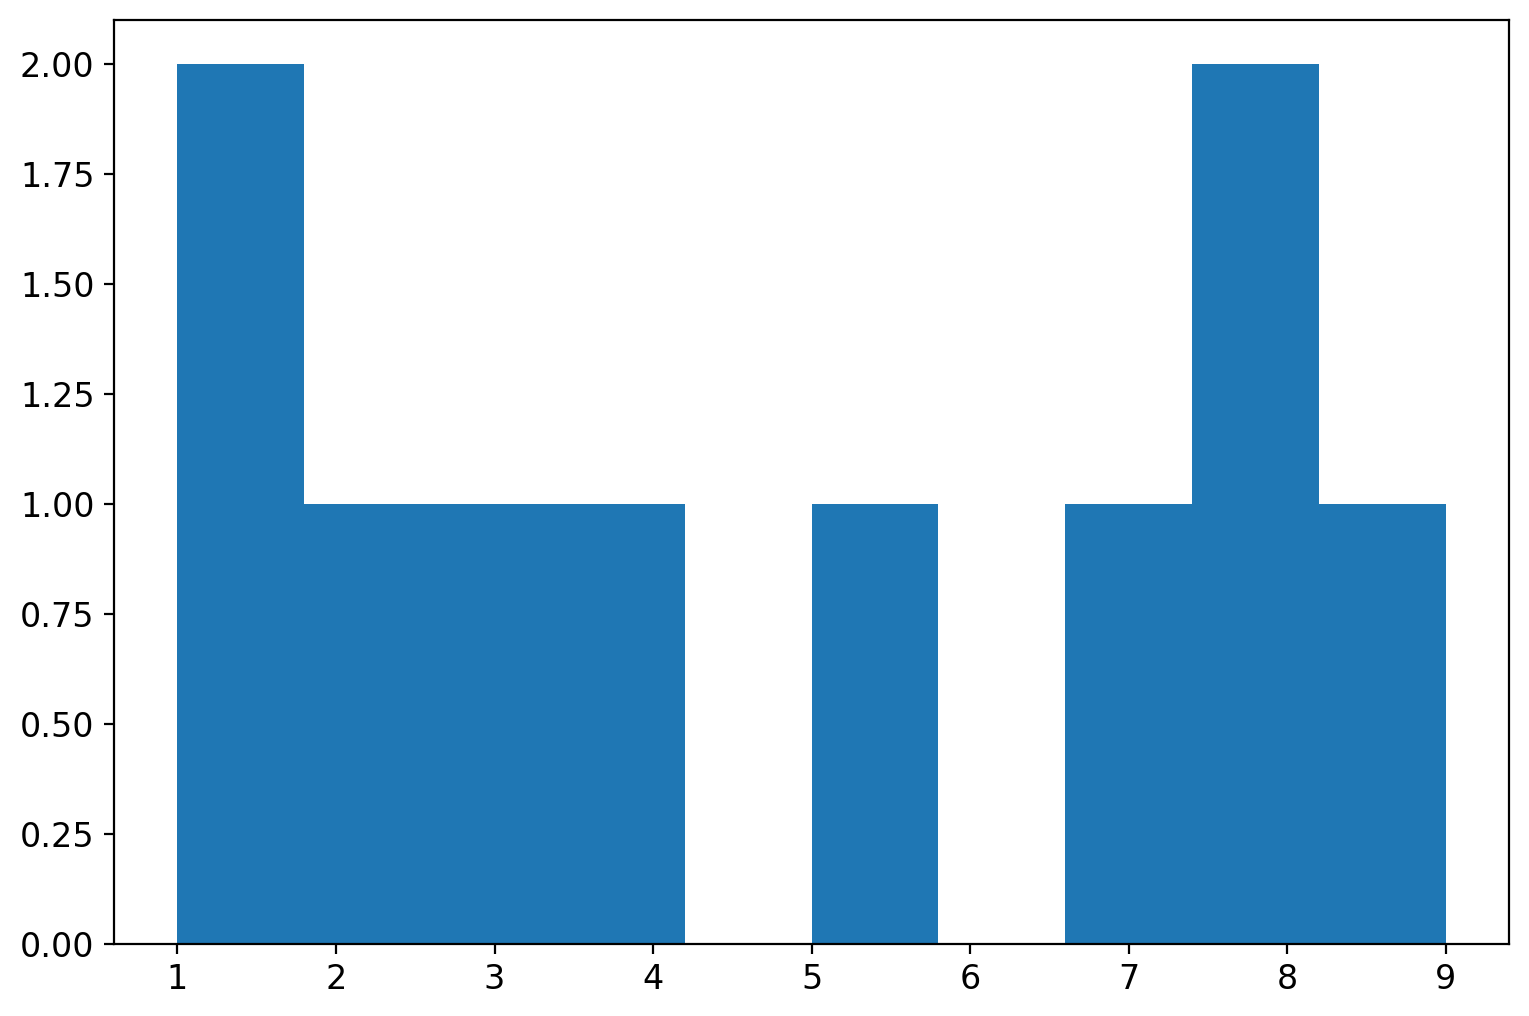

In [53]:
arr=np.arange(10)
print(arr)
test=np.random.choice(arr,size=5)
print(test)
test=np.random.choice(arr,size=10)
print(test)
plt.hist(test)
test=np.random.choice(arr,size=20)
print(test)

Notice, we will have dupblicates. That happens with our poisson sampler. This is really kind of the core idea. Is that if we bias our dataset by Poisson sampling it, we get a notion for how much our dataset will vary if we just choose differently from our base dataset.

Let's go ahead and compute the mean and RMS of our data.

Mean: 200.40166466534663
RMS: 56.815085508735386


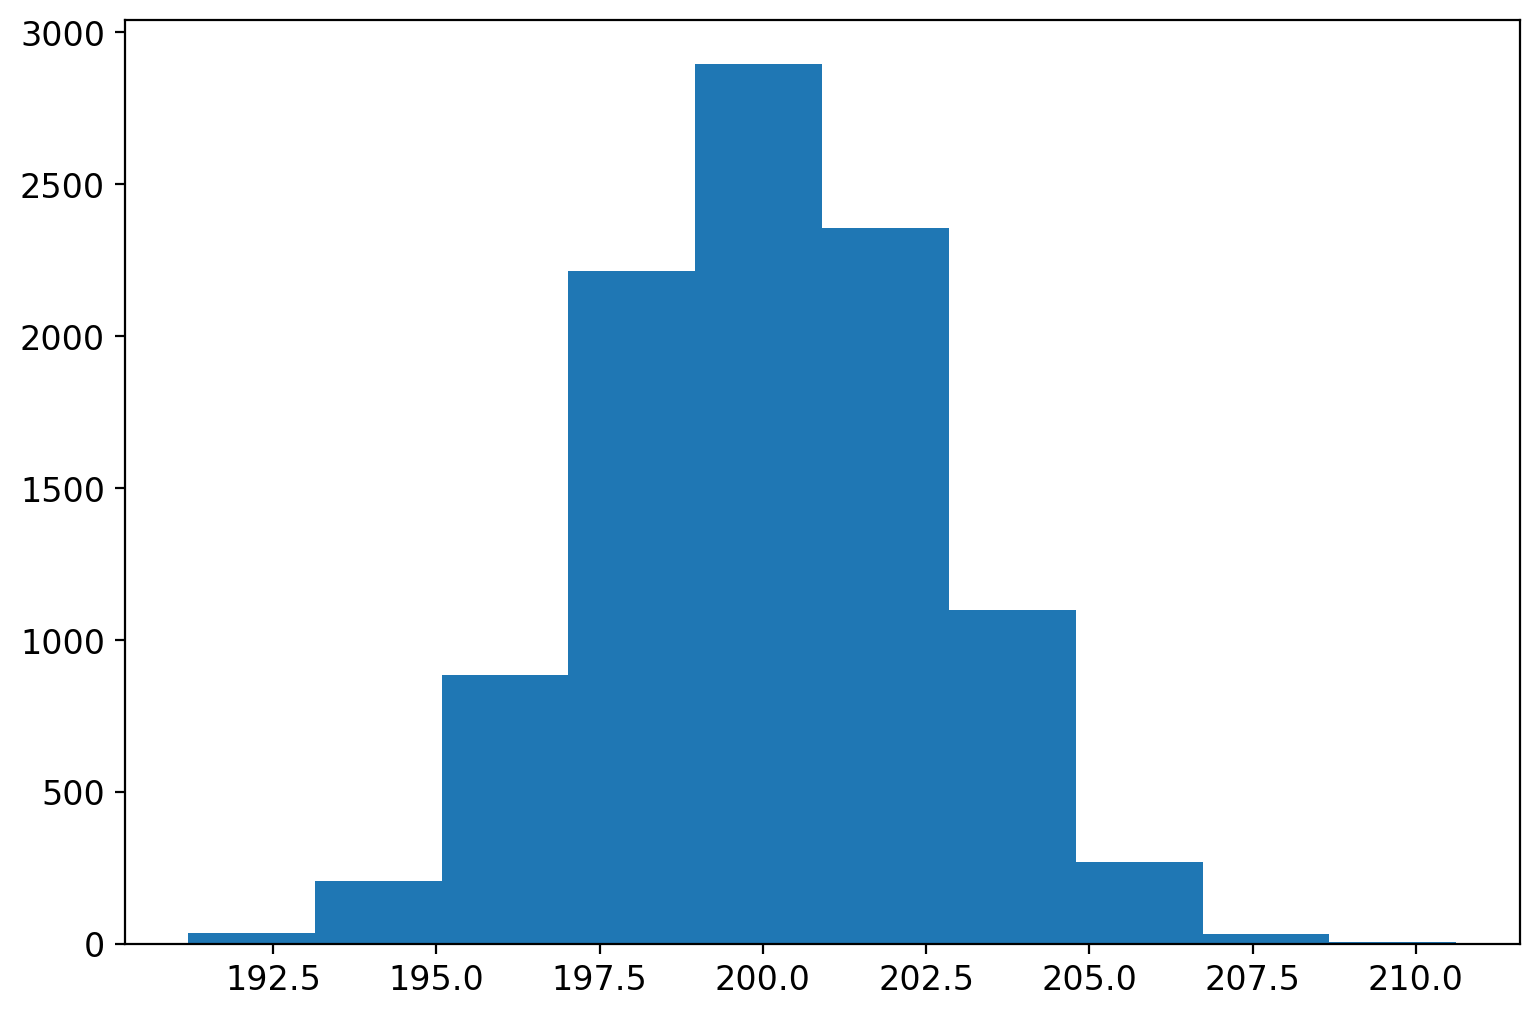

Mean of samples: 200.08860253310704
Std of mean of samples: 2.545796074574372


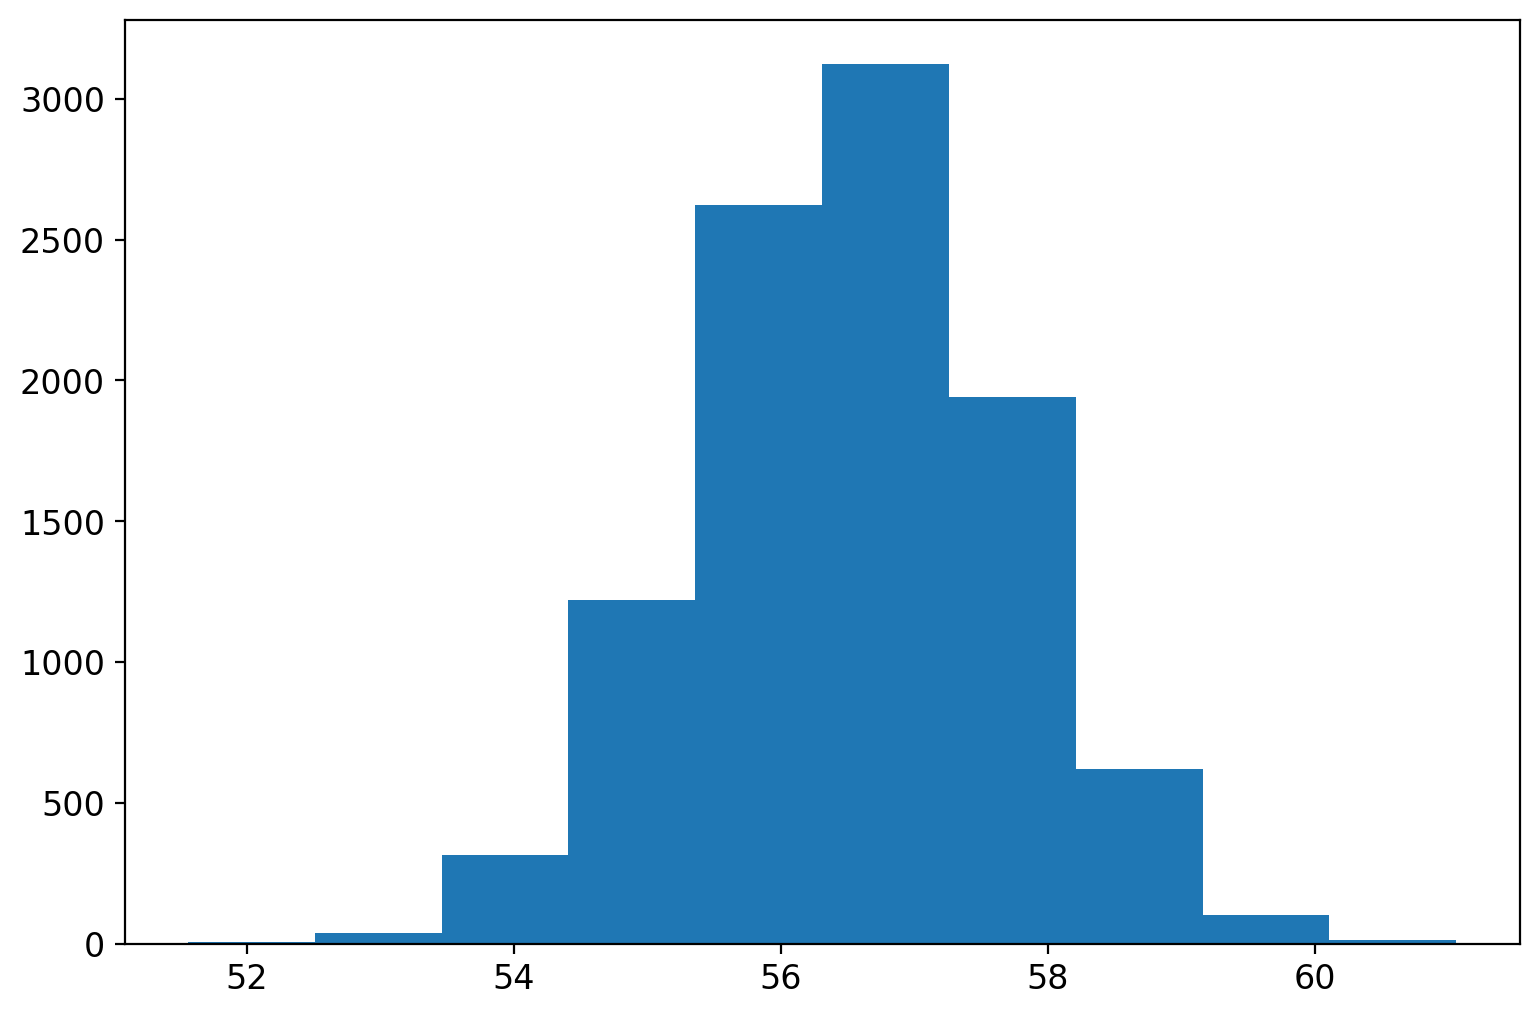

Mean of samples: 56.53081755747886
Std of mean of samples: 1.1715825969526106


In [55]:
#np.random.seed(0)

sample=np.random.choice(samples, size = 500)
print("Mean:",np.mean(sample))
print("RMS:",np.std(sample))

boot_means = []
boot_stds  = []
for _ in range(10000):
    boot_sample = np.random.choice(samples,replace = True, size = 500) # take a random sample each iteration
    boot_means.append(np.mean(boot_sample)) # append the mean to boot_means
    boot_stds.append(np.std(boot_sample)) # append the mean to boot_means
boot_means_np = np.array(boot_means) # transform it into a numpy array for calculation
boot_stds_np = np.array(boot_stds)

plt.hist(boot_means_np)
plt.show()

print("Mean of samples:",np.mean(boot_means_np))
print("Std of mean of samples:",np.std(boot_means_np))

plt.hist(boot_stds_np)
plt.show()

print("Mean of samples:",np.mean(boot_stds_np))
print("Std of mean of samples:",np.std(boot_stds_np))

Now lets compare this with the true values from analytic calculations, and see how well we do

In [56]:
analytic         = (300.+100.)/2.
analytic_std     = (300.-100.)/np.sqrt(12.)
analytic_err     = analytic_std/np.sqrt(500.)
analytic_std_err = analytic_std/np.sqrt(500.)/2. ## Note this 2 needs checking!
print("Mean of samples:",np.mean(boot_means_np),"+/-",np.std(boot_means_np)
      ,"\nAnalytic:",analytic,"+/-",analytic_err)

print("Std of samples:",np.mean(boot_stds_np),"+/-",np.std(boot_stds_np)
      ,"\nAnalytic:",analytic_std,"+/-",analytic_std_err)


Mean of samples: 200.08860253310704 +/- 2.545796074574372 
Analytic: 200.0 +/- 2.581988897471611
Std of samples: 56.53081755747886 +/- 1.1715825969526106 
Analytic: 57.73502691896258 +/- 1.2909944487358056


Now, interestingly, what if we did the same but just randomly sampled every time. This would really be the correct way to get the variance. However, we sometimes don't have the opportunity or the computing power to do this. Let's go ahead and take a look.

In [57]:
samp_means = []
samp_stds  = []
for _ in range(10000):
    samp_sample = np.random.uniform(100,300,500)
    samp_means.append(np.mean(samp_sample)) # append the mean to boot_means
    samp_stds.append(np.std(samp_sample)) # append the mean to boot_means
samp_means_np = np.array(samp_means) # transform it into a numpy array for calculation
samp_stds_np = np.array(samp_stds)

print("Mean of samples:",np.mean(samp_means_np),"+/-",np.std(samp_means_np)
      ,"\nBoot:",np.mean(boot_means_np),"+/-",np.std(boot_means_np))

print("Std of samples:",np.mean(samp_stds_np),"+/-",np.std(samp_stds_np)
      ,"\nBoot:",np.mean(boot_stds_np),"+/-",np.std(boot_stds_np))


Mean of samples: 199.99410216783514 +/- 2.556464208743879 
Boot: 200.08860253310704 +/- 2.545796074574372
Std of samples: 57.67447910409675 +/- 1.152072629308815 
Boot: 56.53081755747886 +/- 1.1715825969526106


While its not perfect, it does give us the notion of variability that we have. Importantly, for the bottom one we sampled a uniform distribution millions of times, whereas for the boostrap we only sampled the uniform distribution once. This will be critical once we go and try to assess the uncertainty on derived quantities.

Ok, now that we have done this by hand, lets use the `scipy.stats` tool to make our boostrap life much easier.

In [58]:
from scipy.stats import bootstrap
import numpy as np

test_samples = (samples,)
bootstrap_ci = bootstrap(test_samples, np.std, confidence_level=0.68,random_state=1, method='percentile')
print(bootstrap_ci.confidence_interval,(bootstrap_ci.confidence_interval.high-bootstrap_ci.confidence_interval.low)/2.)
print(bootstrap_ci.standard_error)

ConfidenceInterval(low=55.349226706125016, high=57.664964240810114) 1.1578687673425492
1.1625544183968848


Now the big gain from this approach is that we can start to compute really complicated things that we would not be able to do without sampling events.

For instance, let's consider a function that is not necessarily differentiable, and see if we can compute the uncertainty on the mean, and corrleation between the outputs

(500, 10)


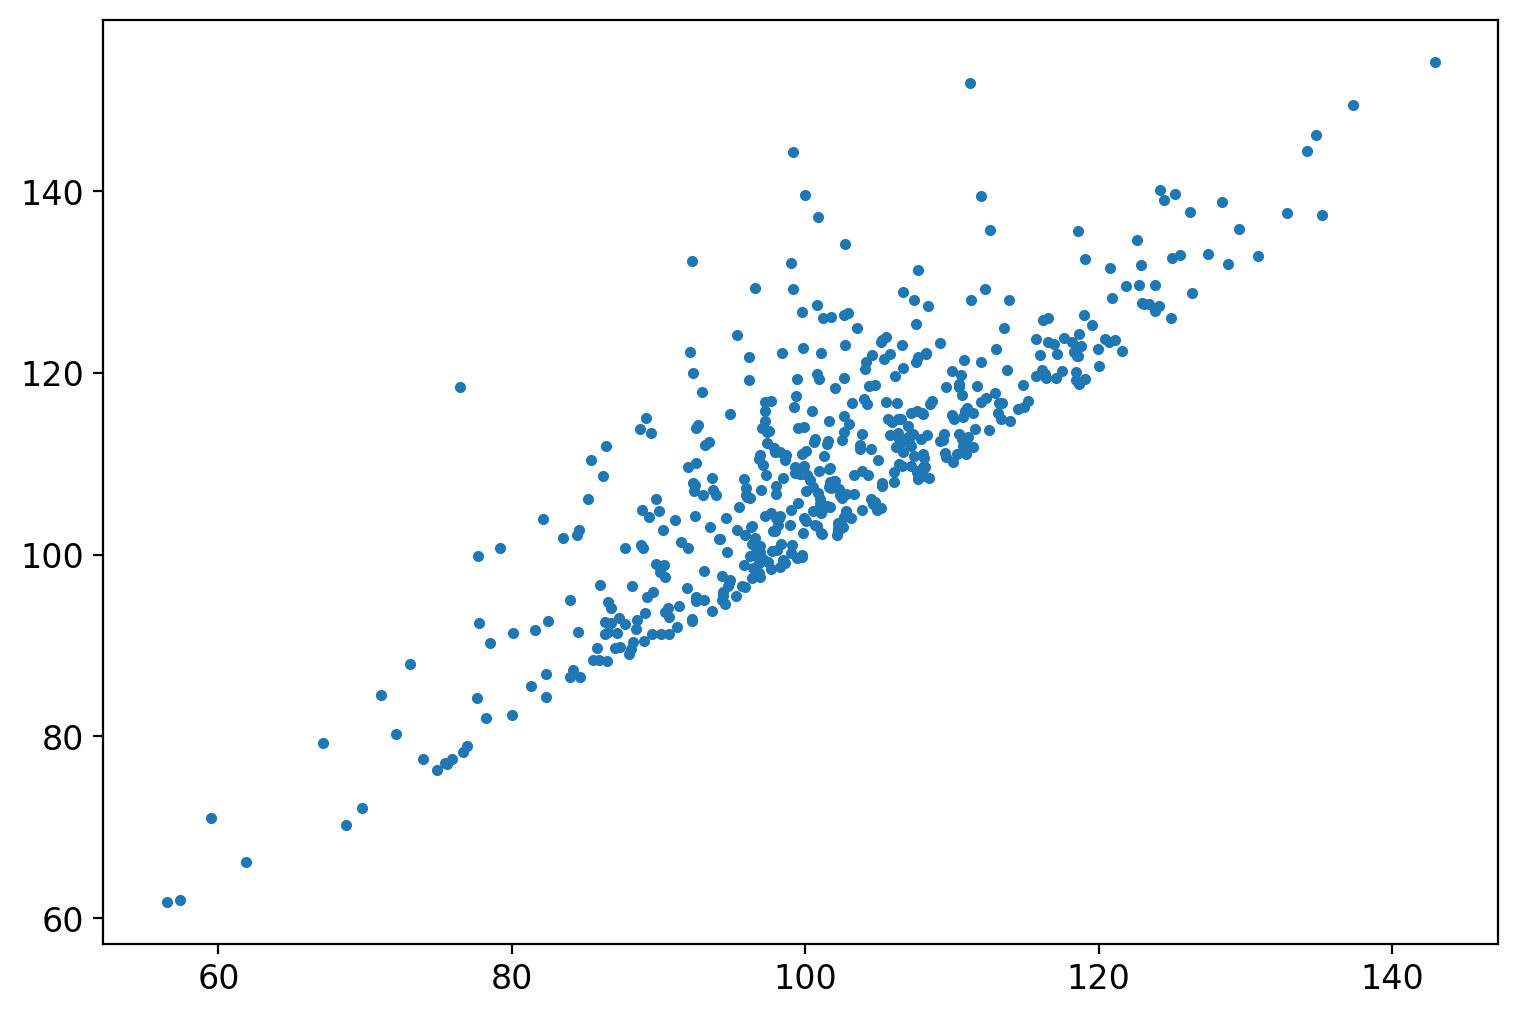

correlation: [[1.         0.83433051]
 [0.83433051 1.        ]]


(array([  4.,   9.,  16.,  60., 126., 151.,  92.,  28.,  11.,   3.]),
 array([118.30523752, 136.19470397, 154.08417042, 171.97363687,
        189.86310332, 207.75256977, 225.64203622, 243.53150267,
        261.42096912, 279.31043557, 297.19990202]),
 <BarContainer object of 10 artists>)

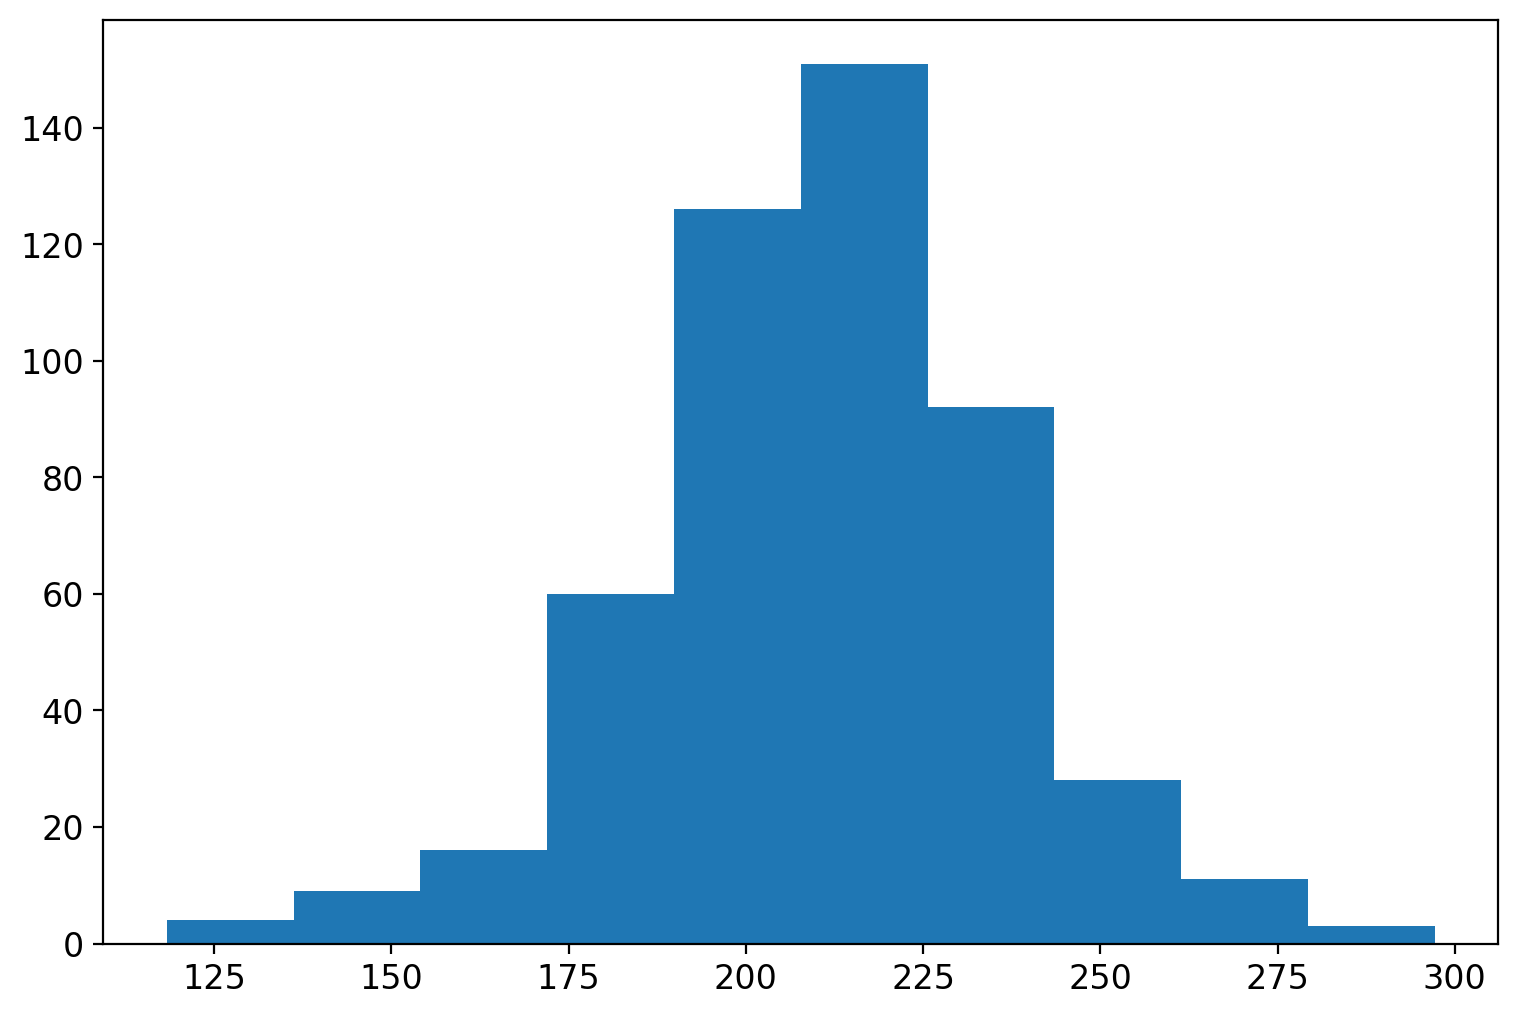

In [59]:
def func(x):
    x_sort = np.sort(x,axis=1)
    print(x_sort.shape)
    return (np.vstack((x_sort[:,0] + x_sort[:,-1],x_sort[:,1] + x_sort[:,-1] ))).T

rand_data = np.random.uniform(0,100,5000).reshape(500,10)
out_data = func(rand_data)
plt.plot(out_data[:,0],out_data[:,1],".")
plt.show()
print("correlation:",np.corrcoef(out_data[:,0],out_data[:,1]))

plt.hist(out_data[:,0]+out_data[:,1])

Ok, so the above is some complicated mess. Let's bootstrap this guy, and see how much things vary. Since, we

Sum of Boot: 211.20684981480517 +/- 1.1835588012894112 --- 0.6499336117093886
Corr of samples: 0.8346870156081033 +/- 0.019170289268034612
(1000,)


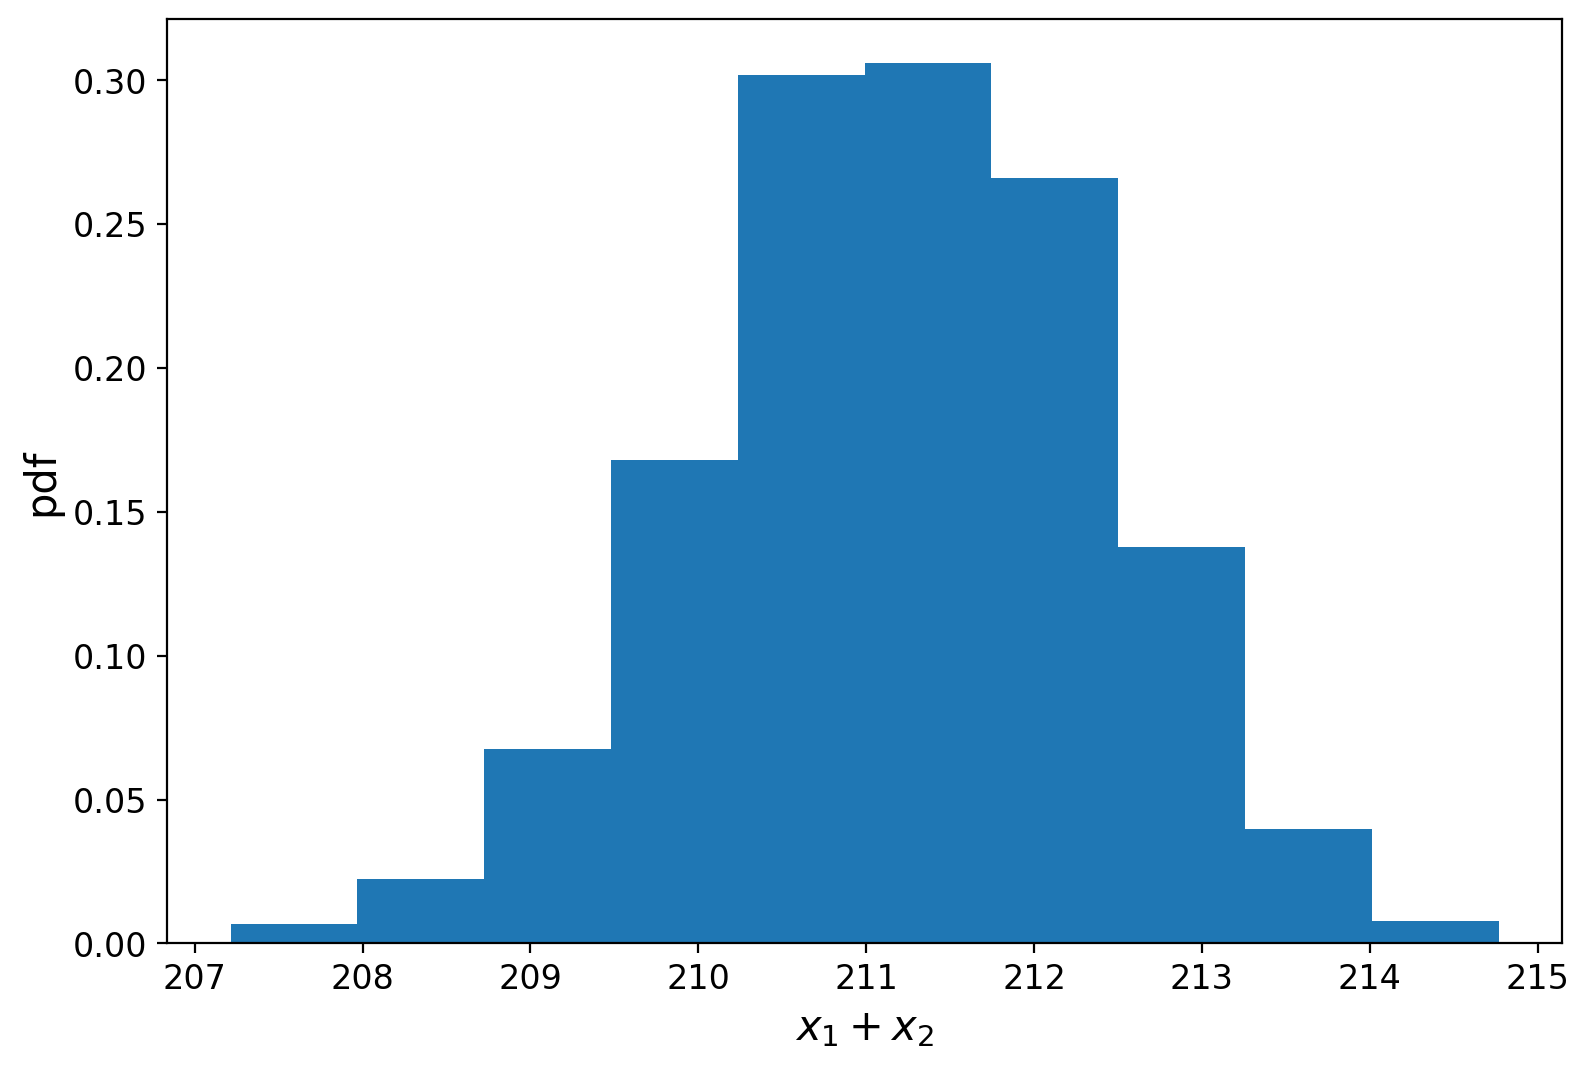

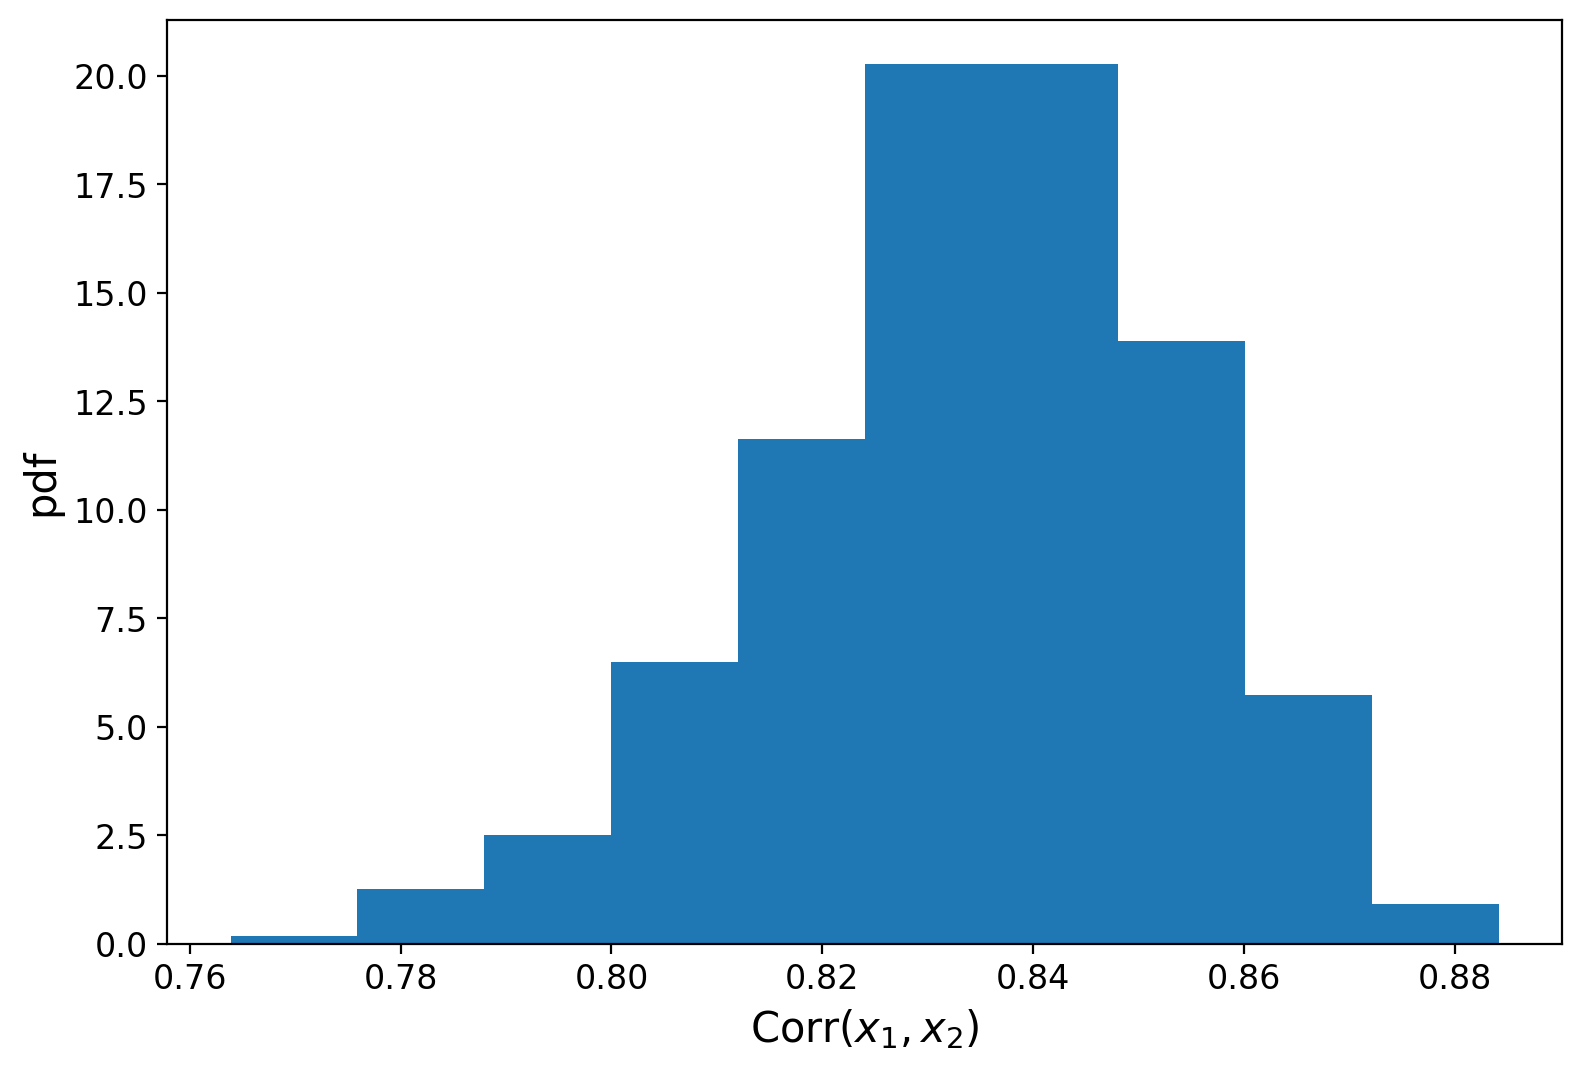

In [61]:
boot_sum   = []
boot_corr  = []
for _ in range(1000):
    #boot_sample = np.random.choice(out_data,replace = True, size = 500) # take a random sample each iteration
    boot_sample = out_data[np.random.choice(out_data.shape[0], 500, replace=True)]
    boot_sum.append(np.mean(boot_sample[:,0]+boot_sample[:,1]))
    boot_corr.append(np.corrcoef(boot_sample[:,0],boot_sample[:,1])[1,0])
boot_sum_np = np.array(boot_sum) # transform it into a numpy array for calculation
boot_corr_np = np.array(boot_corr)
print("Sum of Boot:",np.mean(boot_sum_np),"+/-",np.std(boot_sum_np),"---",np.sqrt(np.mean(boot_sum_np)/500))
print("Corr of samples:",np.mean(boot_corr_np),"+/-",np.std(boot_corr_np))
print(boot_sum_np.shape)

plt.hist(boot_sum_np,density=True)
plt.xlabel("$x_{1}+x_{2}$")
plt.ylabel("pdf")
plt.show()

plt.hist(boot_corr_np,density=True)
plt.xlabel("Corr($x_{1},x_{2}$)")
plt.ylabel("pdf")
plt.show()

Now there is one other approach to obtaining uncertainty from a fixed dataset. This approach is known as the delete-d jackknikfe. In the delete-d jackknife our strategy is to remove a subset of events and recompute the observables. We can then repeat this strategy many times by removing a few events and recomputing everything. The "Delete-d" refers to d as the removal of an event. This is sometimes even done as the delete-1 jackknife.

Unlike the bootstrap where we resample many times and we find that standard deviation of the bootstrap ($\sigma_{\rm bootstrap}$) approximates the standard error:

$\sigma_{\rm bootstrap} \approx \sigma_{\rm error}$

With the delete-d jackknife we have that we have to correct for the fact that the we are removing a very small number of elements from the dataset, and so the variance over removing just d elements from the dataset needs to be corrected and so we have: 

$\sigma_{\rm jackknife} \approx \frac{_n{C}_{d}}{\frac{n}{d}}\sigma_{\rm error}$

<a name='exercises_22_5'></a>     

| [Top](#section_22_0) | [Restart Section](#section_22_5) | [Next Section](#section_22_6) |


### <span style="border:3px; border-style:solid; padding: 0.15em; border-color: #90409C; color: #90409C;">Exercise 20.5.1</span>

In the following exercise, we will perform a t-test to see if two Gaussian distributions with $\sigma=1$ and mean $5$ or $7$ are statistically similar to each other. We will then boostrap this t-test to compute the uncertainty on our p-value confidence of tehse being different. 

<br>

In [197]:
import numpy as np
from scipy import stats

# Set random seed for reproducibility
np.random.seed(0)

# Generate two random samples from Gaussian distributions
sample1 = np.random.normal(loc=5.5, scale=1, size=30)  # Mean=5, Std=2
sample2 = np.random.normal(loc=7, scale=1, size=30)  # Mean=7, Std=2

# Perform two-sample t-test
t_statistic, p_value = stats.ttest_ind(sample1, sample2)

# Print results
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The means of the two samples are significantly different.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the means of the two samples.")


T-statistic: -2.9389770379445226
P-value: 0.004720335438244337
Reject the null hypothesis: The means of the two samples are significantly different.


In [198]:
import numpy as np
from scipy import stats

# Set random seed for reproducibility
np.random.seed(0)

# Generate two random samples from Gaussian distributions
sample1 = np.random.normal(loc=5.5, scale=1, size=30)  # Mean=5, Std=2
sample2 = np.random.normal(loc=7, scale=1, size=30)  # Mean=7, Std=2

# Function to compute t-statistic from two samples
def compute_t_statistic(sample1, sample2):
    mean_diff = np.mean(sample1) - np.mean(sample2)
    pooled_var = ((len(sample1) - 1) * np.var(sample1, ddof=1) + (len(sample2) - 1) * np.var(sample2, ddof=1)) / (len(sample1) + len(sample2) - 2)
    pooled_std = np.sqrt(pooled_var)
    t_stat = mean_diff / (pooled_std * np.sqrt(1 / len(sample1) + 1 / len(sample2)))
    return t_stat

# Bootstrap resampling
num_bootstraps = 10000
t_statistics = []

for _ in range(num_bootstraps):
    # Resample with replacement from the original samples
    resampled1 = np.random.choice(sample1, size=len(sample1), replace=True)
    resampled2 = np.random.choice(sample2, size=len(sample2), replace=True)

    # Compute t-statistic for the resampled data
    t_stat = compute_t_statistic(resampled1, resampled2)
    t_statistics.append(t_stat)

# Calculate p-value
observed_t_stat = compute_t_statistic(sample1, sample2)
#p_value = np.mean(np.abs(t_statistics) >= np.abs(observed_t_stat))
mean_tstat = np.mean(t_statistics)
std_tstat  = np.std(t_statistics)
p_value    = stats.t.cdf(mean_tstat+2*std_tstat, len(sample1))

# Print results
print(f"Observed T-statistic: {observed_t_stat}")
print(f"Mean T-stat {mean_tstat}")
print(f"Std T-stat {std_tstat}")
print(f"Std p-value with 95% confidence {p_value}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The means of the two samples are significantly different.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the means of the two samples.")


Observed T-statistic: -2.9389770379445226
Mean T-stat -3.004629321125194
Std T-stat 0.9768153714635951
Std p-value with 95% confidence 0.15082600748298375
Fail to reject the null hypothesis: There is no significant difference between the means of the two samples.


<a name='section_20_6'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.6 Bootstrapping For Neural Networks</h2>  

| [Top](#section_20_0) | [Previous Section](#section_20_5) | [Exercises](#exercises_20_6) |

Now that we have gone through the prospects of what it is like to use the bootstrap method, lets go ahead and see if we can use it to get the uncertainties of our generated sample of proton events. This is really where methods like boostrap can really help us.  In this section, we will take our simulated proton events and we wil extract uncertainties in the energy shape and profile of the simulation, once we have done that we can go ahead and see if we can do the same thing with our neural network output.

To do this, lets look at the profile along distance of our bins. To make it clear this is an issue, we can make a plot where we use the standard devation, and one where we use the standard deviation/$\sqrt{N}$. Neither of these seem very appropriate.

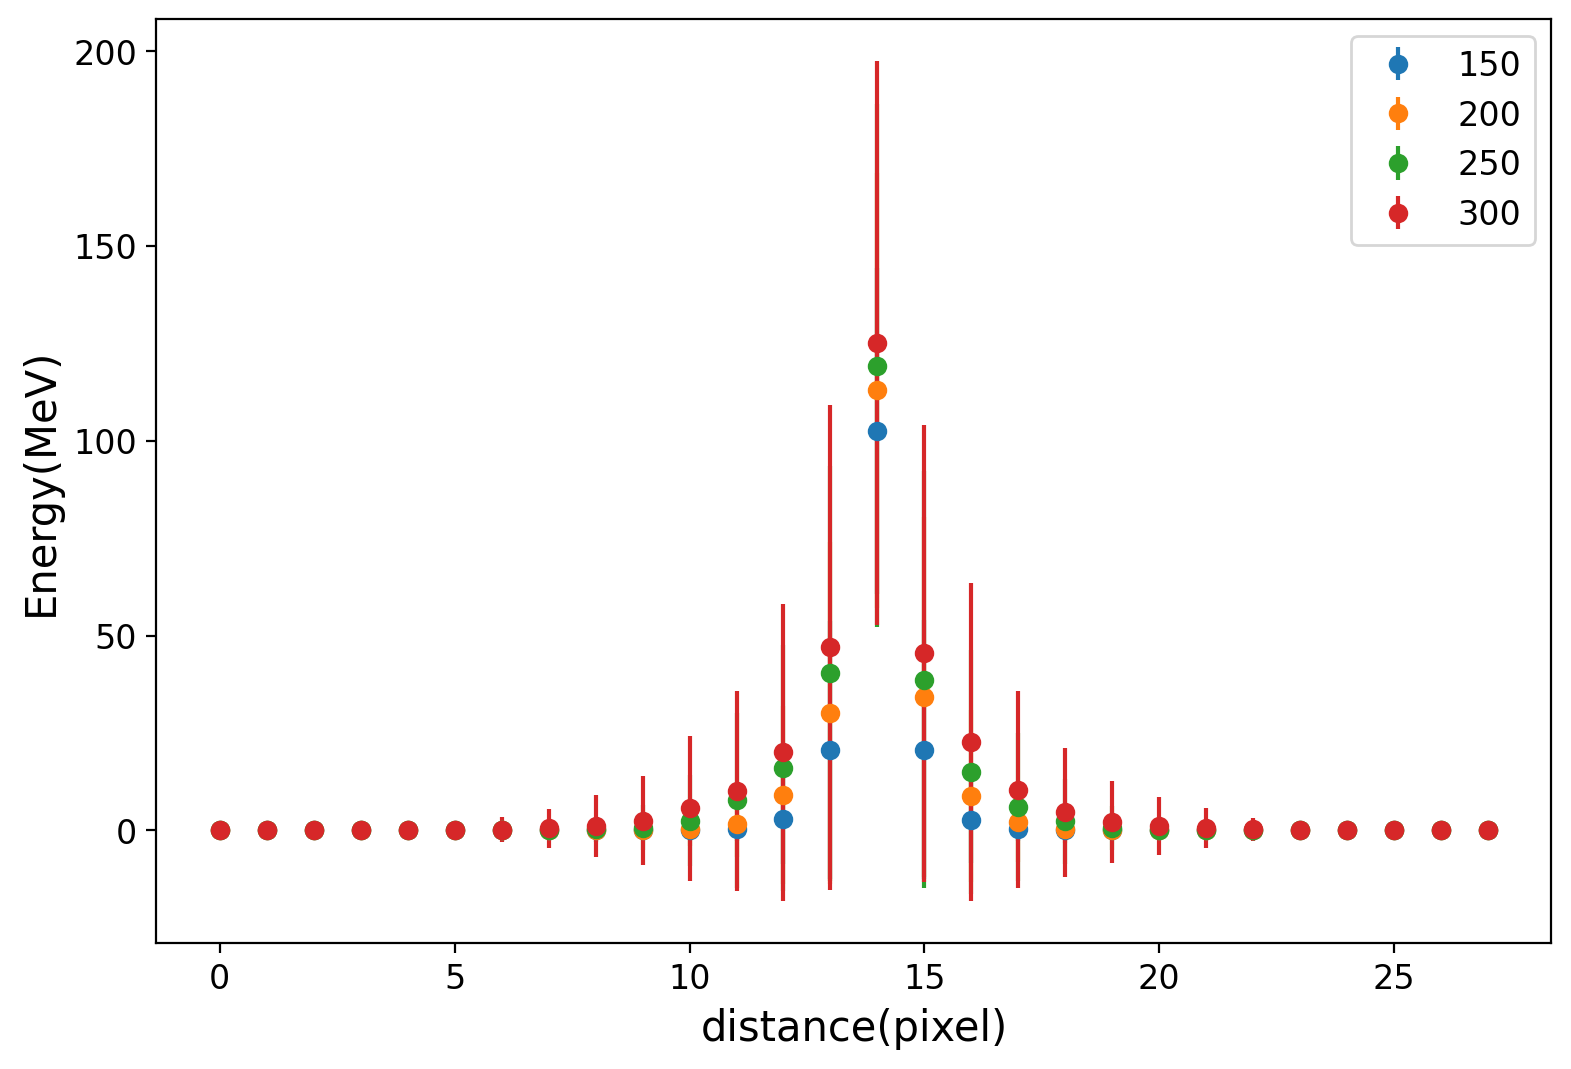

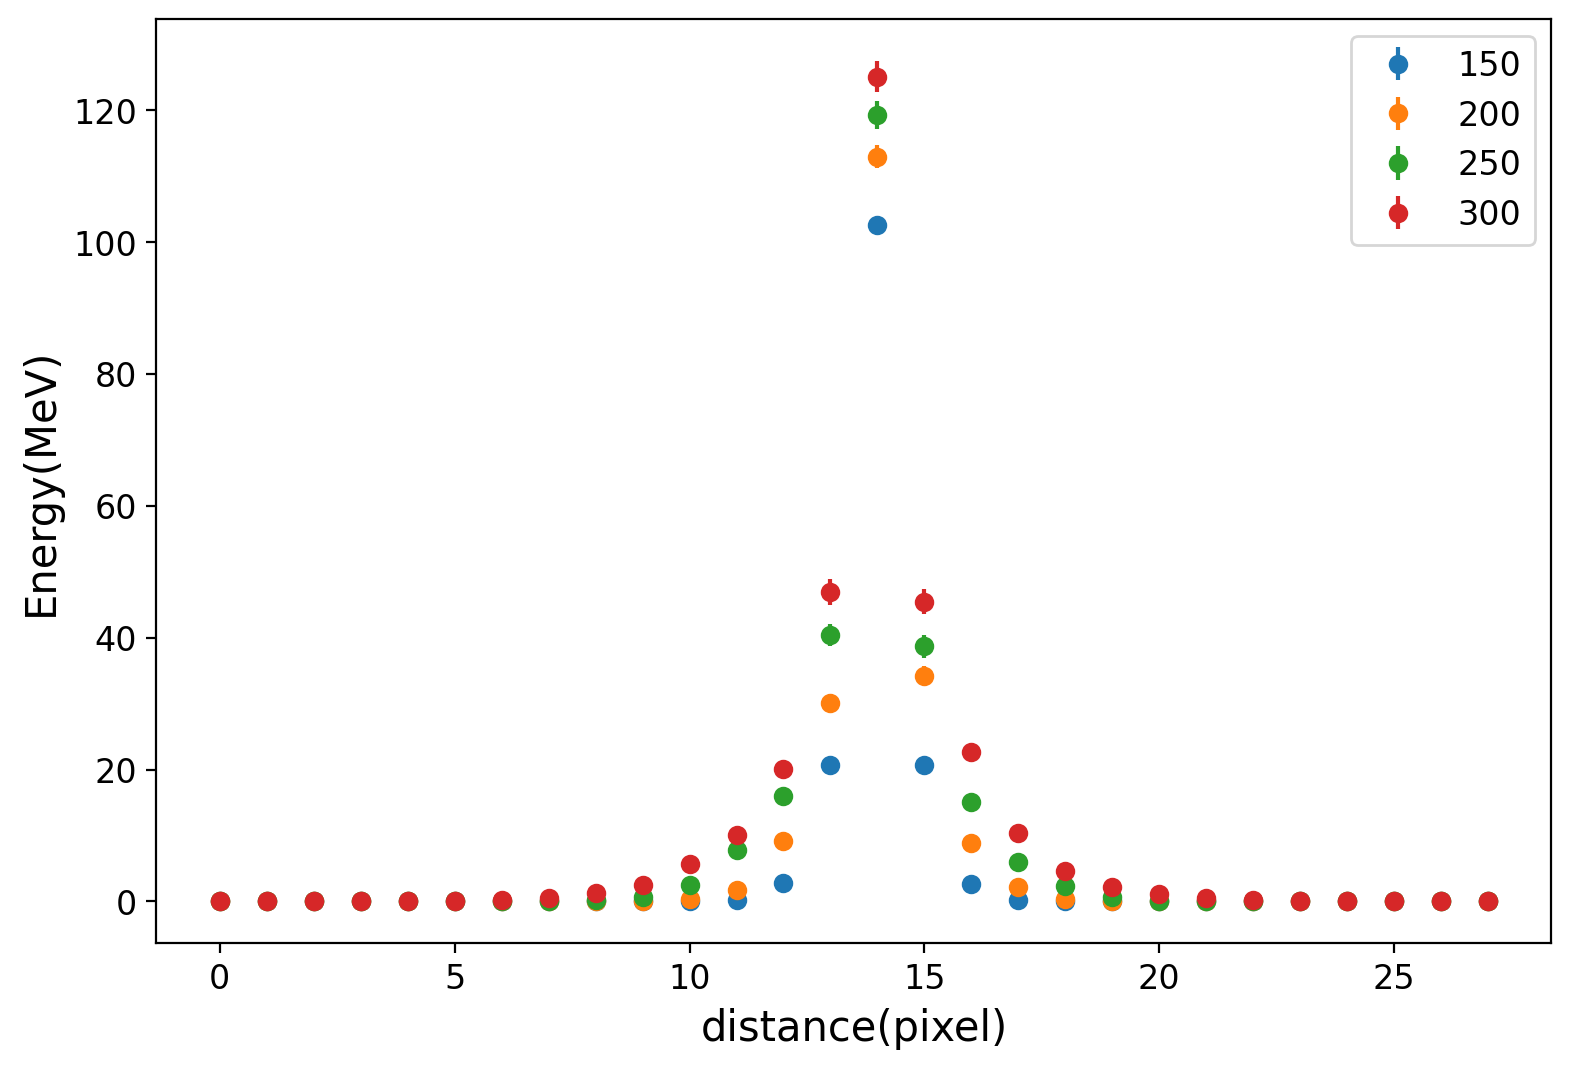

In [62]:
def makeDataset(iId,ixstep,iestep,iystep):
    print(ixstep.shape,iestep.shape,iystep.shape)
    outdata = np.hstack((ixstep,iystep,iestep))
    outdata = outdata.reshape(1000,3,ixstep.shape[1])
    return outdata

#bootdatastep150=makeDataset(-1,xstep150,estep150,ystep150)
#bootdatastep200=makeDataset(-1,xstep200,estep200,ystep200)
#bootdatastep250=makeDataset(-1,xstep250,estep250,ystep250)
#bootdatastep300=makeDataset(-1,xstep300,estep300,ystep300)

def profile(iInput):
    profile_out=np.sum(iInput,axis=3)
    return profile_out

out_profile150=profile(dimage150)
out_profile200=profile(dimage200)
out_profile250=profile(dimage250)
out_profile300=profile(dimage300)

test_150 = np.mean(out_profile150,axis=0)
test_200 = np.mean(out_profile200,axis=0)
test_250 = np.mean(out_profile250,axis=0)
test_300 = np.mean(out_profile300,axis=0)

test_150_std = np.std(out_profile150,axis=0)
test_200_std = np.std(out_profile200,axis=0)
test_250_std = np.std(out_profile250,axis=0)
test_300_std = np.std(out_profile300,axis=0)

test_150_stderr = np.std(out_profile150,axis=0)/np.sqrt(dimage150.shape[0])
test_200_stderr = np.std(out_profile200,axis=0)/np.sqrt(dimage200.shape[0])
test_250_stderr = np.std(out_profile250,axis=0)/np.sqrt(dimage250.shape[0])
test_300_stderr = np.std(out_profile300,axis=0)/np.sqrt(dimage300.shape[0])

plt.errorbar(np.arange(28),test_150.flatten(),yerr=test_150_std,fmt='o',label='150')
plt.errorbar(np.arange(28),test_200.flatten(),yerr=test_200_std,fmt='o',label='200')
plt.errorbar(np.arange(28),test_250.flatten(),yerr=test_250_std,fmt='o',label='250')
plt.errorbar(np.arange(28),test_300.flatten(),yerr=test_300_std,fmt='o',label='300')
plt.legend()
plt.xlabel('distance(pixel)')
plt.ylabel('Energy(MeV)')
plt.show()

plt.errorbar(np.arange(28),test_150.flatten(),yerr=test_150_stderr,fmt='o',label='150')
plt.errorbar(np.arange(28),test_200.flatten(),yerr=test_200_stderr,fmt='o',label='200')
plt.errorbar(np.arange(28),test_250.flatten(),yerr=test_250_stderr,fmt='o',label='250')
plt.errorbar(np.arange(28),test_300.flatten(),yerr=test_300_stderr,fmt='o',label='300')
plt.legend()
plt.xlabel('distance(pixel)')
plt.ylabel('Energy(MeV)')
plt.show()

Ok now that we have profile, lets go ahead and run the profile with a bootstrap.

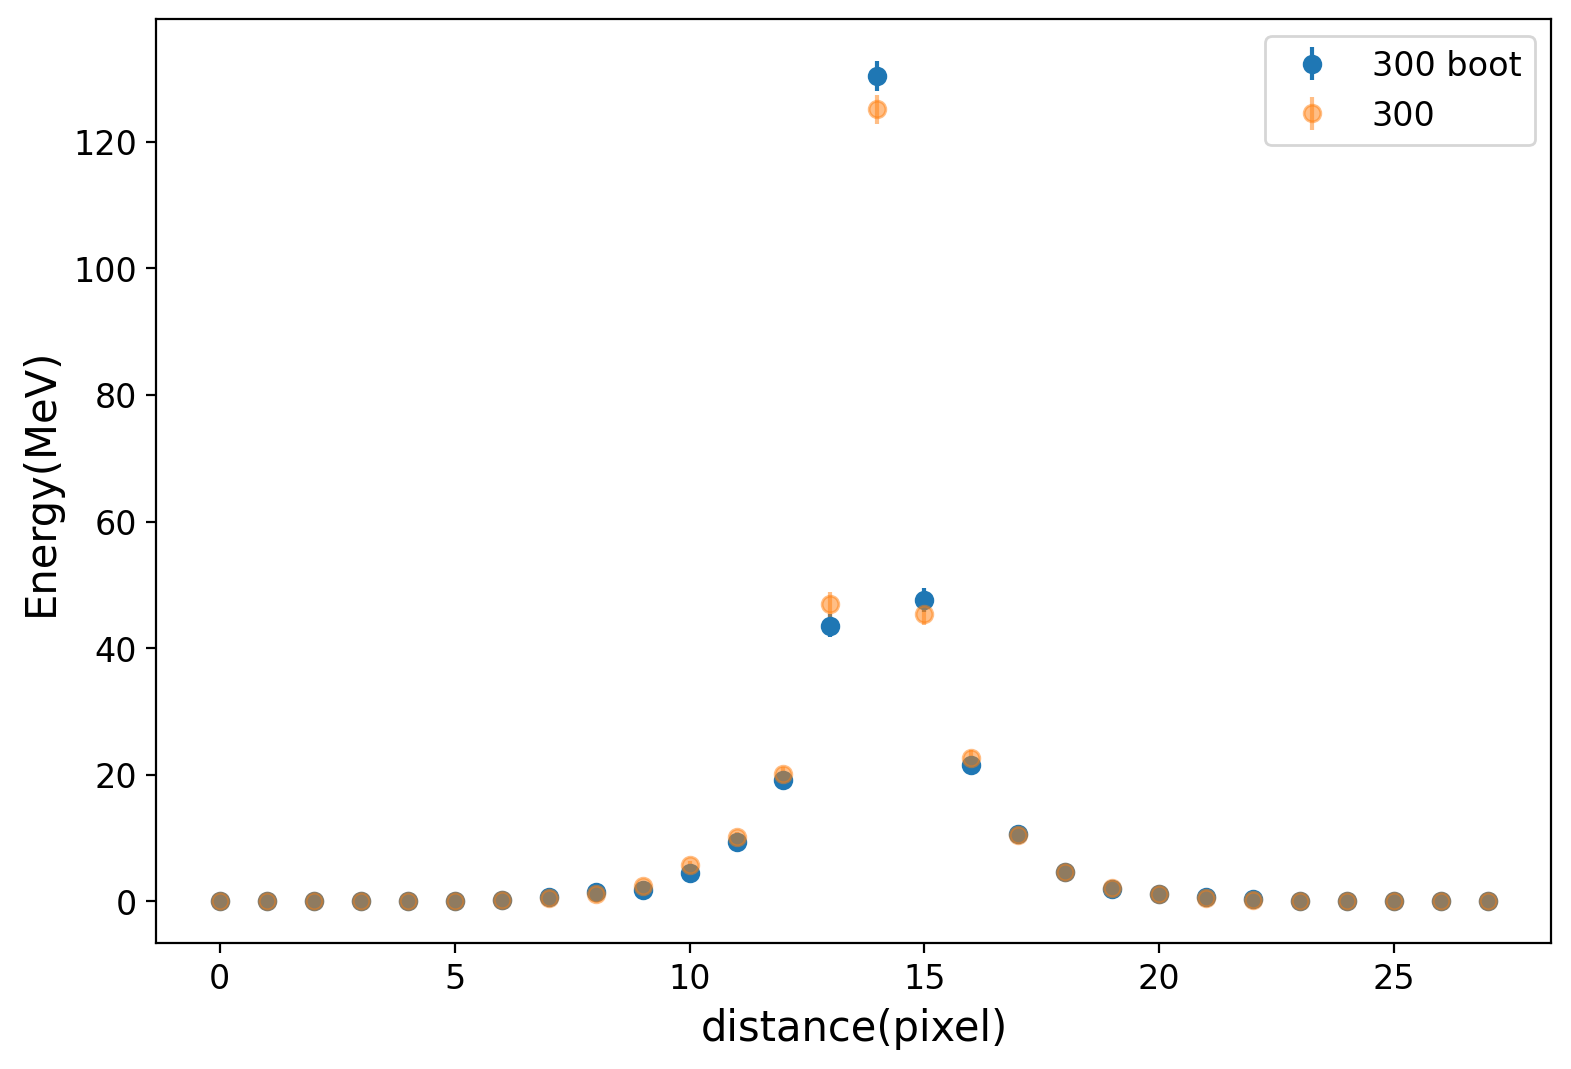

In [64]:
#def profile(iInput):
#    profile_out=np.sum(iInput,axis=3)
#    return profile_out

def profileVar(iData,iNSample):
    boot_profile = []
    for _ in range(iNSample):
        boot_sample = iData[np.random.choice(out_data.shape[0], iNSample, replace=True)]
        boot_prof   = np.mean(profile(boot_sample),axis=0)
        boot_profile.append(boot_prof)
    boot_profile = np.array(boot_profile) # transform it into a numpy array for calculation
    return np.mean(boot_profile,axis=0),np.std(boot_profile,axis=0)

Nsamps=1000
dimage150_boot,dimage150_boot_err = profileVar(dimage150,Nsamps)
dimage200_boot,dimage200_boot_err = profileVar(dimage200,Nsamps)
dimage250_boot,dimage250_boot_err = profileVar(dimage250,Nsamps)
dimage300_boot,dimage300_boot_err = profileVar(dimage300,Nsamps)

#plt.errorbar(np.arange(28),dimage150_boot.flatten(),yerr=dimage150_boot_err,fmt='o',label='150')
#plt.errorbar(np.arange(28),dimage200_boot.flatten(),yerr=dimage200_boot_err,fmt='o',label='200 boot')
#plt.errorbar(np.arange(28),dimage250_boot.flatten(),yerr=dimage250_boot_err,fmt='o',label='250')
plt.errorbar(np.arange(28),dimage300_boot.flatten(),yerr=dimage300_boot_err,fmt='o',label='300 boot')

#plt.errorbar(np.arange(28),test_150.flatten(),yerr=test_150_stderr,fmt='o',label='150',alpha=0.5)
#plt.errorbar(np.arange(28),test_200.flatten(),yerr=test_200_stderr,fmt='o',label='200',alpha=0.5)
#plt.errorbar(np.arange(28),test_250.flatten(),yerr=test_250_stderr,fmt='o',label='250',alpha=0.5)
plt.errorbar(np.arange(28),test_300.flatten(),yerr=test_300_stderr,fmt='o',label='300',alpha=0.5)

plt.legend()
plt.xlabel('distance(pixel)')
plt.ylabel('Energy(MeV)')
plt.show()


Now, lets consider a more complicated variable that we can't necessarily compute.  

3.2771233358763903 2.1280869593938
check 200: 3.3654587785353036 +/- 1.6562868377640825


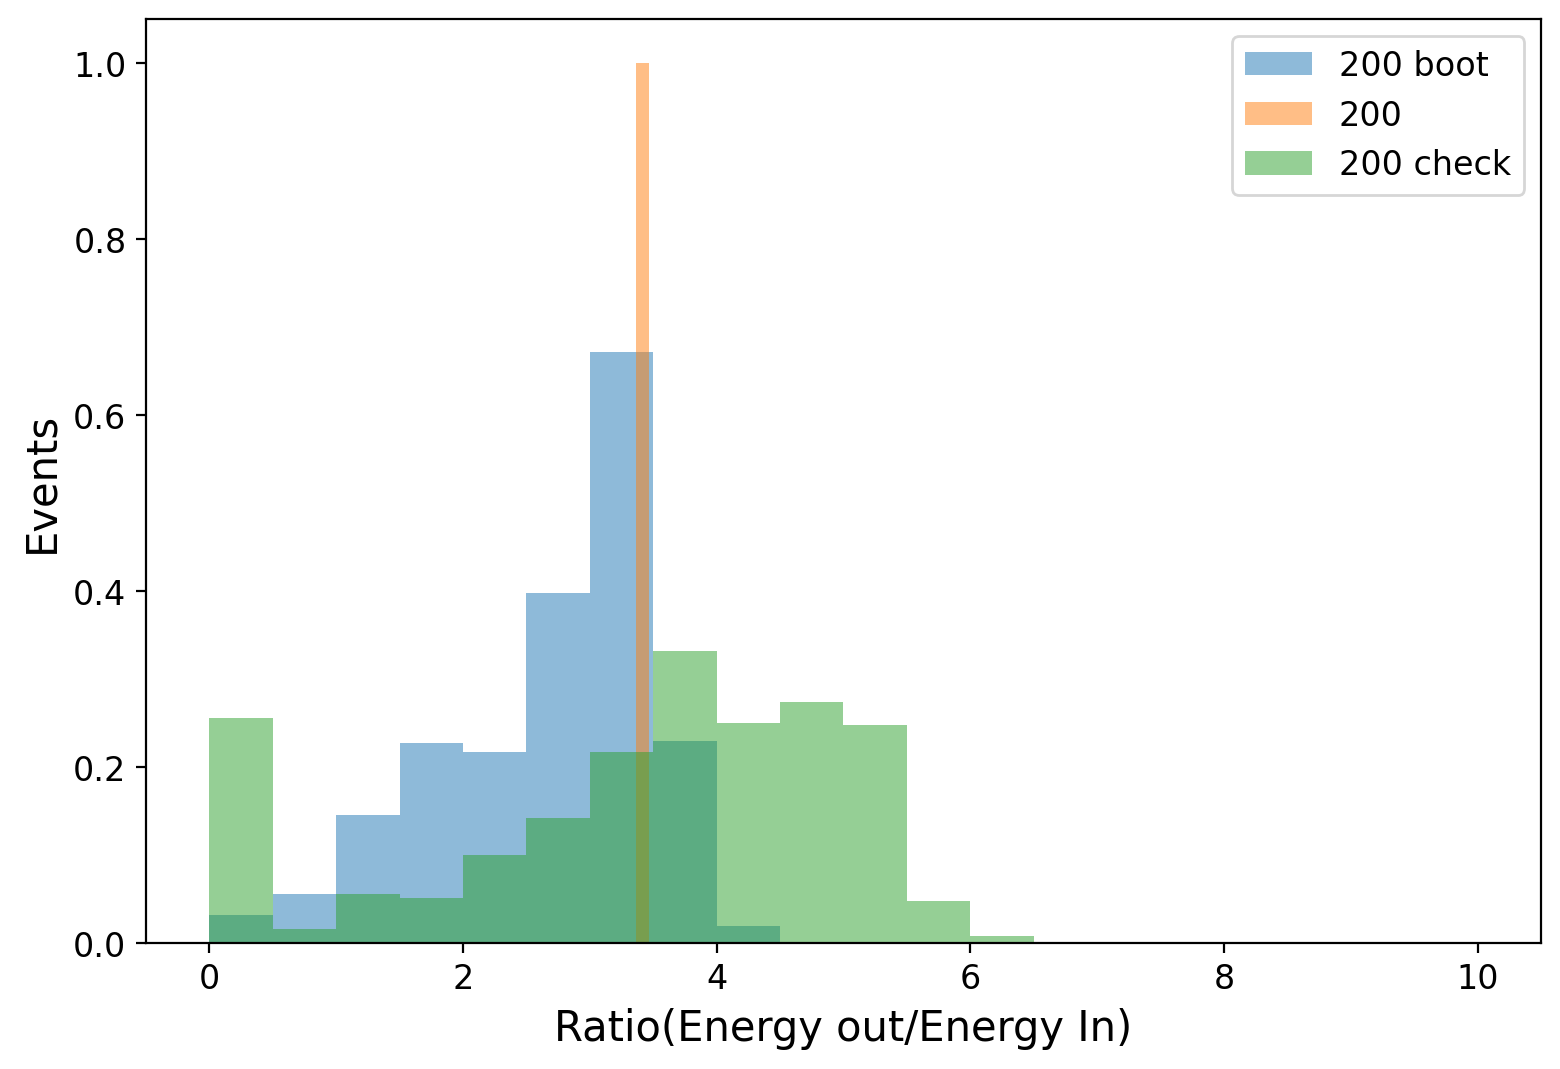

Val: 3.2771233358763903 +/- 0.06729601850586667 boot 2.6802860106820625 +/- 0.9467231348733942
Val: 3.3654587785353036 +/- 0.05237638865892287 boot 2.671294607098637 +/- 0.8424921008959041
Val: 2.7453626625473024 +/- 0.09306596740812087 boot 2.599078127748061 +/- 0.940720237376715
Val: 3.019428617284072 +/- 0.06779921248745453 boot 2.516427153506648 +/- 0.9205274851450614


In [69]:
def xmaxprofile(iInput):
    profile_out=np.sum(iInput,axis=2)
    maxbin=np.argmax(profile_out,axis=2)
    return np.mean(maxbin,axis=0),np.std(maxbin,axis=0)

def xmaxprofile(iInput):
    profile_out=np.sum(iInput,axis=2)
    profile_out=np.reshape(profile_out,(iInput.shape[0],28))
    #maxbin=np.argmax(profile_out,axis=1)
    maxbin=np.unravel_index(np.argmax(profile_out, axis=1), profile_out.shape)
    Ein=np.sum(profile_out[:,0:2],axis=1)
    Eout=profile_out[maxbin]#+profile_out[:,maxbin+1]+profile_out[:,maxbin-1]
    ratio=Eout/Ein
    #print(Ein[0],Eout[0],Eout.shape)
    return np.mean(ratio),np.std(ratio)

def xmaxprofilecheck(iInput):
    profile_out=np.sum(iInput,axis=2)
    profile_out=np.reshape(profile_out,(iInput.shape[0],28))
    #maxbin=np.argmax(profile_out,axis=1)
    maxbin=np.unravel_index(np.argmax(profile_out, axis=1), profile_out.shape)
    Ein=np.sum(profile_out[:,0:2],axis=1)
    Eout=profile_out[maxbin]#+profile_out[:,maxbin+1]+profile_out[:,maxbin-1]
    ratio=Eout/Ein
    #print(Ein[0],Eout[0],Eout.shape)
    return ratio

def xmaxprofileVar(iData,iNSample):
    boot_profile = []
    for _ in range(iNSample):
        boot_sample          = iData[np.random.choice(out_data.shape[0], 1000, replace=True)]
        boot_prof,boot_std   = xmaxprofile(boot_sample)
        boot_profile.append(boot_prof)
    boot_profile = np.array(boot_profile) # transform it into a numpy array for calculation
    #return np.mean(boot_profile,axis=0),np.std(boot_profile,axis=0)
    return boot_profile

xtest_150,xtest_150_std=xmaxprofile(dimage150)
xtest_200,xtest_200_std=xmaxprofile(dimage200)
xtest_250,xtest_250_std=xmaxprofile(dimage250)
xtest_300,xtest_300_std=xmaxprofile(dimage300)
print(xtest_150,xtest_150_std)

xtest_150_stderr = xtest_150_std/np.sqrt(dimage150.shape[0])
xtest_200_stderr = xtest_200_std/np.sqrt(dimage200.shape[0])
xtest_250_stderr = xtest_250_std/np.sqrt(dimage250.shape[0])
xtest_300_stderr = xtest_300_std/np.sqrt(dimage300.shape[0])

Nsamps=1000
dimage150_boot = xmaxprofileVar(dimage150,Nsamps)
dimage200_boot = xmaxprofileVar(dimage200,Nsamps)
dimage250_boot = xmaxprofileVar(dimage250,Nsamps)
dimage300_boot = xmaxprofileVar(dimage300,Nsamps)

#plt.hist(dimage150_boot.flatten(),density=True,label='150',alpha=0.5)
plt.hist(dimage200_boot.flatten(),bins=20,range=[0,10],density=True,label='200 boot',alpha=0.5)
#plt.hist(dimage250_boot.flatten(),density=True,label='250',alpha=0.5)
#plt.hist(dimage300_boot.flatten(),density=True,label='300',alpha=0.5)

#plt.hist(xtest_150.flatten(),label='150',alpha=0.5)
plt.hist(xtest_200.flatten(),label='200',alpha=0.5)
#plt.hist(xtest_250.flatten(),label='250',alpha=0.5)
#plt.hist(xtest_300.flatten(),label='300',alpha=0.5)


xtest_200_check=xmaxprofilecheck(dimage200)
#xtest_300_check=xmaxprofilecheck(dimage300)
plt.hist(xtest_200_check.flatten(),bins=20,range=[0,10],density=True,label='200 check',alpha=0.5)
print("check 200:",np.mean(xtest_200_check),"+/-",np.std(xtest_200_check))
#print("check 300:",np.mean(xtest_300_check),"+/-",np.std(xtest_300_check))


plt.legend()
plt.xlabel('Ratio(Energy out/Energy In)')
plt.ylabel('Events')
plt.show()

def printStats(ival,ierr,iboot):
    print("Val:",ival,"+/-",ierr,"boot",np.mean(iboot),"+/-",np.std(iboot))

printStats(xtest_150,xtest_150_stderr,dimage150_boot,)
printStats(xtest_200,xtest_200_stderr,dimage200_boot)
printStats(xtest_250,xtest_250_stderr,dimage250_boot)
printStats(xtest_300,xtest_300_stderr,dimage300_boot)

Now how is this variabililty, if we generate 1000 images and try to compute it.

## Auxiliary info

In [ ]:
#https://www.kaggle.com/code/augeropendata/the-heitler-model/notebook

<a name='exercises_22_6'></a>     

| [Top](#section_22_0) | [Restart Section](#section_22_6) |


<a name='section_20_7'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.7 Conditional Diffusion Models for Physics Event Generation</h2>  

| [Top](#section_20_0) | [Previous Section](#section_20_6) | [Exercises](#exercises_20_7) |

Diffusion models have become the dominant generative modelling paradigm in AI — they power image generators like DALL-E and Stable Diffusion. The key idea is elegant: instead of learning to map a latent space to data (as the VAE does), we teach a neural network to *reverse* a gradual noising process.

**The forward (noising) process** destroys information in $T$ small steps. At each step $t$ we add a tiny Gaussian kick:

$$q(x_t | x_{t-1}) = \mathcal{N}\!\left(x_t;\, \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t \mathbf{I}\right)$$

where $\beta_t$ is a small variance schedule. Using the property of Gaussians this can be collapsed into a single step:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0,\mathbf{I})$$

where $\bar{\alpha}_t = \prod_{s=1}^{t}(1-\beta_s)$ is the cumulative signal retention. At $t=T$ the image is essentially pure Gaussian noise.

**The reverse (denoising) process** is what we learn. Given noisy $x_t$, a neural network $\epsilon_\theta$ predicts the noise that was added:

$$p_\theta(x_{t-1}|x_t) = \mathcal{N}\!\left(x_{t-1};\; \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)\right),\; \beta_t \mathbf{I}\right)$$

The training loss is simply mean-squared error on the predicted noise:

$$\mathcal{L} = \mathbb{E}_{t,\,x_0,\,\epsilon}\!\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

**Conditional generation** is straightforward: we pass the condition (here, the beam energy $E$) alongside the noisy image and timestep, so the network learns $\epsilon_\theta(x_t, t, E)$. At sampling time we supply the desired energy and the model generates a Bragg shower for exactly that beam.

Compared to the CVAE, the diffusion model has no encoder — it starts from pure Gaussian noise — and can in principle produce sharper, more diverse samples at the cost of needing $T$ sequential network passes to generate one sample.

alpha_bar at t=0:   0.9999  (image almost intact)
alpha_bar at t=T/2: 0.5964
alpha_bar at t=T-1: 0.1322  (image is pure noise)


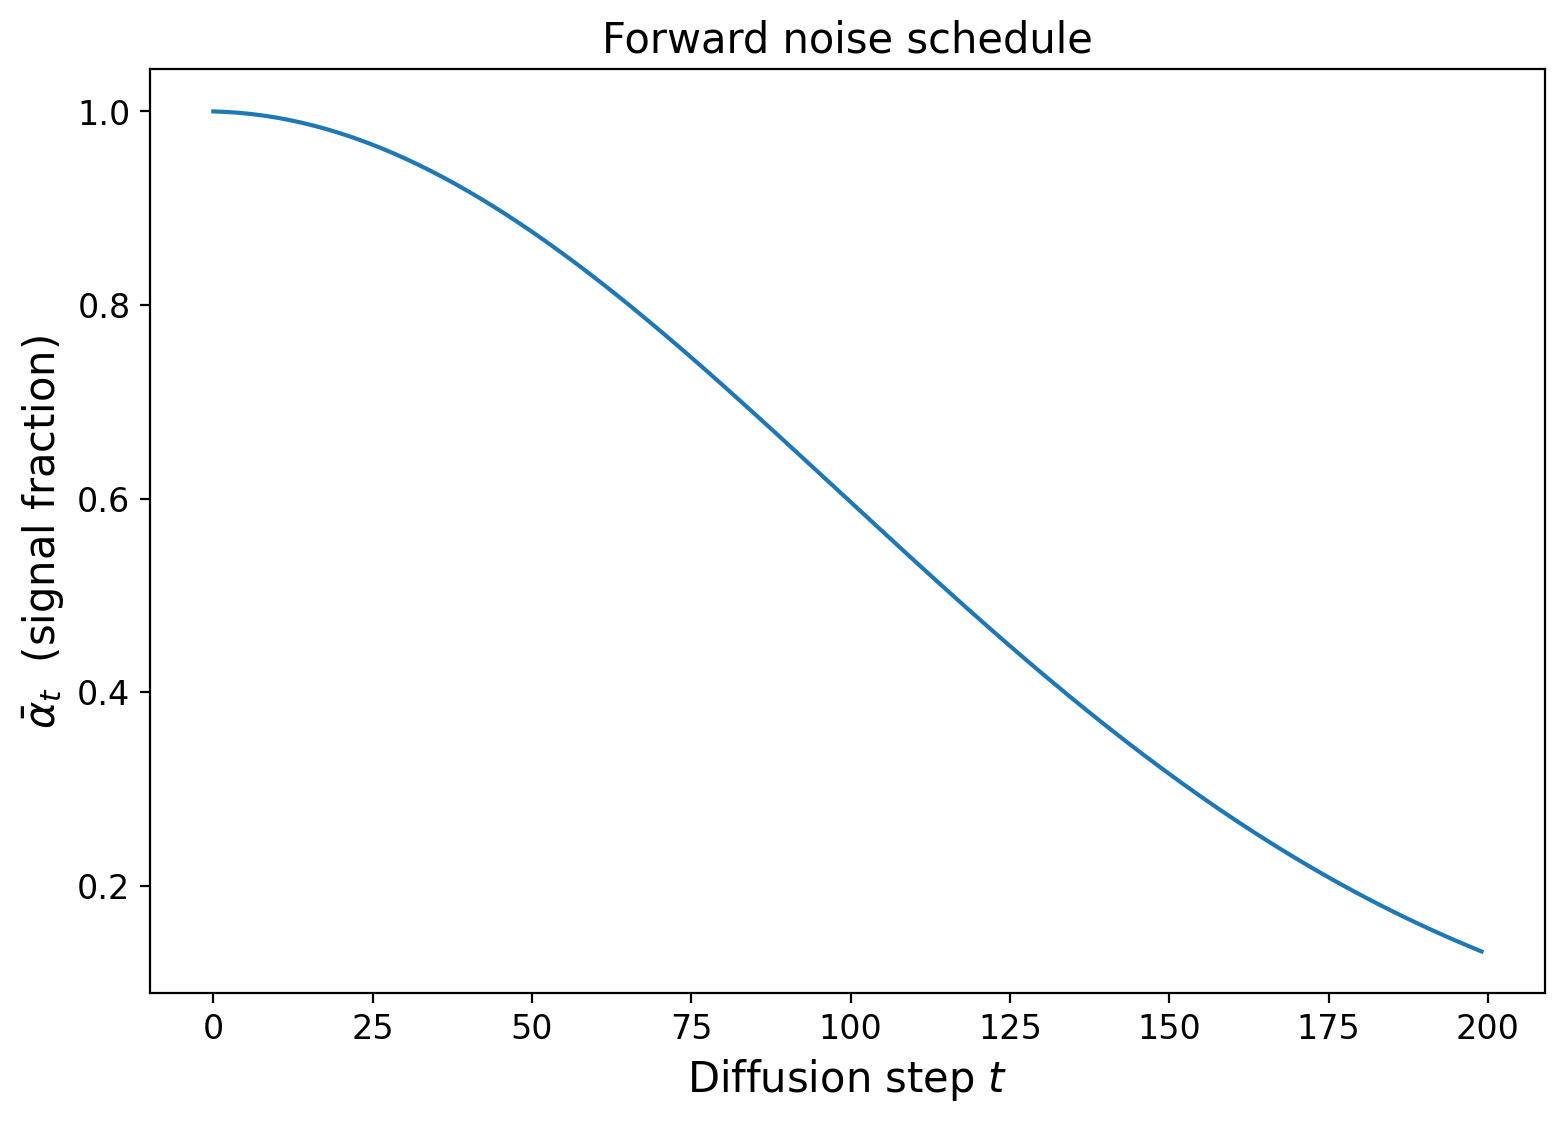

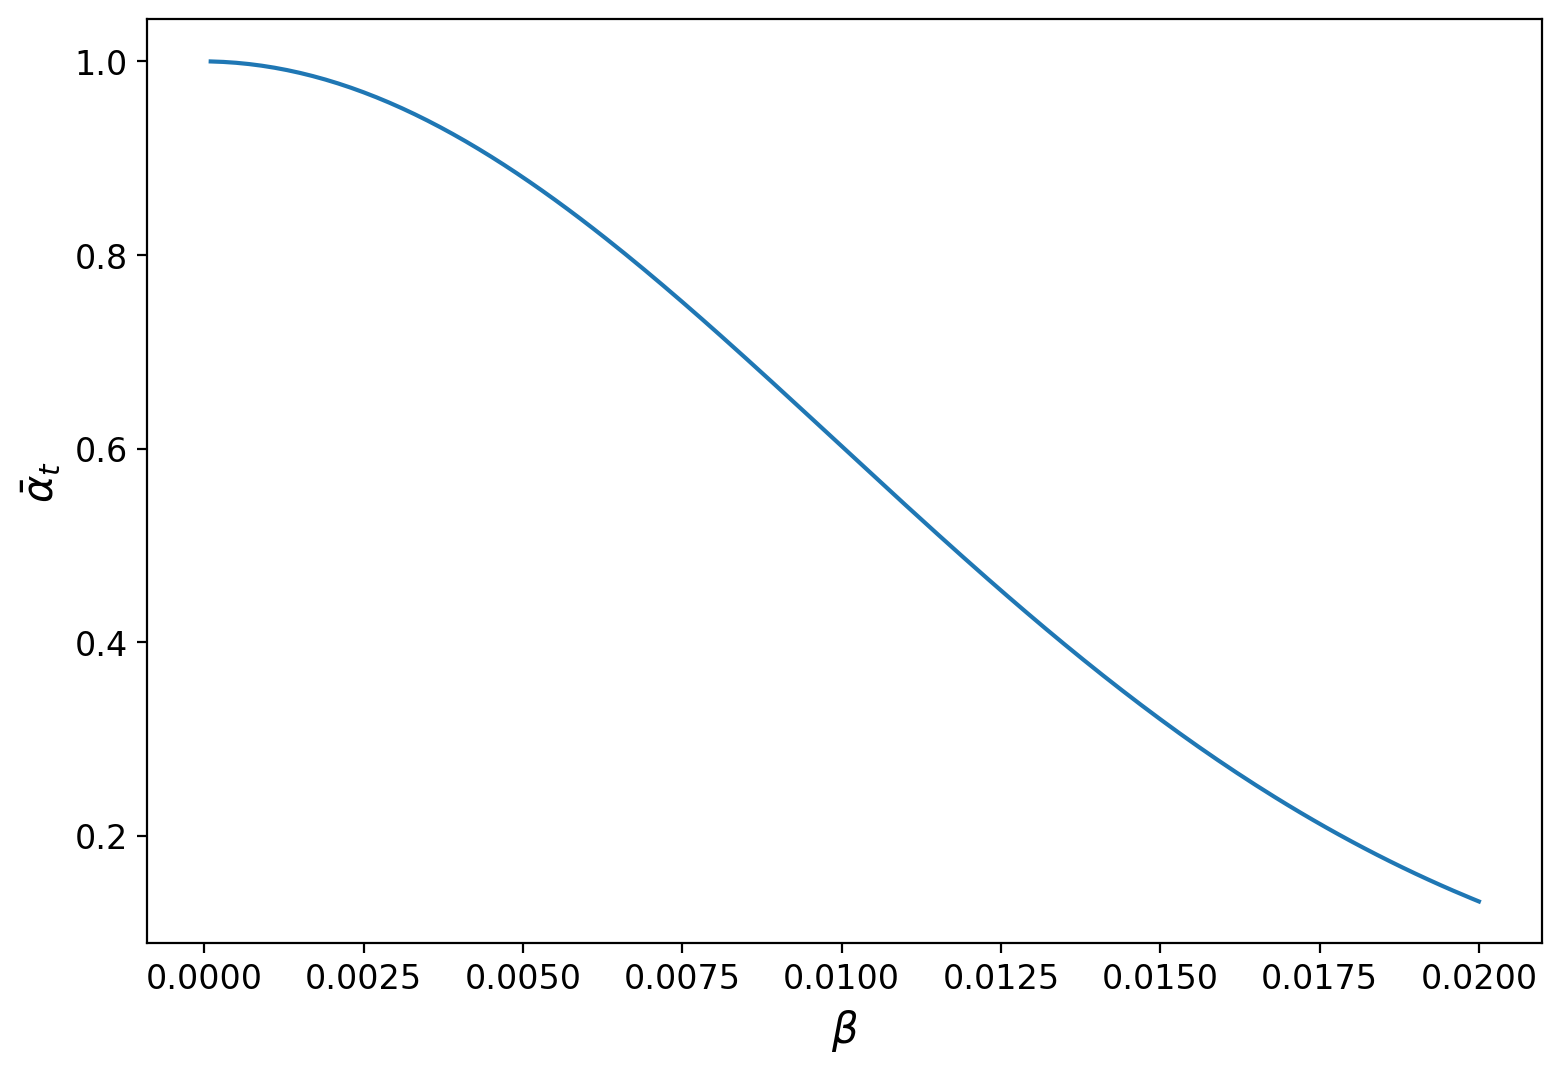

In [62]:
# ── Noise schedule ──────────────────────────────────────────────────────────
T_diff   = 200                                  # number of diffusion steps
beta_min = 1e-4
beta_max = 0.02

betas     = torch.linspace(beta_min, beta_max, T_diff)
alphas    = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)        # cumulative product

print(f"alpha_bar at t=0:   {alpha_bar[0]:.4f}  (image almost intact)")
print(f"alpha_bar at t=T/2: {alpha_bar[T_diff//2]:.4f}")
print(f"alpha_bar at t=T-1: {alpha_bar[-1]:.4f}  (image is pure noise)")

import matplotlib.pyplot as plt
plt.plot(alpha_bar.numpy())
plt.xlabel('Diffusion step $t$')
plt.ylabel('$\\bar{\\alpha}_t$  (signal fraction)')
plt.title('Forward noise schedule')
plt.show()

plt.plot(betas.numpy(),alpha_bar.numpy())
plt.xlabel("$\\beta$")
plt.ylabel("$\\bar{\\alpha}_t$")
plt.show()

To visualise what the forward process does to one of our Bragg shower images:

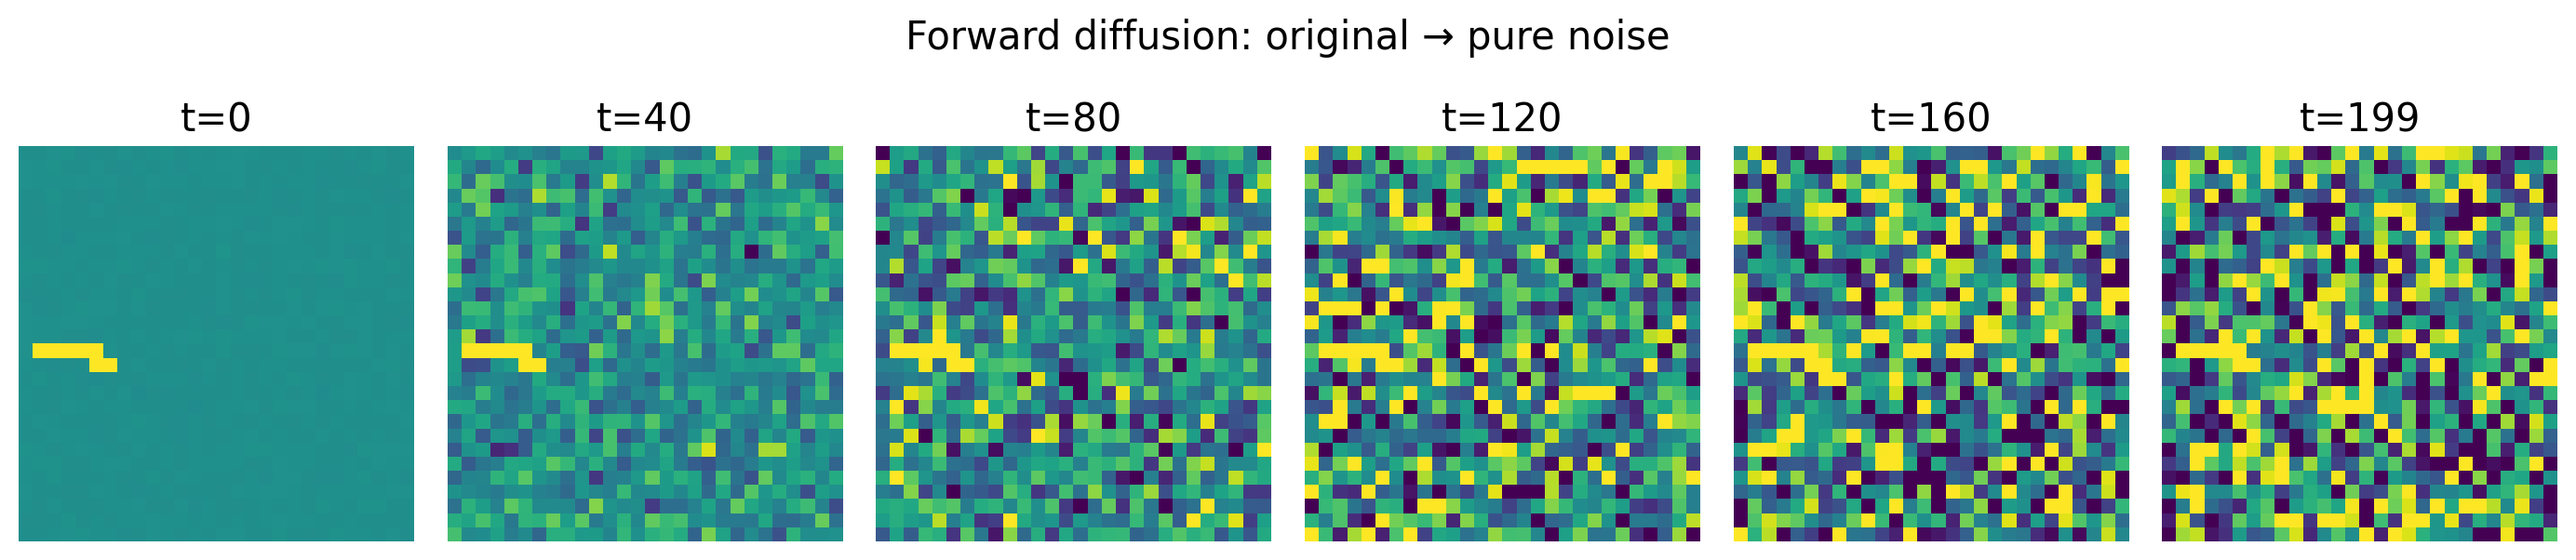

In [29]:
def q_sample(x0, t, noise=None):
    """Single-step forward process: x0 → x_t."""
    if noise is None:
        noise = torch.randn_like(x0)
    a = alpha_bar[t][:, None, None, None]
    return torch.sqrt(a) * x0 + torch.sqrt(1 - a) * noise

# Show one 150 MeV image at several noise levels
x0_example = torch.tensor(dimage150[0:1]).float()
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, t_val in zip(axes, [0, 40, 80, 120, 160, 199]):
    t_tensor = torch.tensor([t_val])
    xt = q_sample(x0_example, t_tensor)
    ax.imshow(xt[0, 0].numpy(), vmin=-1, vmax=1)
    ax.set_title(f't={t_val}')
    ax.axis('off')
fig.suptitle('Forward diffusion: original → pure noise', y=1.02)
plt.tight_layout()
plt.show()

### The noise-prediction network: a conditional U-Net

We need $\epsilon_\theta(x_t, t, E)$ — a network that takes a noisy 28×28 image, a timestep, and the beam energy, and outputs the predicted noise image. A U-Net is natural here: skip connections let the network copy fine spatial structure from the encoder to the decoder, important for accurately placing the Bragg peak.

We condition each residual block via **Feature-wise Linear Modulation (FiLM)**: from the joint embedding of $t$ and $E$ we predict a per-channel scale $\gamma$ and shift $\beta$, then transform the feature map:

$$h \leftarrow \gamma \cdot \mathrm{Norm}(h) + \beta$$

The timestep is encoded with a **sinusoidal embedding** (the same trick used for positional encoding in transformers), so the network can distinguish nearby timesteps without memorising a lookup table.

In [54]:
# ── Building blocks ─────────────────────────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-math.log(10000) * torch.arange(half, dtype=torch.float) / (half - 1))
        emb  = t.float()[:, None] * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ConditionalResBlock(nn.Module):
    """Residual conv block with FiLM conditioning."""
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1    = nn.GroupNorm(min(8, in_ch),  in_ch)
        self.norm2    = nn.GroupNorm(min(8, out_ch), out_ch)
        self.film     = nn.Linear(cond_dim, out_ch * 2)   # scale + shift
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        scale, shift = self.film(cond).chunk(2, dim=-1)
        h = self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)


class BraggDiffusionUNet(nn.Module):
    """Conditional U-Net that predicts the noise added at step t given beam energy E."""
    def __init__(self, time_emb_dim=64):
        super().__init__()
        energy_dim = 16
        cond_dim   = time_emb_dim + energy_dim

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        self.energy_mlp = nn.Sequential(
            nn.Linear(1, energy_dim),
            nn.SiLU()
        )

        # Encoder  28→14→7
        self.enc1  = ConditionalResBlock(1,  8, cond_dim)
        self.down1 = nn.Conv2d(8, 8, 3, stride=2, padding=1)
        self.enc2  = ConditionalResBlock(8, 16, cond_dim)
        self.down2 = nn.Conv2d(16, 16, 3, stride=2, padding=1)

        # Bottleneck  7×7
        self.mid   = ConditionalResBlock(16, 16, cond_dim)

        # Decoder  7→14→28
        self.up2   = nn.ConvTranspose2d(16, 16, 4, stride=2, padding=1)
        self.dec2  = ConditionalResBlock(16 + 16, 32, cond_dim)
        self.up1   = nn.ConvTranspose2d(32, 8, 4, stride=2, padding=1)
        self.dec1  = ConditionalResBlock(8 + 8, 16, cond_dim)
        self.out   = nn.Conv2d(16, 1, 1)

    def forward(self, x, t, energy):
        cond = torch.cat([self.time_mlp(t), self.energy_mlp(energy)], dim=-1)

        h1 = self.enc1(x,           cond)   # 28×28, 32ch
        h2 = self.enc2(self.down1(h1), cond)   # 14×14, 64ch

        h  = self.mid(self.down2(h2), cond)    #  7× 7, 64ch

        h  = self.dec2(torch.cat([self.up2(h),  h2], dim=1), cond)  # 14×14, 32ch
        h  = self.dec1(torch.cat([self.up1(h),  h1], dim=1), cond)  # 28×28, 16ch
        return self.out(h)


torch.manual_seed(42)
diff_model_v2 = BraggDiffusionUNet(time_emb_dim=8)
n_params   = sum(p.numel() for p in diff_model_v2.parameters())
print(f"Diffusion U-Net parameters: {n_params:,}")

Diffusion U-Net parameters: 48,051


### Training

The training loop is simple: for each batch, sample a random timestep $t$ uniformly, corrupt the image to $x_t$, run the U-Net, and minimise MSE against the true noise $\epsilon$.  We train on all four energies simultaneously — the energy condition handles the rest.

In [31]:
# ── Data: normalise images to roughly [-1, 1] before training ────────────────
all_images = np.vstack([dimage150, dimage200, dimage250, dimage300])
img_max    = np.percentile(all_images, 99)  # robust maximum
print(f"99th-percentile pixel value: {img_max:.3f} MeV  (used for normalisation)")

def normalise(x):   return x / img_max       # [0, ~1]
def denormalise(x): return x * img_max

image150_n = DataSet(torch.tensor(normalise(dimage150)).float(), np.ones(dimage150.shape[0]) * 1.50)
image200_n = DataSet(torch.tensor(normalise(dimage200)).float(), np.ones(dimage200.shape[0]) * 2.00)
image250_n = DataSet(torch.tensor(normalise(dimage250)).float(), np.ones(dimage250.shape[0]) * 2.50)
image300_n = DataSet(torch.tensor(normalise(dimage300)).float(), np.ones(dimage300.shape[0]) * 3.00)

from torch.utils.data import ConcatDataset
diff_dataset = ConcatDataset([image150_n, image200_n, image250_n, image300_n])
diff_loader  = torch.utils.data.DataLoader(diff_dataset, batch_size=256, shuffle=True)
print(f"Total training images: {len(diff_dataset)}")

99th-percentile pixel value: 9.958 MeV  (used for normalisation)
Total training images: 4000


In [55]:
def train_diffusion_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, c in loader:
        c = c.reshape(-1, 1).float()
        t = torch.randint(0, T_diff, (x.shape[0],))
        noise  = torch.randn_like(x)
        x_noisy = q_sample(x, t, noise)
        noise_pred = model(x_noisy, t.float(), c)
        loss = F.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

torch.manual_seed(42)
#diff_model  = BraggDiffusionUNet(time_emb_dim=64)
diff_optim  = torch.optim.Adam(diff_model_v2.parameters(), lr=1e-3)
diff_losses = []

num_epochs_diff = 400
for epoch in range(num_epochs_diff):
    loss = train_diffusion_epoch(diff_model_v2, diff_loader, diff_optim)
    diff_losses.append(loss)
    if epoch % 2 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs_diff}  loss: {loss:.5f}')

plt.plot(diff_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE loss (noise prediction)')
plt.title('Diffusion model training')
plt.show()

Epoch   1/400  loss: 0.66552
Epoch   3/400  loss: 0.15725
Epoch   5/400  loss: 0.09775
Epoch   7/400  loss: 0.06715
Epoch   9/400  loss: 0.05703
Epoch  11/400  loss: 0.04697
Epoch  13/400  loss: 0.04201
Epoch  15/400  loss: 0.03701
Epoch  17/400  loss: 0.03464
Epoch  19/400  loss: 0.03196
Epoch  21/400  loss: 0.02922
Epoch  23/400  loss: 0.02871
Epoch  25/400  loss: 0.02710
Epoch  27/400  loss: 0.02587
Epoch  29/400  loss: 0.02438
Epoch  31/400  loss: 0.02488
Epoch  33/400  loss: 0.02472
Epoch  35/400  loss: 0.02287
Epoch  37/400  loss: 0.02309
Epoch  39/400  loss: 0.02173
Epoch  41/400  loss: 0.02147
Epoch  43/400  loss: 0.02143
Epoch  45/400  loss: 0.02126
Epoch  47/400  loss: 0.02038
Epoch  49/400  loss: 0.02021
Epoch  51/400  loss: 0.01963
Epoch  53/400  loss: 0.01974
Epoch  55/400  loss: 0.01924
Epoch  57/400  loss: 0.01895


KeyboardInterrupt: 

### Sampling from the diffusion model

To draw a new sample we start from $x_T \sim \mathcal{N}(0, \mathbf{I})$ and apply the learned reverse process $T$ times, each step guided by the beam energy:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\epsilon_\theta(x_t, t, E)\right) + \sqrt{\beta_t}\,z, \qquad z \sim \mathcal{N}(0,\mathbf{I})$$

This is the DDPM sampler (Ho et al., 2020). The $\sqrt{\beta_t}\,z$ term at each step re-introduces a small amount of randomness, which prevents the reverse process from collapsing to the same sample every time.

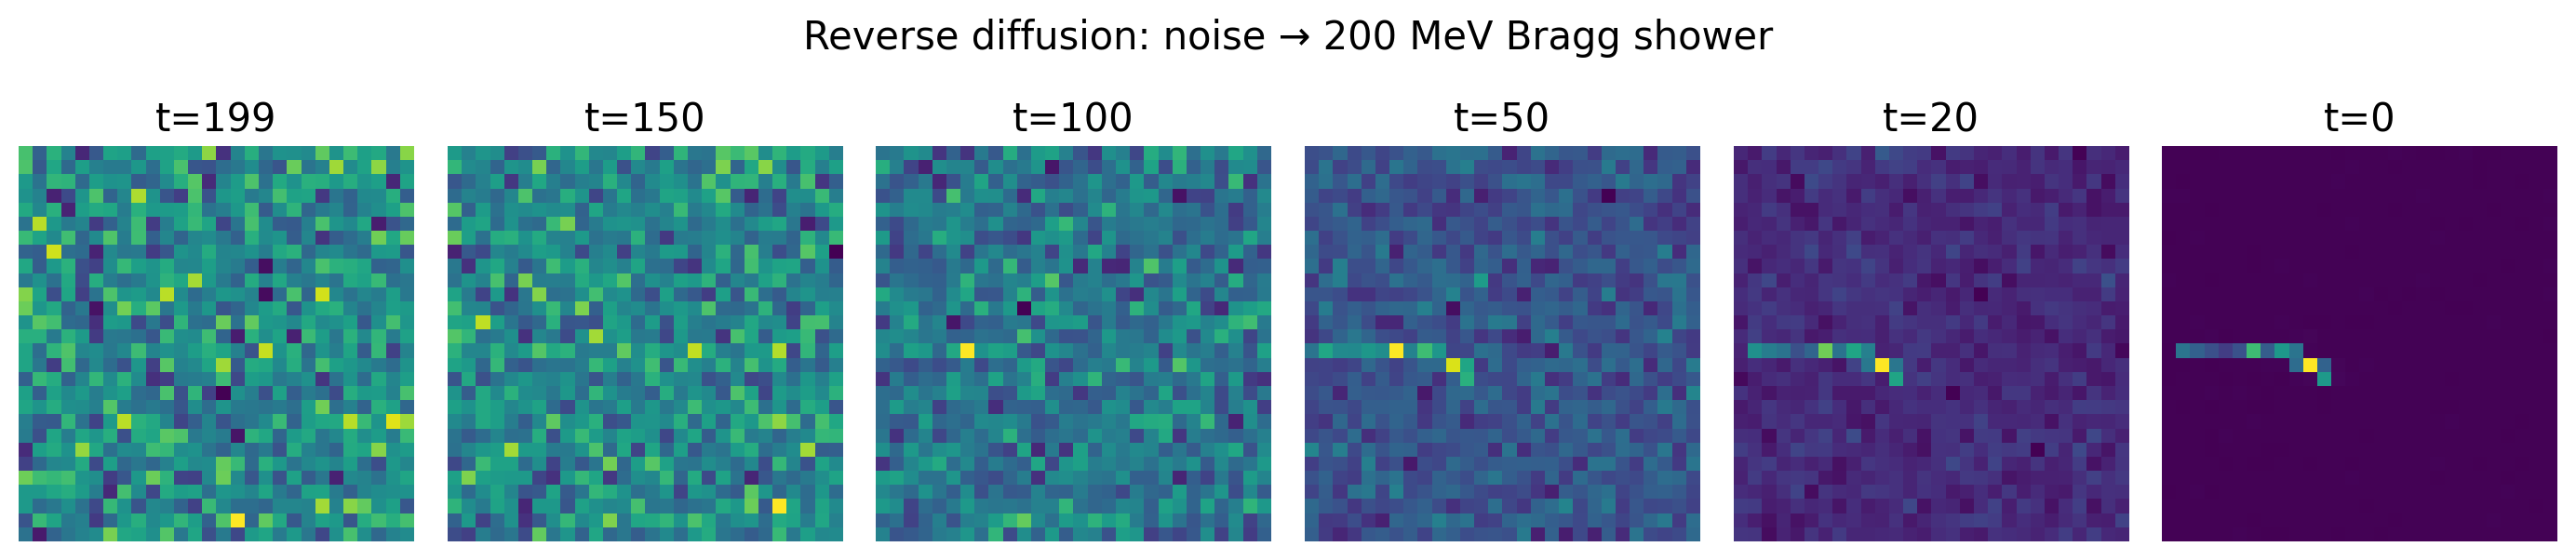

In [56]:
@torch.no_grad()
def p_sample(model, x, t_int, energy):
    """One reverse-diffusion step: x_t → x_{t-1}."""
    t_tensor   = torch.full((x.shape[0],), t_int, dtype=torch.float)
    noise_pred = model(x, t_tensor, energy)

    alpha_t     = alphas[t_int]
    alpha_bar_t = alpha_bar[t_int]
    beta_t      = betas[t_int]

    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * noise_pred
    )
    if t_int > 0:
        return mean + torch.sqrt(beta_t) * torch.randn_like(x)
    return mean


@torch.no_grad()
def generate_diffusion(model, energy_val, n_samples):
    """Full reverse chain: pure noise → Bragg shower images."""
    energy = torch.ones(n_samples, 1) * energy_val
    x      = torch.randn(n_samples, 1, 28, 28)
    for t in reversed(range(T_diff)):
        x = p_sample(model, x, t, energy)
    return denormalise(x.numpy())


# Visualise the denoising chain for one sample at 200 MeV
energy_vis = torch.ones(1, 1) * 2.0
x_chain    = torch.randn(1, 1, 28, 28)
snapshots  = []
for t in reversed(range(T_diff)):
    x_chain = p_sample(diff_model, x_chain, t, energy_vis)
    if t in [199, 150, 100, 50, 20, 0]:
        snapshots.append((t, x_chain[0, 0].numpy().copy()))

fig, axes = plt.subplots(1, len(snapshots), figsize=(14, 3))
for ax, (t_val, img) in zip(axes, snapshots):
    ax.imshow(img)
    ax.set_title(f't={t_val}')
    ax.axis('off')
fig.suptitle('Reverse diffusion: noise → 200 MeV Bragg shower', y=1.02)
plt.tight_layout()
plt.show()

### Comparing the CVAE and the diffusion model

Both models are trained to reproduce the same Bragg shower distributions conditioned on beam energy. Let's generate a batch from each and compare the average shower profiles (x- and y-projections) against the Monte Carlo truth.

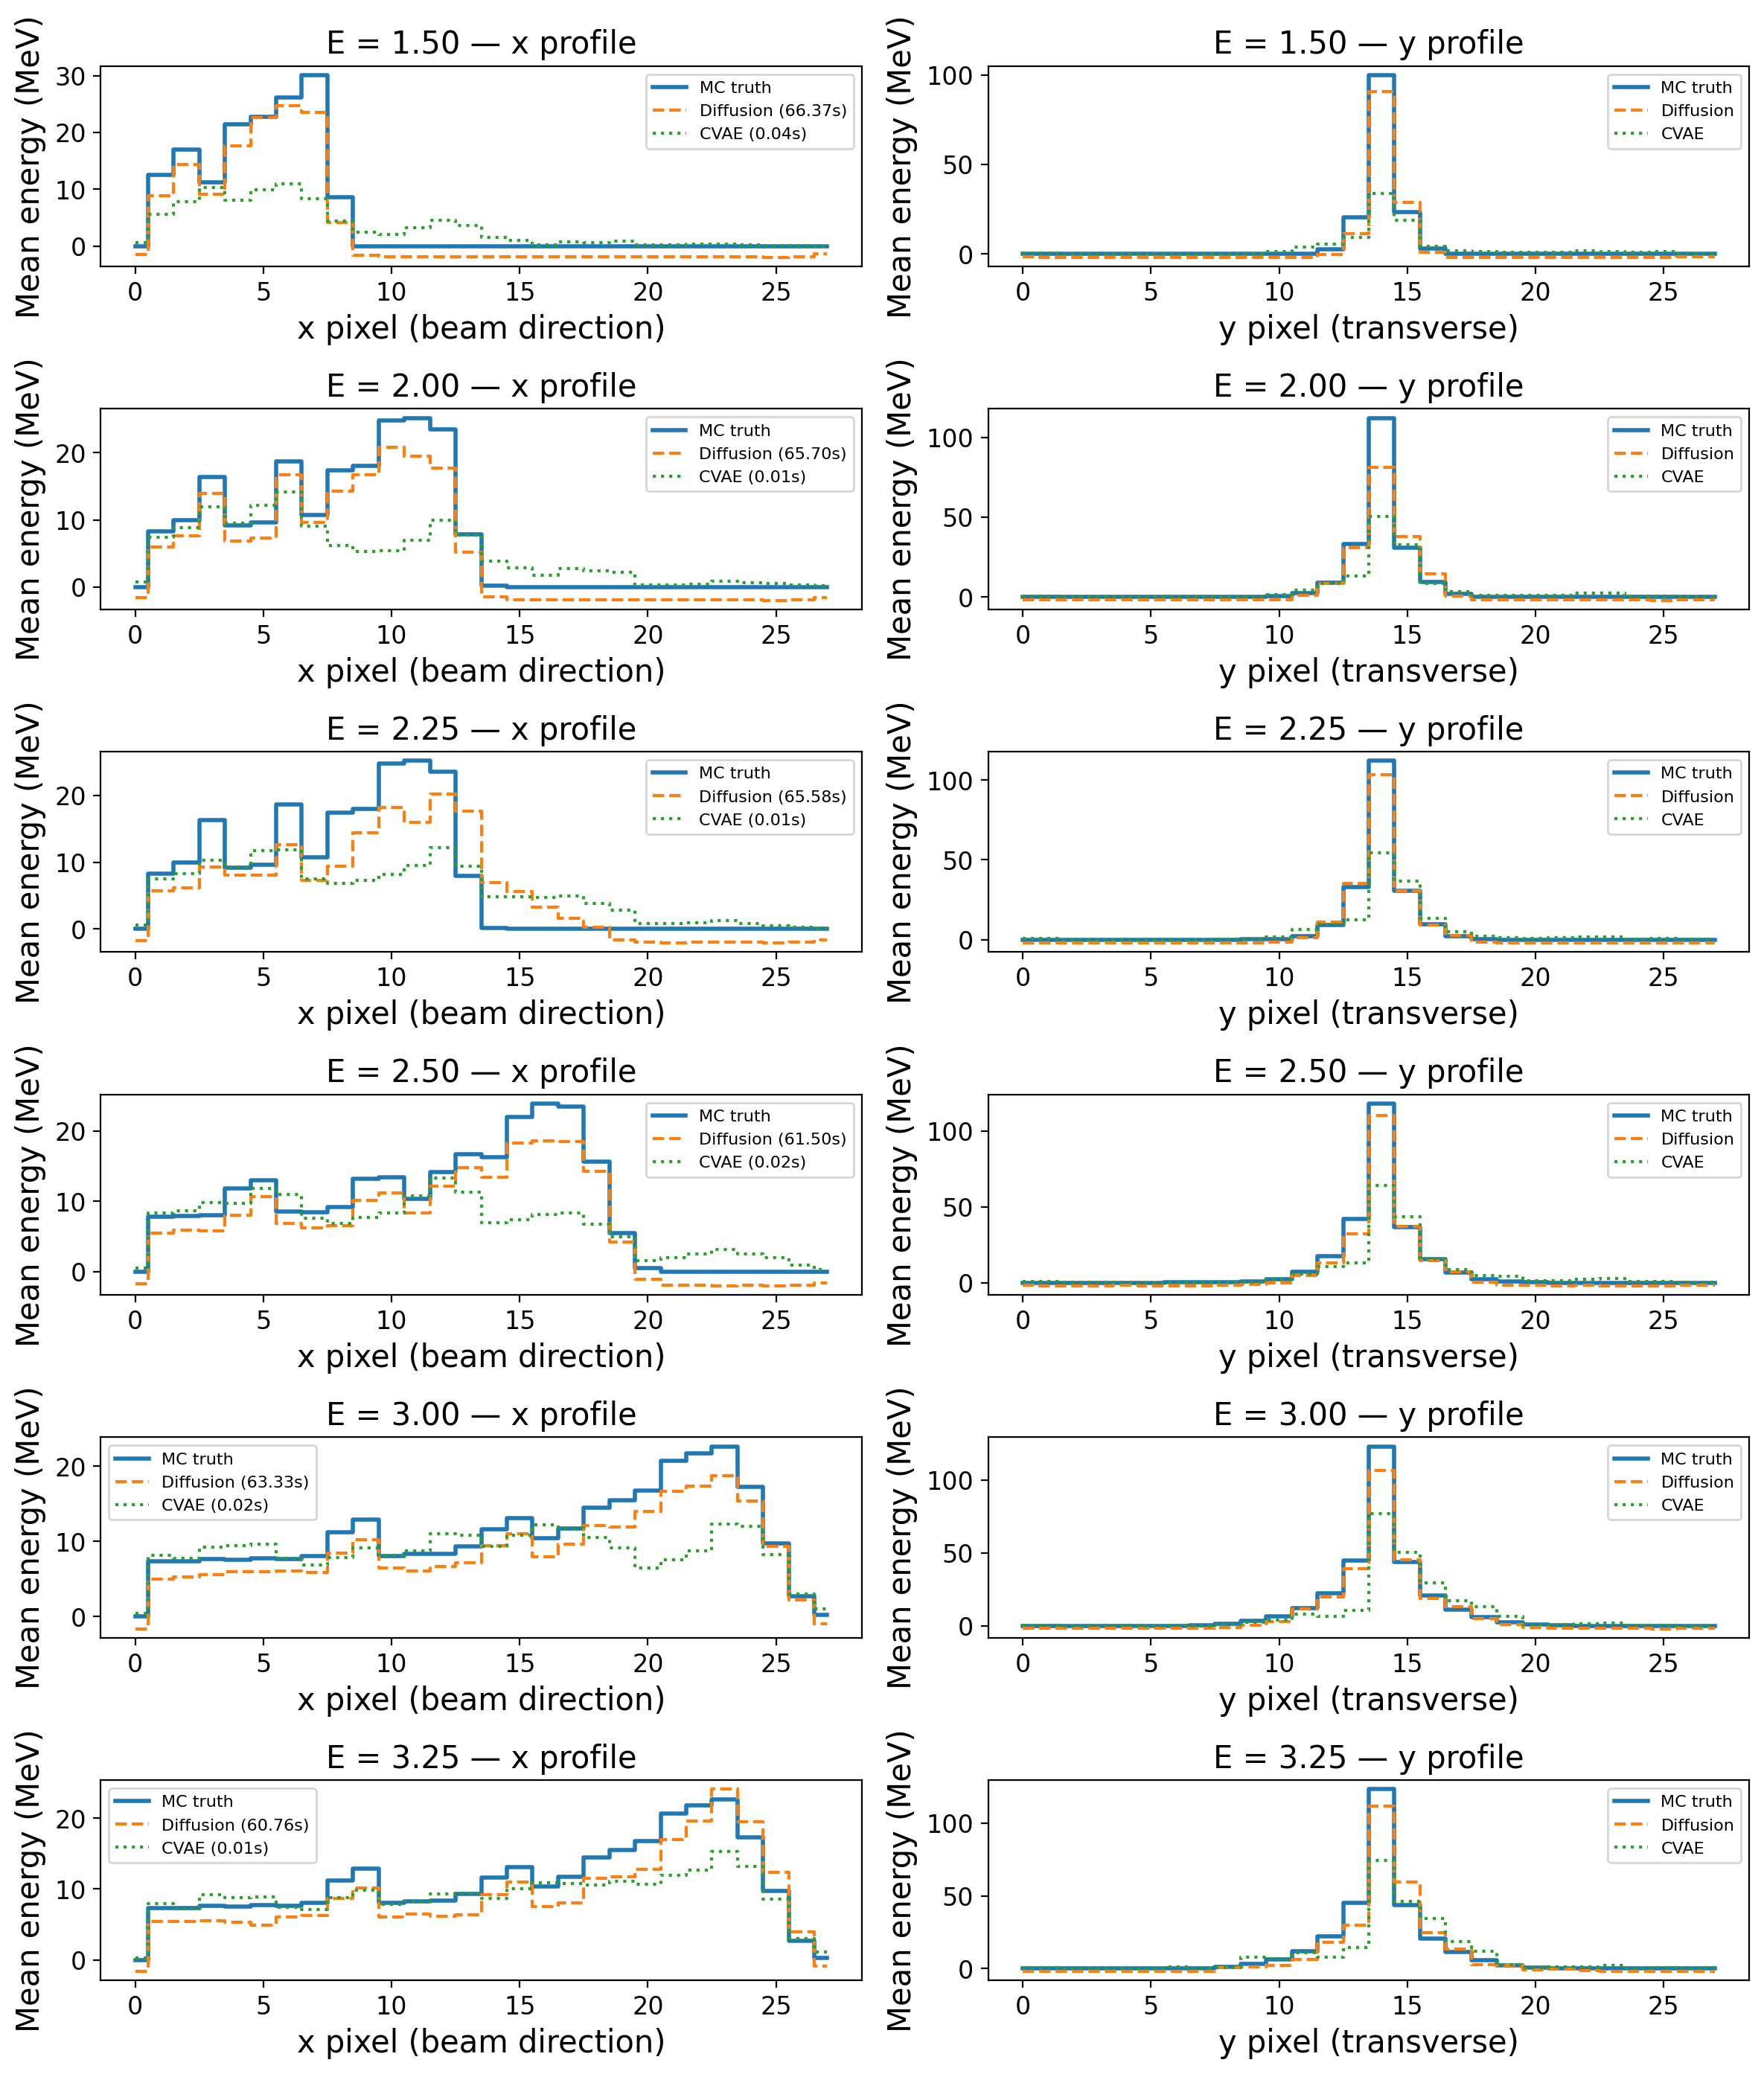

In [67]:
import time

energies   = [(1.50, dimage150), (2.00, dimage200),(2.25, dimage200), (2.50, dimage250), (3.00, dimage300),(3.25, dimage300)]
n_gen      = 200

fig, axes = plt.subplots(len(energies), 2, figsize=(12, 14))

for row, (E, mc_data) in enumerate(energies):
    # ── Diffusion model ──
    t0   = time.time()
    diff_samples = generate_diffusion(diff_model, E, n_gen)
    t_diff = time.time() - t0

    # ── CVAE ──
    t0   = time.time()
    with torch.no_grad():
        z_cvae = torch.randn(n_gen, 6)
        e_cvae = torch.ones(n_gen, 1) * E
        cvae_samples = cvae_proton_image.decoder(z_cvae, e_cvae).numpy() * img_max
    t_cvae = time.time() - t0

    xbin = np.arange(28)

    # x-projection (axis=2 sums over y)
    mc_prof   = np.mean(np.sum(mc_data,       axis=2), axis=0).flatten()
    diff_prof = np.mean(np.sum(diff_samples,  axis=2), axis=0).flatten()
    cvae_prof = np.mean(np.sum(cvae_samples,  axis=2), axis=0).flatten()
    cvae_prof = np.mean(np.sum(cvae_samples,  axis=2), axis=0).flatten() * np.sum(diff_prof)/np.sum(cvae_prof)
    
    ax = axes[row, 0]
    ax.plot(xbin, mc_prof,   drawstyle='steps-mid', label='MC truth', lw=2)
    ax.plot(xbin, diff_prof, drawstyle='steps-mid', label=f'Diffusion ({t_diff:.2f}s)', lw=1.5, ls='--')
    ax.plot(xbin, cvae_prof, drawstyle='steps-mid', label=f'CVAE ({t_cvae:.2f}s)',      lw=1.5, ls=':')
    ax.set_xlabel('x pixel (beam direction)')
    ax.set_ylabel('Mean energy (MeV)')
    ax.set_title(f'E = {E:.2f} — x profile')
    ax.legend(fontsize=8)

    # y-projection (axis=3 sums over x)
    ybin = np.arange(28)
    mc_yprof   = np.mean(np.sum(mc_data,      axis=3), axis=0).flatten()
    diff_yprof = np.mean(np.sum(diff_samples, axis=3), axis=0).flatten()
    cvae_yprof = np.mean(np.sum(cvae_samples, axis=3), axis=0).flatten()
    cvae_yprof = np.mean(np.sum(cvae_samples, axis=3), axis=0).flatten()*np.sum(diff_yprof)/np.sum(cvae_yprof)

    ax = axes[row, 1]
    ax.plot(ybin, mc_yprof,   drawstyle='steps-mid', label='MC truth', lw=2)
    ax.plot(ybin, diff_yprof, drawstyle='steps-mid', label='Diffusion', lw=1.5, ls='--')
    ax.plot(ybin, cvae_yprof, drawstyle='steps-mid', label='CVAE',      lw=1.5, ls=':')
    ax.set_xlabel('y pixel (transverse)')
    ax.set_ylabel('Mean energy (MeV)')
    ax.set_title(f'E = {E:.2f} — y profile')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

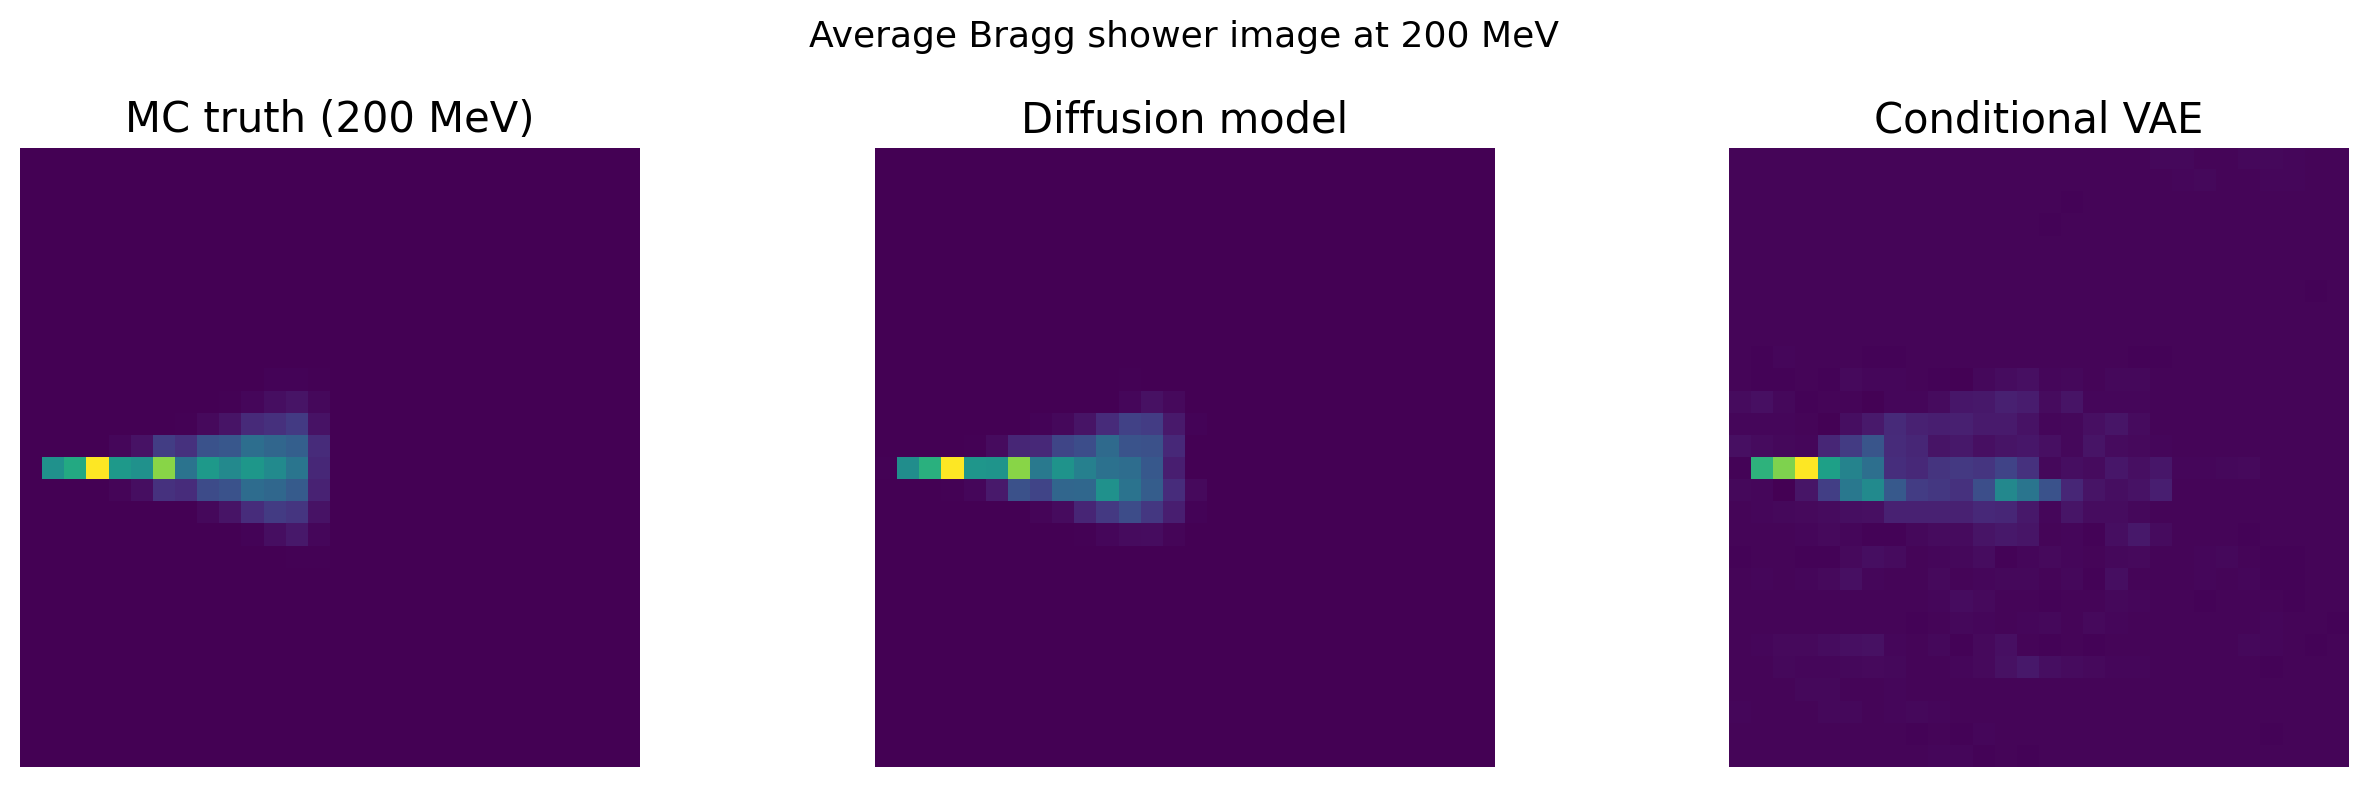

Generating 250 events — Diffusion: 83.35s   CVAE: 0.037s   ratio: 2240x slower


In [66]:
# ── Average generated images side-by-side ───────────────────────────────────
E_show = 2.0
n_show = 200

diff_imgs = generate_diffusion(diff_model, E_show, n_show)
with torch.no_grad():
    z_c = torch.randn(n_show, 6)
    e_c = torch.ones(n_show, 1) * E_show
    cvae_imgs = cvae_proton_image.decoder(z_c, e_c).numpy() * img_max

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(np.mean(dimage200, axis=0)[0]);       axes[0].set_title('MC truth (200 MeV)')
axes[1].imshow(np.mean(diff_imgs, axis=0)[0]);       axes[1].set_title('Diffusion model')
axes[2].imshow(np.mean(cvae_imgs, axis=0)[0]);       axes[2].set_title('Conditional VAE')
for ax in axes:
    ax.axis('off')
plt.suptitle('Average Bragg shower image at 200 MeV', fontsize=13)
plt.tight_layout()
plt.show()

# Print generation speed comparison
n_timing = 250
t0 = time.time(); generate_diffusion(diff_model, 2.0, n_timing); t_diff = time.time()-t0
t0 = time.time()
with torch.no_grad():
    z=torch.randn(n_timing,6); e=torch.ones(n_timing,1)*2.0
    cvae_proton_image.decoder(z,e)
t_cvae = time.time()-t0
print(f"Generating {n_timing} events — Diffusion: {t_diff:.2f}s   CVAE: {t_cvae:.3f}s   ratio: {t_diff/t_cvae:.0f}x slower")

### Discussion: VAE vs Diffusion models

| Property | Conditional VAE | Conditional Diffusion |
|---|---|---|
| Generation | Single forward pass through decoder | $T$ sequential network evaluations |
| Speed | Very fast | ~$T\times$ slower |
| Mode coverage | Can suffer from mode collapse | Generally better diversity |
| Training loss | Reconstruction + KL divergence | Simple MSE on noise |
| Conditioning | Energy appended to latent & decoder | Energy modulates every U-Net block |
| Typical use in HEP | CaloChallenges, event generators | Emerging (CaloScore, etc.) |

The diffusion model is $T \approx 200\times$ slower to generate with. This cost can be reduced with **DDIM** (denoising diffusion implicit models), which allows far fewer steps (10–20) with little quality loss — bringing generation time within reach of the CVAE.

Both are already being used in high-energy physics: VAE-based generators appear in calorimeter simulation challenges, and diffusion-based calorimeter emulators have been demonstrated to match full GEANT4 simulations.

<a name='exercises_20_7'></a>     

| [Top](#section_20_0) | [Restart Section](#section_20_7) |

### <span style="border:3px; border-style:solid; padding: 0.15em; border-color: #90409C; color: #90409C;">Exercise 20.7.1</span>

The DDPM sampler requires $T$ forward passes through the U-Net for each generated sample. The **DDIM** sampler (Song et al., 2020) replaces this with a deterministic, non-Markovian update rule that allows skipping timesteps:

$$x_{t-\Delta} = \sqrt{\bar{\alpha}_{t-\Delta}}\,\hat{x}_0 + \sqrt{1-\bar{\alpha}_{t-\Delta}}\,\epsilon_\theta(x_t, t, E)$$

where $\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta}{\sqrt{\bar{\alpha}_t}}$ is the predicted clean image.

Implement a DDIM sampler that uses only 20 steps (choose a linearly-spaced subset of timesteps from $[0, T]$) and compare the generated shower profiles to the full DDPM sampler. How many steps are needed before quality degrades noticeably?

### <span style="border:3px; border-style:solid; padding: 0.15em; border-color: #90409C; color: #90409C;">Exercise 20.7.2</span>

Currently we embed the beam energy as a continuous scalar. An alternative is **classifier-free guidance**: train the model with the energy condition dropped (set to zero) 10% of the time, then at sampling time interpolate between the conditional and unconditional predictions:

$$\tilde{\epsilon}_\theta = \epsilon_\theta(x_t, t, \emptyset) + w\bigl(\epsilon_\theta(x_t, t, E) - \epsilon_\theta(x_t, t, \emptyset)\bigr)$$

for guidance scale $w > 1$. Retrain with this modification and explore what happens to the generated showers as you increase $w$ from 1 to 5. Does stronger guidance produce sharper Bragg peaks?